In [5]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
 
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
%pip install lightgbm xgboost
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
 
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
 
RANDOM_SEED = 42
N_FOLDS = 10
np.random.seed(RANDOM_SEED)

Note: you may need to restart the kernel to use updated packages.


In [6]:
# Load the datasets
train_raw = pd.read_csv("data/train.csv")
test_raw = pd.read_csv("data/test.csv")
sample_sub = pd.read_csv("data/sample_submission.csv")
 
print(f"\nTrain shape: {train_raw.shape}")
print(f"Test  shape: {test_raw.shape}")
print(f"Sample submission shape: {sample_sub.shape}")


Train shape: (1200, 38)
Test  shape: (532, 37)
Sample submission shape: (532, 2)



Target distribution:
y
up         452
neutral    379
down       369
Name: count, dtype: int64

Target proportions:
y
up         0.3767
neutral    0.3158
down       0.3075
Name: proportion, dtype: float64


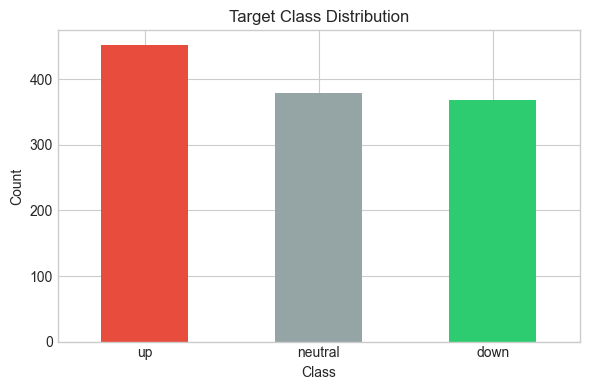

In [7]:
# EDA 
## a. Target distribution
target_counts = train_raw["y"].value_counts()
print(f"\nTarget distribution:\n{target_counts}")
print(f"\nTarget proportions:\n{train_raw['y'].value_counts(normalize=True).round(4)}")
 
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
target_counts.plot(kind="bar", color=["#e74c3c", "#95a5a6", "#2ecc71"], ax=ax)
ax.set_title("Target Class Distribution")
ax.set_ylabel("Count")
ax.set_xlabel("Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plots/eda_target_distribution.png", dpi=150)
plt.show()

In [8]:
## b. Feature summary stats
feature_cols = [c for c in train_raw.columns if c not in ["ID", "y"]]
print(f"\nNumber of features: {len(feature_cols)}")
print(f"Missing values in train: {train_raw[feature_cols].isnull().sum().sum()}")
print(f"Missing values in test:  {test_raw[feature_cols].isnull().sum().sum()}")


Number of features: 36
Missing values in train: 0
Missing values in test:  0


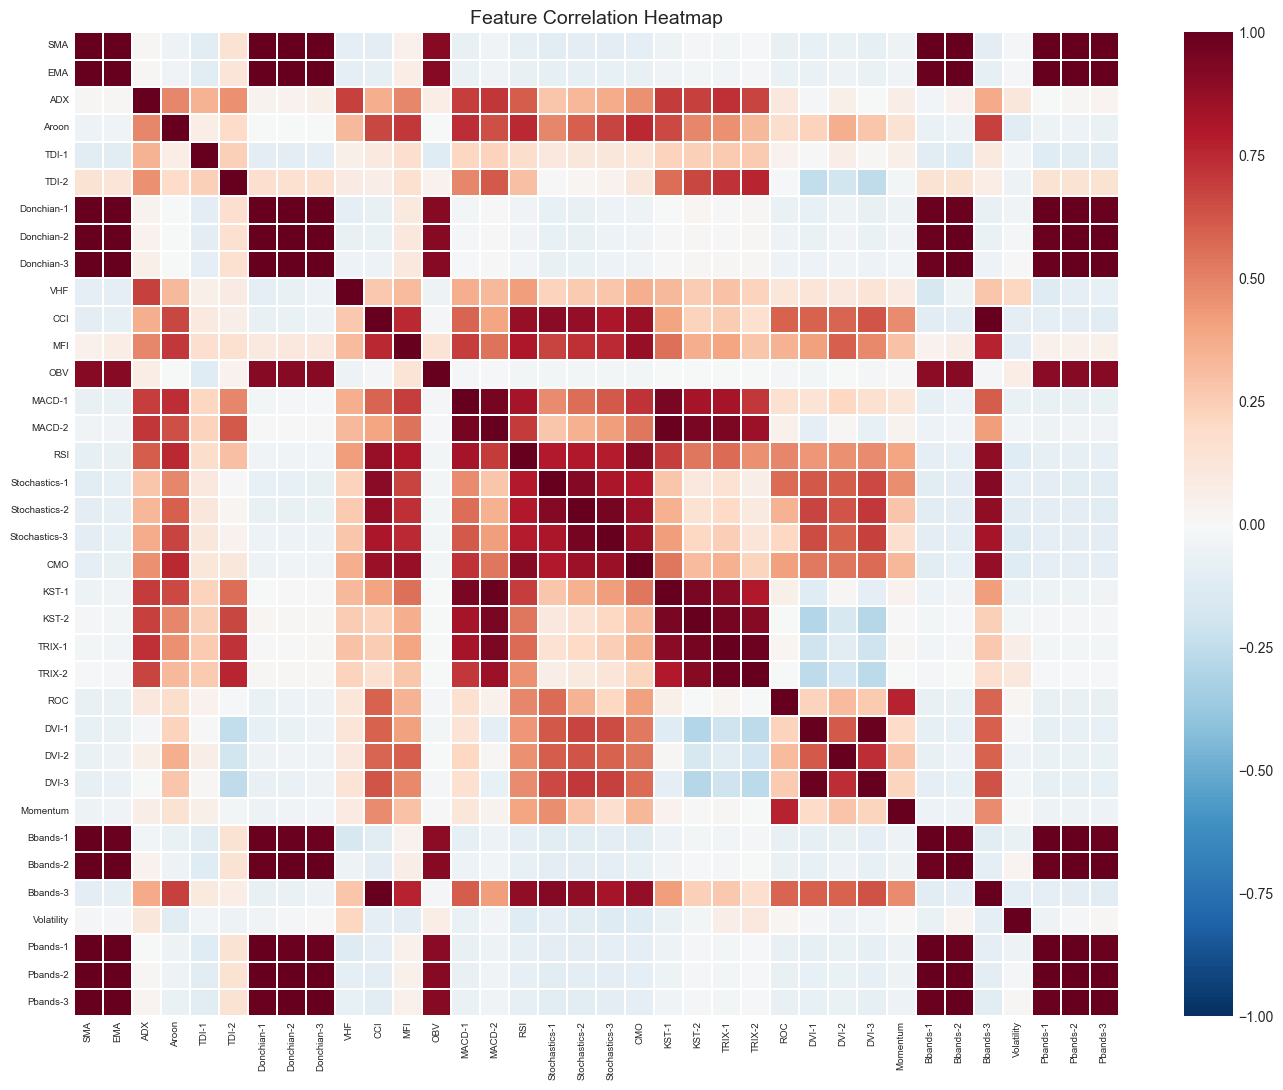

In [9]:
## c. Correlation matrix heatmap
corr_matrix = train_raw[feature_cols].corr()
 
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, ax=ax,
            linewidths=0.3, fmt=".1f")
ax.set_title("Feature Correlation Heatmap", fontsize=14)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig("plots/eda_correlation_heatmap.png", dpi=150)
plt.show()


Highly correlated feature pairs (r > 0.95):
  Pbands-2         &  SMA              =>  r = 1.0000
  Pbands-2         &  EMA              =>  r = 0.9993
  EMA              &  SMA              =>  r = 0.9993
  Donchian-3       &  Donchian-2       =>  r = 0.9988
  Donchian-2       &  Donchian-1       =>  r = 0.9984
  Donchian-2       &  EMA              =>  r = 0.9980
  Pbands-3         &  SMA              =>  r = 0.9975
  Pbands-3         &  Pbands-2         =>  r = 0.9975
  Pbands-3         &  Bbands-2         =>  r = 0.9970
  Pbands-3         &  EMA              =>  r = 0.9969


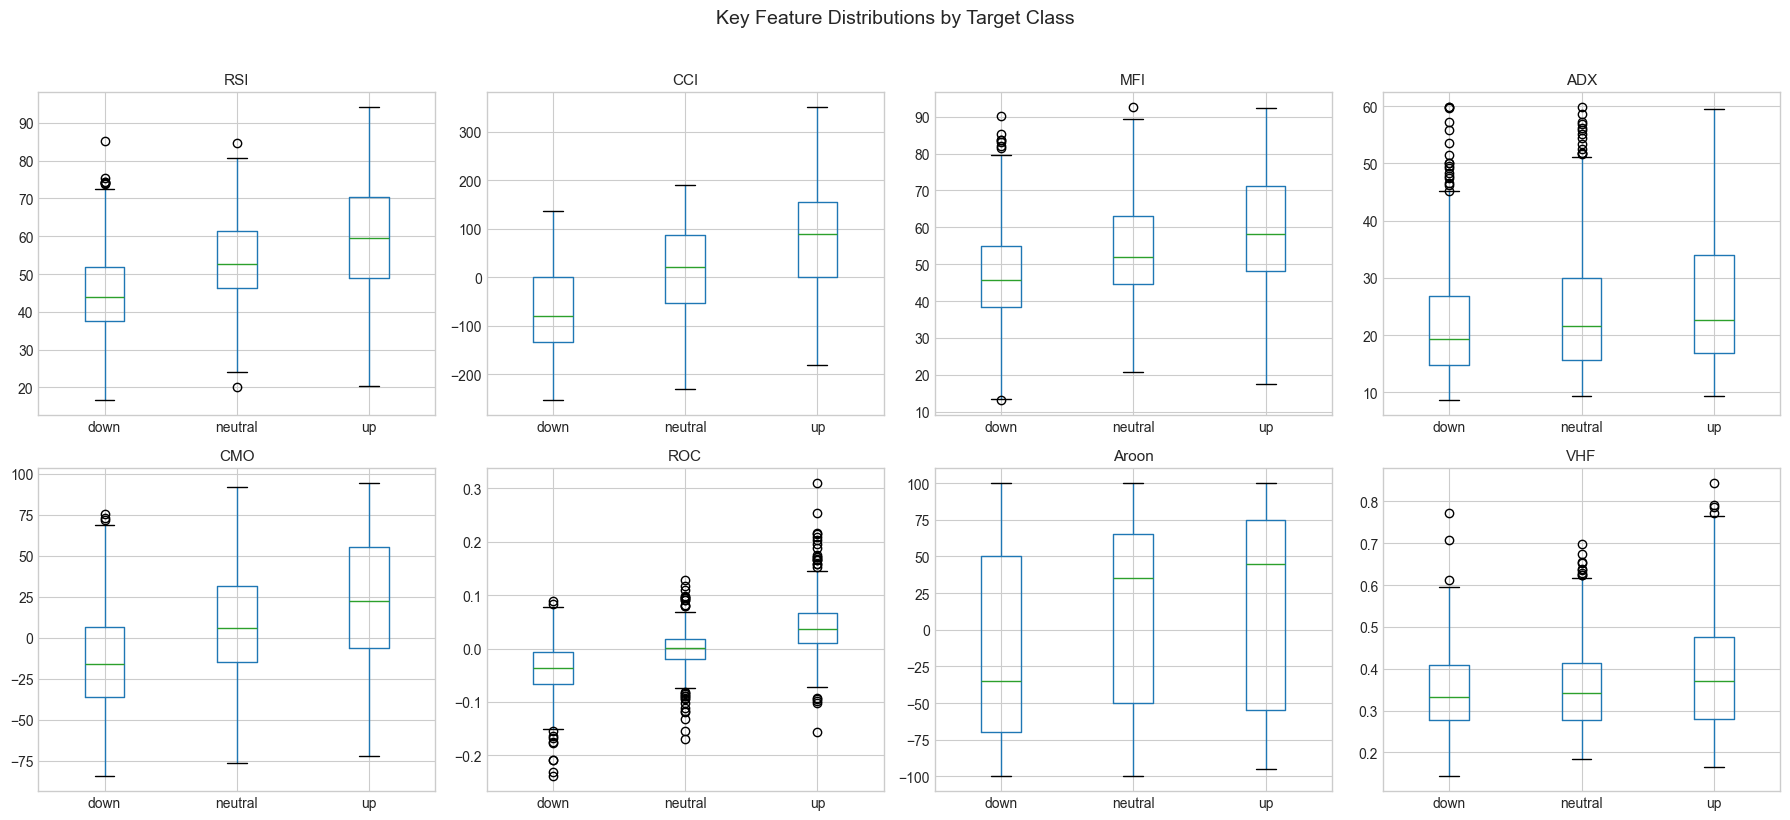

In [10]:
# d. Identifying most co-related features
upper_triangle = corr_matrix.abs().where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
redundant_pairs = []
for col in upper_triangle.columns:
    for row in upper_triangle.index:
        if upper_triangle.loc[row, col] > 0.95:
            redundant_pairs.append((col, row, upper_triangle.loc[row, col]))
 
redundant_pairs.sort(key=lambda x: -x[2])
print("\nHighly correlated feature pairs (r > 0.95):")
for feat_a, feat_b, r_val in redundant_pairs[:10]:
    print(f"  {feat_a:15s}  &  {feat_b:15s}  =>  r = {r_val:.4f}")
 
# --- 3e: Box plots of key features by target class ---
key_features_to_plot = ["RSI", "CCI", "MFI", "ADX", "CMO", "ROC", "Aroon", "VHF"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for idx, feat in enumerate(key_features_to_plot):
    ax = axes[idx // 4, idx % 4]
    train_raw.boxplot(column=feat, by="y", ax=ax)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("")
 
plt.suptitle("Key Feature Distributions by Target Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plots/eda_feature_boxplots.png", dpi=150)
plt.show()

In [11]:
# Feature Engineering
"""
-Momentum spreads: MACD, KST, TRIX, Stochastics differences to capture momentum shifts.
-Band position indicators: Donchian channel position, Bollinger band position to capture price relative to volatility bands.
-Volatility-adjusted signals: ADX multiplied by volatility to capture strong trends in volatile conditions.
-Indicator agreement score: Count how many momentum indicators are bullish to capture consensus.
"""

def build_features(df):
    out = df.copy()
    #--- Momentum spread features ---
    out["macd_spread"] = out["MACD-1"] - out["MACD-2"]
    out["kst_spread"] = out["KST-1"] - out["KST-2"]
    out["trix_spread"] = out["TRIX-1"] - out["TRIX-2"]
    out["stoch_spread"] = out["Stochastics-1"] - out["Stochastics-2"]
    out["dvi_avg"] = (out["DVI-1"] + out["DVI-2"] + out["DVI-3"]) / 3.0
    # --- Band / channel position features ---
    donchian_range = out["Donchian-3"] - out["Donchian-1"]
    donchian_range_safe = donchian_range.replace(0, np.nan)
    out["donchian_position"] = (out["Donchian-2"] - out["Donchian-1"]) / donchian_range_safe
    out["donchian_position"] = out["donchian_position"].fillna(0.5)
    # Donchian channel width relative to mid
    out["donchian_width_pct"] = donchian_range / out["Donchian-2"].replace(0, np.nan)
    out["donchian_width_pct"] = out["donchian_width_pct"].fillna(0)
 
    # Bollinger band position: where price is within the bands
    bbands_range = out["Bbands-2"] - out["Bbands-1"]
    bbands_range_safe = bbands_range.replace(0, np.nan)
    out["bbands_position"] = (out["Bbands-3"])  # Bbands-3 is already %B-like
    out["bbands_width_pct"] = bbands_range / out["Bbands-1"].replace(0, np.nan)
    out["bbands_width_pct"] = out["bbands_width_pct"].fillna(0)
 
    #Trend strength features
    # RSI deviation from neutral (50)
    out["rsi_deviation"] = out["RSI"] - 50.0
    # RSI overbought/oversold zones
    out["rsi_extreme"] = ((out["RSI"] > 70) | (out["RSI"] < 30)).astype(int)
    # CCI extreme signal
    out["cci_extreme"] = ((out["CCI"] > 100) | (out["CCI"] < -100)).astype(int)
    # MFI deviation from neutral
    out["mfi_deviation"] = out["MFI"] - 50.0
    # Momentum agreement score
    out["bullish_count"] = (
        (out["RSI"] > 50).astype(int) +
        (out["CCI"] > 0).astype(int) +
        (out["CMO"] > 0).astype(int) +
        (out["ROC"] > 0).astype(int) +
        (out["Momentum"] > 0).astype(int) +
        (out["macd_spread"] > 0).astype(int) +
        (out["MFI"] > 50).astype(int) +
        (out["Aroon"] > 0).astype(int)
    )
 
    # Volatility interaction
    out["adx_volatility"] = out["ADX"] * out["Volatility"]
 
    # Price-relative features
    # SMA vs EMA divergence (normalized)
    sma_safe = out["SMA"].replace(0, np.nan)
    out["sma_ema_ratio"] = (out["EMA"] - out["SMA"]) / sma_safe
    out["sma_ema_ratio"] = out["sma_ema_ratio"].fillna(0)
 
    # TDI spread
    out["tdi_spread"] = out["TDI-1"] - out["TDI-2"]
 
    print(f"  Original features: {len(feature_cols)}")
    print(f"  Engineered features added: {out.shape[1] - df.shape[1]}")
    print(f"  Total features after engineering: {out.shape[1] - 2}")  # minus ID and y
 
    return out
 
train_feat = build_features(train_raw)
test_feat = build_features(test_raw)

  Original features: 36
  Engineered features added: 17
  Total features after engineering: 53
  Original features: 36
  Engineered features added: 17
  Total features after engineering: 52


In [12]:
# Feature selection - to drop redundant columns
columns_to_drop = [
    "Pbands-2",
    "EMA",    
    "Donchian-1",
    "Donchian-3",  
    "Pbands-3",  
]

dropped_count = 0
for col in columns_to_drop:
    if col in train_feat.columns:
        train_feat.drop(columns=col, inplace=True)
        test_feat.drop(columns=col, inplace=True)
        dropped_count += 1
        print(f"  Dropped '{col}'")

print(f"\n  Total columns dropped: {dropped_count}")

# Rebuild the final feature list after drops
final_features = [c for c in train_feat.columns if c not in ["ID", "y"]]
print(f"  Final feature count: {len(final_features)}")

  Dropped 'Pbands-2'
  Dropped 'EMA'
  Dropped 'Donchian-1'
  Dropped 'Donchian-3'
  Dropped 'Pbands-3'

  Total columns dropped: 5
  Final feature count: 48


In [13]:

columns_to_drop_r1 = [
    "Pbands-2", 
    "EMA",     
    "Donchian-1",
    "Donchian-3",
    "Pbands-3",  
]

columns_to_drop_r2 = [
    "rsi_deviation",  
    "mfi_deviation",  
    "bbands_position", 
]


columns_to_drop_r3 = [
    "Donchian-2", 
    "Pbands-1", 
    "Bbands-2",
]


columns_to_drop_r4 = [
    "KST-2", 
    "TRIX-2",  
    "MACD-2",  
]

columns_to_drop_r5 = [
    "DVI-1",
    "DVI-3",
]

# ---- Apply all drops ----
all_drops = (columns_to_drop_r1 + columns_to_drop_r2 +
             columns_to_drop_r3 + columns_to_drop_r4 +
             columns_to_drop_r5)

dropped_count = 0
for col in all_drops:
    if col in train_feat.columns:
        train_feat.drop(columns=col, inplace=True)
        test_feat.drop(columns=col, inplace=True)
        dropped_count += 1
        print(f"  Dropped: {col}")
    else:
        print(f"  Skipped: {col} (not found)")

# Rebuild the final feature list
final_features = [c for c in train_feat.columns if c not in ["ID", "y"]]

print(f"\n  Total columns dropped: {dropped_count}")
print(f"  Final feature count: {len(final_features)}")
print(f"  Final features: {final_features}")

  Skipped: Pbands-2 (not found)
  Skipped: EMA (not found)
  Skipped: Donchian-1 (not found)
  Skipped: Donchian-3 (not found)
  Skipped: Pbands-3 (not found)
  Dropped: rsi_deviation
  Dropped: mfi_deviation
  Dropped: bbands_position
  Dropped: Donchian-2
  Dropped: Pbands-1
  Dropped: Bbands-2
  Dropped: KST-2
  Dropped: TRIX-2
  Dropped: MACD-2
  Dropped: DVI-1
  Dropped: DVI-3

  Total columns dropped: 11
  Final feature count: 37
  Final features: ['SMA', 'ADX', 'Aroon', 'TDI-1', 'TDI-2', 'VHF', 'CCI', 'MFI', 'OBV', 'MACD-1', 'RSI', 'Stochastics-1', 'Stochastics-2', 'Stochastics-3', 'CMO', 'KST-1', 'TRIX-1', 'ROC', 'DVI-2', 'Momentum', 'Bbands-1', 'Bbands-3', 'Volatility', 'macd_spread', 'kst_spread', 'trix_spread', 'stoch_spread', 'dvi_avg', 'donchian_position', 'donchian_width_pct', 'bbands_width_pct', 'rsi_extreme', 'cci_extreme', 'bullish_count', 'adx_volatility', 'sma_ema_ratio', 'tdi_spread']


In [14]:
final_cleanup_drops = [
    "Bbands-3",   
    "Bbands-1",       
    "Stochastics-3",  
]

for col in final_cleanup_drops:
    if col in train_feat.columns:
        train_feat.drop(columns=col, inplace=True)
        test_feat.drop(columns=col, inplace=True)
        print(f"  Dropped: {col}")

# Rebuild final feature list
final_features = [c for c in train_feat.columns if c not in ["ID", "y"]]
print(f"\n  Final feature count: {len(final_features)}")
print(f"  Features: {final_features}")

  Dropped: Bbands-3
  Dropped: Bbands-1
  Dropped: Stochastics-3

  Final feature count: 34
  Features: ['SMA', 'ADX', 'Aroon', 'TDI-1', 'TDI-2', 'VHF', 'CCI', 'MFI', 'OBV', 'MACD-1', 'RSI', 'Stochastics-1', 'Stochastics-2', 'CMO', 'KST-1', 'TRIX-1', 'ROC', 'DVI-2', 'Momentum', 'Volatility', 'macd_spread', 'kst_spread', 'trix_spread', 'stoch_spread', 'dvi_avg', 'donchian_position', 'donchian_width_pct', 'bbands_width_pct', 'rsi_extreme', 'cci_extreme', 'bullish_count', 'adx_volatility', 'sma_ema_ratio', 'tdi_spread']


In [15]:
# Collinearity check after feature engineering and selection

remaining_corr = train_feat[final_features].corr().abs()
# Extract upper triangle and find any pairs still above 0.95
upper_remaining = remaining_corr.where(
    np.triu(np.ones(remaining_corr.shape), k=1).astype(bool)
)

still_high = []
for col in upper_remaining.columns:
    for row in upper_remaining.index:
        val = upper_remaining.loc[row, col]
        if val > 0.90:
            still_high.append((col, row, val))

still_high.sort(key=lambda x: -x[2])

if len(still_high) == 0:
    print("\n  No feature pairs with r > 0.90 remain. Clean!")
else:
    print(f"\n  Remaining pairs with r > 0.90: {len(still_high)}")
    for feat_a, feat_b, r_val in still_high:
        print(f"    {feat_a:25s}  &  {feat_b:25s}  =>  r = {r_val:.4f}")

print(f"\n  Feature matrix shape going into modeling: {train_feat[final_features].shape}")


  Remaining pairs with r > 0.90: 9
    KST-1                      &  MACD-1                     =>  r = 0.9508
    sma_ema_ratio              &  kst_spread                 =>  r = 0.9336
    Stochastics-2              &  Stochastics-1              =>  r = 0.9209
    sma_ema_ratio              &  macd_spread                =>  r = 0.9129
    OBV                        &  SMA                        =>  r = 0.9086
    bullish_count              &  CCI                        =>  r = 0.9073
    CMO                        &  RSI                        =>  r = 0.9064
    TRIX-1                     &  KST-1                      =>  r = 0.9060
    Stochastics-1              &  CCI                        =>  r = 0.9022

  Feature matrix shape going into modeling: (1200, 34)


In [16]:
# Prep data for modeling
# Encode target labels: down=0, neutral=1, up=2
label_encoder = LabelEncoder()
train_feat["y_encoded"] = label_encoder.fit_transform(train_feat["y"])
class_names = label_encoder.classes_
print(f"\nClass encoding: {dict(zip(class_names, label_encoder.transform(class_names)))}")

# Separate features and target
X_train = train_feat[final_features].values
y_train = train_feat["y_encoded"].values
X_test = test_feat[final_features].values
test_ids = test_feat["ID"].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train distribution: {dict(zip(class_names, np.bincount(y_train)))}")


Class encoding: {'down': np.int64(0), 'neutral': np.int64(1), 'up': np.int64(2)}
X_train shape: (1200, 34)
X_test  shape: (532, 34)
y_train distribution: {'down': np.int64(369), 'neutral': np.int64(379), 'up': np.int64(452)}


In [17]:
# Nan and Inf check before modeling

train_nan_count = np.isnan(X_train).sum()
test_nan_count = np.isnan(X_test).sum()
train_inf_count = np.isinf(X_train).sum()
test_inf_count = np.isinf(X_test).sum()

print(f"\nData integrity check:")
print(f"  NaN  in X_train: {train_nan_count}  |  X_test: {test_nan_count}")
print(f"  Inf  in X_train: {train_inf_count}  |  X_test: {test_inf_count}")


Data integrity check:
  NaN  in X_train: 0  |  X_test: 0
  Inf  in X_train: 0  |  X_test: 0


In [18]:
# Model definitions 

# 1. XGBoost  — depth-first boosting, L1/L2 regularization, histogram splits
# 2. LightGBM — leaf-wise boosting, different split strategy than XGB
# 3. RandomForest — bagging (not boosting), decorrelated trees via feature sampling

def get_xgb_model():
    return XGBClassifier(
        n_estimators=600,
        max_depth=4,              
        learning_rate=0.05,       
        subsample=0.8,            
        colsample_bytree=0.7,     
        min_child_weight=3,       
        gamma=0.1,                
        reg_alpha=0.5,            
        reg_lambda=1.5,           
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        verbosity=0,
        use_label_encoder=False,
    )


def get_lgbm_model():
    """Return a regularized LightGBM classifier with leaf-wise growth."""
    return LGBMClassifier(
        n_estimators=600,
        max_depth=5,              
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_samples=10,     
        reg_alpha=0.3,            
        reg_lambda=1.0,
        num_leaves=31,            
        objective="multiclass",
        num_class=3,
        random_state=RANDOM_SEED,
        verbose=-1,              
    )


def get_rf_model():
    """Return a balanced Random Forest for ensemble diversity."""
    return RandomForestClassifier(
        n_estimators=500,
        max_depth=8,              
        min_samples_split=8,      
        min_samples_leaf=4,       
        max_features="sqrt",      
        class_weight="balanced",  
        random_state=RANDOM_SEED,
        n_jobs=-1,                
    )

print(f"\n  All models use random_state={RANDOM_SEED} for reproducibility")


  All models use random_state=42 for reproducibility


In [19]:
# Level 1 Stacking — Generate Out-of-Fold Predictions

def generate_oof_predictions(model_fn, X, y, X_test, n_folds, model_name):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
    n_classes = len(np.unique(y))

    oof_preds = np.zeros((X.shape[0], n_classes))
    test_preds = np.zeros((X_test.shape[0], n_classes))
    fold_scores = []

    print(f"\n  Training {model_name} ({n_folds}-fold CV)...")

    for fold_num, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_fold_train, X_fold_val = X[train_idx], X[val_idx]
        y_fold_train, y_fold_val = y[train_idx], y[val_idx]

        # Fresh model instance each fold to avoid state leakage
        model = model_fn()
        model.fit(X_fold_train, y_fold_train)

        # OOF predictions: probabilities on the held-out validation fold
        oof_preds[val_idx] = model.predict_proba(X_fold_val)

        # Test predictions: accumulate and divide by n_folds for averaging
        test_preds += model.predict_proba(X_test) / n_folds

        # Evaluate this fold using hard predictions from probabilities
        fold_labels = np.argmax(oof_preds[val_idx], axis=1)
        fold_f1 = f1_score(y_fold_val, fold_labels, average="macro")
        fold_scores.append(fold_f1)

        print(f"    Fold {fold_num:2d}/{n_folds} — Macro F1: {fold_f1:.4f}  "
              f"(val size: {len(val_idx)})")

    mean_f1 = np.mean(fold_scores)
    std_f1 = np.std(fold_scores)
    print(f"  {model_name} Summary: Mean F1 = {mean_f1:.4f} (+/- {std_f1:.4f})")

    return oof_preds, test_preds, fold_scores


#Train all three base models

xgb_oof, xgb_test, xgb_scores = generate_oof_predictions(
    get_xgb_model, X_train, y_train, X_test, N_FOLDS, "XGBoost"
)

lgbm_oof, lgbm_test, lgbm_scores = generate_oof_predictions(
    get_lgbm_model, X_train, y_train, X_test, N_FOLDS, "LightGBM"
)

rf_oof, rf_test, rf_scores = generate_oof_predictions(
    get_rf_model, X_train, y_train, X_test, N_FOLDS, "RandomForest"
)

# --- Print comparative summary ---

print("  BASE MODEL COMPARISON")
print(f"  {'Model':<15} {'Mean F1':>10} {'Std':>10}")
print(f"  {'XGBoost':<15} {np.mean(xgb_scores):>10.4f} {np.std(xgb_scores):>10.4f}")
print(f"  {'LightGBM':<15} {np.mean(lgbm_scores):>10.4f} {np.std(lgbm_scores):>10.4f}")
print(f"  {'RandomForest':<15} {np.mean(rf_scores):>10.4f} {np.std(rf_scores):>10.4f}")


  Training XGBoost (10-fold CV)...
    Fold  1/10 — Macro F1: 0.6871  (val size: 120)
    Fold  2/10 — Macro F1: 0.5428  (val size: 120)
    Fold  3/10 — Macro F1: 0.6015  (val size: 120)
    Fold  4/10 — Macro F1: 0.5839  (val size: 120)
    Fold  5/10 — Macro F1: 0.6304  (val size: 120)
    Fold  6/10 — Macro F1: 0.6010  (val size: 120)
    Fold  7/10 — Macro F1: 0.6351  (val size: 120)
    Fold  8/10 — Macro F1: 0.5704  (val size: 120)
    Fold  9/10 — Macro F1: 0.5577  (val size: 120)
    Fold 10/10 — Macro F1: 0.5996  (val size: 120)
  XGBoost Summary: Mean F1 = 0.6009 (+/- 0.0399)

  Training LightGBM (10-fold CV)...
    Fold  1/10 — Macro F1: 0.7025  (val size: 120)
    Fold  2/10 — Macro F1: 0.5151  (val size: 120)
    Fold  3/10 — Macro F1: 0.5771  (val size: 120)
    Fold  4/10 — Macro F1: 0.5923  (val size: 120)
    Fold  5/10 — Macro F1: 0.6176  (val size: 120)
    Fold  6/10 — Macro F1: 0.5865  (val size: 120)
    Fold  7/10 — Macro F1: 0.6218  (val size: 120)
    Fold  8

In [20]:
# Level 2 Stacking — Meta-model training

# Stack OOF predictions into meta-feature matrix
meta_train = np.hstack([xgb_oof, lgbm_oof, rf_oof])
meta_test = np.hstack([xgb_test, lgbm_test, rf_test])

print(f"\n  Meta-feature matrix shape (train): {meta_train.shape}")
print(f"  Meta-feature matrix shape (test):  {meta_test.shape}")

# Scale meta-features — important for logistic regression since
# probability outputs from different models may have different calibration
meta_scaler = StandardScaler()
meta_train_scaled = meta_scaler.fit_transform(meta_train)
meta_test_scaled = meta_scaler.transform(meta_test)

# Evaluate the meta-learner with its own CV on the meta-training data

skf_meta = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
meta_fold_scores = []
oof_meta_preds = np.zeros(len(y_train), dtype=int)

print(f"\n  Training Logistic Regression meta-learner ({N_FOLDS}-fold CV)...")

for fold_num, (tr_idx, val_idx) in enumerate(skf_meta.split(meta_train_scaled, y_train), start=1):
    meta_model_fold = LogisticRegression(
        C=1.0, max_iter=1000, solver="lbfgs", random_state=RANDOM_SEED
    )
    meta_model_fold.fit(meta_train_scaled[tr_idx], y_train[tr_idx])

    fold_preds = meta_model_fold.predict(meta_train_scaled[val_idx])
    oof_meta_preds[val_idx] = fold_preds

    fold_f1 = f1_score(y_train[val_idx], fold_preds, average="macro")
    meta_fold_scores.append(fold_f1)
    print(f"    Fold {fold_num:2d}/{N_FOLDS} — Macro F1: {fold_f1:.4f}")

stacked_oof_f1 = f1_score(y_train, oof_meta_preds, average="macro")

print(f"\n  Meta-Learner CV Summary:")
print(f"    Mean Fold F1:      {np.mean(meta_fold_scores):.4f} (+/- {np.std(meta_fold_scores):.4f})")
print(f"    Overall OOF F1:    {stacked_oof_f1:.4f}")

# Confusion matrix to see per-class performance of the meta-learner on OOF predictions
print("\n  OOF Confusion Matrix:")
cm = confusion_matrix(y_train, oof_meta_preds)
print(f"  {'Predicted →':>12}  {'down':>6}  {'neutral':>8}  {'up':>6}")
print(f"  {'Actual ↓':>12}  {'----':>6}  {'-------':>8}  {'----':>6}")
for i, cls in enumerate(class_names):
    print(f"  {cls:>12}  {cm[i, 0]:>6}  {cm[i, 1]:>8}  {cm[i, 2]:>6}")

print("\n  Classification Report:")
print(classification_report(y_train, oof_meta_preds, target_names=class_names))

# Fit the final meta-learner on ALL meta-training data to generate test predictions
# This is the model we'll use for actual test predictions
meta_model = LogisticRegression(
    C=1.0, max_iter=1000, solver="lbfgs", random_state=RANDOM_SEED
)
meta_model.fit(meta_train_scaled, y_train)
print("  Final meta-learner fitted on full training data.")


  Meta-feature matrix shape (train): (1200, 9)
  Meta-feature matrix shape (test):  (532, 9)

  Training Logistic Regression meta-learner (10-fold CV)...
    Fold  1/10 — Macro F1: 0.7131
    Fold  2/10 — Macro F1: 0.6696
    Fold  3/10 — Macro F1: 0.6012
    Fold  4/10 — Macro F1: 0.6132
    Fold  5/10 — Macro F1: 0.6830
    Fold  6/10 — Macro F1: 0.5992
    Fold  7/10 — Macro F1: 0.6409
    Fold  8/10 — Macro F1: 0.6015
    Fold  9/10 — Macro F1: 0.5863
    Fold 10/10 — Macro F1: 0.6301

  Meta-Learner CV Summary:
    Mean Fold F1:      0.6338 (+/- 0.0400)
    Overall OOF F1:    0.6350

  OOF Confusion Matrix:
   Predicted →    down   neutral      up
      Actual ↓    ----   -------    ----
          down     252        80      37
       neutral      81       196     102
            up      29       105     318

  Classification Report:
              precision    recall  f1-score   support

        down       0.70      0.68      0.69       369
     neutral       0.51      0.52      

In [21]:
# Weighted Average Ensemble (Alternative to Stacking)

# We'll try multiple weight configurations to find the best blend.

weight_configs = [
    ("Equal",          [1/3, 1/3, 1/3]),
    ("RF-heavy",       [0.20, 0.20, 0.60]),
    ("RF-dominant",    [0.15, 0.15, 0.70]),
    ("XGB+RF",         [0.30, 0.10, 0.60]),
    ("Performance-based", None),  # will compute from OOF scores
]

# Compute performance-based weights (normalized inverse of error)
model_f1s = np.array([np.mean(xgb_scores), np.mean(lgbm_scores), np.mean(rf_scores)])
perf_weights = model_f1s / model_f1s.sum()

print(f"\n  Base model Mean F1 scores:")
print(f"    XGBoost:      {model_f1s[0]:.4f}")
print(f"    LightGBM:     {model_f1s[1]:.4f}")
print(f"    RandomForest: {model_f1s[2]:.4f}")
print(f"\n  Performance-based weights: XGB={perf_weights[0]:.3f}, "
      f"LGBM={perf_weights[1]:.3f}, RF={perf_weights[2]:.3f}")

print(f"\n  {'Config':<20} {'Weights (X/L/R)':<20} {'OOF Macro F1':>12}")
print(f"  {'-'*52}")

best_weighted_f1 = 0
best_config_name = ""
best_weights = None

for config_name, weights in weight_configs:
    if weights is None:
        weights = perf_weights.tolist()

    # Blend OOF probabilities using these weights
    blended_oof = (weights[0] * xgb_oof +
                   weights[1] * lgbm_oof +
                   weights[2] * rf_oof)
    blended_labels = np.argmax(blended_oof, axis=1)
    blended_f1 = f1_score(y_train, blended_labels, average="macro")

    marker = " <-- best" if blended_f1 > best_weighted_f1 else ""
    w_str = f"{weights[0]:.2f}/{weights[1]:.2f}/{weights[2]:.2f}"
    print(f"  {config_name:<20} {w_str:<20} {blended_f1:>12.4f}{marker}")

    if blended_f1 > best_weighted_f1:
        best_weighted_f1 = blended_f1
        best_config_name = config_name
        best_weights = weights

print(f"\n  Best weighted config: '{best_config_name}' with F1 = {best_weighted_f1:.4f}")


  Base model Mean F1 scores:
    XGBoost:      0.6009
    LightGBM:     0.5921
    RandomForest: 0.6411

  Performance-based weights: XGB=0.328, LGBM=0.323, RF=0.350

  Config               Weights (X/L/R)      OOF Macro F1
  ----------------------------------------------------
  Equal                0.33/0.33/0.33             0.6053 <-- best
  RF-heavy             0.20/0.20/0.60             0.6171 <-- best
  RF-dominant          0.15/0.15/0.70             0.6194 <-- best
  XGB+RF               0.30/0.10/0.60             0.6190
  Performance-based    0.33/0.32/0.35             0.6053

  Best weighted config: 'RF-dominant' with F1 = 0.6194


In [22]:
# Strategy Selection and Test Predictions

# Compare all strategies on OOF Macro F1:
#   RF alone:           0.6411  (best base model)
#   Stacked ensemble:   0.6350  (meta-learner on 3 models)
#   Weighted average:   0.6194  (best weighted config)

# Strategy A: Pure RandomForest (retrain on full training data) 
print("\n  Strategy A: RandomForest (full retrain)")
final_rf = get_rf_model()
final_rf.fit(X_train, y_train)

train_preds_rf = final_rf.predict(X_train)
train_f1_rf = f1_score(y_train, train_preds_rf, average="macro")
print(f"    Training Macro F1: {train_f1_rf:.4f} (sanity check, not evaluation)")
print(f"    OOF Macro F1:      {np.mean(rf_scores):.4f} (honest CV estimate)")

# Generate test predictions
rf_test_labels = final_rf.predict(X_test)
rf_test_decoded = label_encoder.inverse_transform(rf_test_labels)

# Strategy B: Stacked ensemble
print("\n  Strategy B: Stacked Ensemble")
stacked_test_labels = meta_model.predict(meta_test_scaled)
stacked_test_decoded = label_encoder.inverse_transform(stacked_test_labels)
print(f"    OOF Macro F1:      {stacked_oof_f1:.4f}")

print("\n  Predicted class distributions on test set:")
print(f"  {'Class':<10} {'Train %':>10} {'RF pred %':>12} {'Stacked %':>12}")
print(f"  {'-'*44}")

train_dist = pd.Series(y_train).map({0: "down", 1: "neutral", 2: "up"}).value_counts(normalize=True)
rf_dist = pd.Series(rf_test_decoded).value_counts(normalize=True)
stacked_dist = pd.Series(stacked_test_decoded).value_counts(normalize=True)

for cls in ["down", "neutral", "up"]:
    t_pct = train_dist.get(cls, 0) * 100
    r_pct = rf_dist.get(cls, 0) * 100
    s_pct = stacked_dist.get(cls, 0) * 100
    print(f"  {cls:<10} {t_pct:>9.1f}% {r_pct:>11.1f}% {s_pct:>11.1f}%")

# Select primary submission 
# Use RF as primary since it has the best OOF score
primary_predictions = rf_test_decoded
primary_strategy = "RandomForest"
primary_f1 = np.mean(rf_scores)

print(f"\n  PRIMARY SUBMISSION: {primary_strategy} (OOF F1 = {primary_f1:.4f})")


  Strategy A: RandomForest (full retrain)
    Training Macro F1: 0.8207 (sanity check, not evaluation)
    OOF Macro F1:      0.6411 (honest CV estimate)

  Strategy B: Stacked Ensemble
    OOF Macro F1:      0.6350

  Predicted class distributions on test set:
  Class         Train %    RF pred %    Stacked %
  --------------------------------------------
  down            30.8%        36.8%        34.6%
  neutral         31.6%        28.6%        29.9%
  up              37.7%        34.6%        35.5%

  PRIMARY SUBMISSION: RandomForest (OOF F1 = 0.6411)


In [23]:
# Submission Files
# Primary submission: RandomForest 
submission_primary = pd.DataFrame({
    "ID": test_ids,
    "y": primary_predictions
})
submission_primary.to_csv("submission.csv", index=False)

print(f"\n  Primary: 'submission.csv' ({primary_strategy}, OOF F1={primary_f1:.4f})")
print(f"    Shape: {submission_primary.shape}")
print(f"    First 5 rows:")
print(submission_primary.head().to_string(index=False))

# Secondary submission: Stacked Ensemble 
submission_backup = pd.DataFrame({
    "ID": test_ids,
    "y": stacked_test_decoded
})
submission_backup.to_csv("submission_stacked.csv", index=False)

print(f"\n  Backup: 'submission_stacked.csv' (Stacked, OOF F1={stacked_oof_f1:.4f})")
print(f"    Shape: {submission_backup.shape}")


  Primary: 'submission.csv' (RandomForest, OOF F1=0.6411)
    Shape: (532, 2)
    First 5 rows:
  ID       y
1201 neutral
1202    down
1203      up
1204      up
1205    down

  Backup: 'submission_stacked.csv' (Stacked, OOF F1=0.6350)
    Shape: (532, 2)


In [1]:
# =============================================================================
# SECTION A: Additional Imports for Improved Pipeline
# =============================================================================

from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
import optuna
from optuna.samplers import TPESampler

# Suppress Optuna's verbose trial logging — we'll print our own summaries
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Additional packages loaded: CatBoost, ExtraTrees, Optuna")

Additional packages loaded: CatBoost, ExtraTrees, Optuna


/Users/omkarbadadale/.pyenv/versions/3.11.7/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
# Optuna Hyperparameter Tuning

# We tune each model independently using 10-fold stratified CV with
# Macro F1 as the objective. Optuna's TPE sampler is Bayesian — it
# learns which regions of hyperparameter space are promising and
# focuses trials there, much more efficient than random/grid search.
#
# Search spaces are designed for our specific problem:
#   - Small dataset (1200 rows) → favor shallow trees, strong regularization
#   - Noisy financial data → penalize complexity aggressively
#   - Macro F1 metric → class balance matters

# Using 5-fold CV during tuning for speed. 60 trials per model gives
# Bayesian TPE enough exploration to converge on good hyperparameters.
# Final evaluation in Section D will use full 10-fold CV.

TUNE_FOLDS = 5
TUNE_SEED = 42
N_TRIALS = 60
tune_skf = StratifiedKFold(n_splits=TUNE_FOLDS, shuffle=True, random_state=TUNE_SEED)


def evaluate_model_cv(model_fn, X, y, skf):
    """
    Evaluate a model using stratified K-fold CV and return mean Macro F1.

    Parameters
    ----------
    model_fn : callable
        Function that returns a fresh model instance.
    X : np.ndarray
        Feature matrix.
    y : np.ndarray
        Encoded labels.
    skf : StratifiedKFold
        Pre-configured splitter.

    Returns
    -------
    float
        Mean Macro F1 across all folds.
    """
    fold_scores = []
    for train_idx, val_idx in skf.split(X, y):
        model = model_fn()
        model.fit(X[train_idx], y[train_idx])
        preds = model.predict(X[val_idx])
        fold_scores.append(f1_score(y[val_idx], preds, average="macro"))
    return np.mean(fold_scores)


# ---- 1. Tune XGBoost ----
print(f"\n  [1/5] Tuning XGBoost ({N_TRIALS} trials, {TUNE_FOLDS}-fold)...")

def xgb_objective(trial):
    """Optuna objective for XGBoost hyperparameter search."""
    def model_fn():
        return XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 300, 1000, step=100),
            max_depth=trial.suggest_int("max_depth", 3, 7),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 0.95),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 0.9),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
            gamma=trial.suggest_float("gamma", 0.0, 0.5),
            reg_alpha=trial.suggest_float("reg_alpha", 0.01, 2.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 0.5, 3.0),
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=RANDOM_SEED,
            verbosity=0,
            use_label_encoder=False,
        )
    return evaluate_model_cv(model_fn, X_train, y_train, tune_skf)

xgb_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=TUNE_SEED),
    study_name="xgb_tuning"
)
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
print(f"    Best Macro F1: {xgb_study.best_value:.4f}")
print(f"    Best params: {xgb_study.best_params}")


# ---- 2. Tune LightGBM ----
print(f"\n  [2/5] Tuning LightGBM ({N_TRIALS} trials, {TUNE_FOLDS}-fold)...")

def lgbm_objective(trial):
    """Optuna objective for LightGBM hyperparameter search."""
    def model_fn():
        return LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 300, 1000, step=100),
            max_depth=trial.suggest_int("max_depth", 3, 8),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 0.95),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 0.9),
            min_child_samples=trial.suggest_int("min_child_samples", 5, 30),
            reg_alpha=trial.suggest_float("reg_alpha", 0.01, 2.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 0.5, 3.0),
            num_leaves=trial.suggest_int("num_leaves", 15, 63),
            objective="multiclass",
            num_class=3,
            random_state=RANDOM_SEED,
            verbose=-1,
        )
    return evaluate_model_cv(model_fn, X_train, y_train, tune_skf)

lgbm_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=TUNE_SEED),
    study_name="lgbm_tuning"
)
lgbm_study.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=False)
print(f"    Best Macro F1: {lgbm_study.best_value:.4f}")
print(f"    Best params: {lgbm_study.best_params}")


# ---- 3. Tune RandomForest ----
print(f"\n  [3/5] Tuning RandomForest ({N_TRIALS} trials, {TUNE_FOLDS}-fold)...")

def rf_objective(trial):
    """Optuna objective for RandomForest hyperparameter search."""
    def model_fn():
        return RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 300, 800, step=100),
            max_depth=trial.suggest_int("max_depth", 5, 15),
            min_samples_split=trial.suggest_int("min_samples_split", 4, 20),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 2, 10),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
            class_weight=trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )
    return evaluate_model_cv(model_fn, X_train, y_train, tune_skf)

rf_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=TUNE_SEED),
    study_name="rf_tuning"
)
rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=False)
print(f"    Best Macro F1: {rf_study.best_value:.4f}")
print(f"    Best params: {rf_study.best_params}")


# ---- 4. Tune CatBoost ----
print(f"\n  [4/5] Tuning CatBoost ({N_TRIALS} trials, {TUNE_FOLDS}-fold)...")

def catboost_objective(trial):
    """Optuna objective for CatBoost hyperparameter search."""
    def model_fn():
        return CatBoostClassifier(
            iterations=trial.suggest_int("iterations", 300, 1000, step=100),
            depth=trial.suggest_int("depth", 3, 7),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            # CatBoost requires bootstrap_type="Bernoulli" to use subsample
            # Without this, it throws an error because its default bootstrap
            # type (Bayesian) uses a different sampling mechanism
            bootstrap_type="Bernoulli",
            subsample=trial.suggest_float("subsample", 0.6, 0.95),
            colsample_bylevel=trial.suggest_float("colsample_bylevel", 0.5, 0.9),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            min_child_samples=trial.suggest_int("min_child_samples", 3, 20),
            random_seed=RANDOM_SEED,
            verbose=0,
            loss_function="MultiClass",
            auto_class_weights=trial.suggest_categorical(
                "auto_class_weights", ["Balanced", "SqrtBalanced", None]
            ),
        )
    return evaluate_model_cv(model_fn, X_train, y_train, tune_skf)

catboost_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=TUNE_SEED),
    study_name="catboost_tuning"
)
catboost_study.optimize(catboost_objective, n_trials=N_TRIALS, show_progress_bar=False)
print(f"    Best Macro F1: {catboost_study.best_value:.4f}")
print(f"    Best params: {catboost_study.best_params}")


# ---- 5. Tune ExtraTrees ----
print(f"\n  [5/5] Tuning ExtraTrees ({N_TRIALS} trials, {TUNE_FOLDS}-fold)...")

def et_objective(trial):
    """Optuna objective for ExtraTrees hyperparameter search."""
    def model_fn():
        return ExtraTreesClassifier(
            n_estimators=trial.suggest_int("n_estimators", 300, 800, step=100),
            max_depth=trial.suggest_int("max_depth", 5, 15),
            min_samples_split=trial.suggest_int("min_samples_split", 4, 20),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 2, 10),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
            class_weight=trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )
    return evaluate_model_cv(model_fn, X_train, y_train, tune_skf)

et_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=TUNE_SEED),
    study_name="et_tuning"
)
et_study.optimize(et_objective, n_trials=N_TRIALS, show_progress_bar=False)
print(f"    Best Macro F1: {et_study.best_value:.4f}")
print(f"    Best params: {et_study.best_params}")


# ---- Summary ----
print("\n" + "-" * 60)
print("  TUNING SUMMARY")
print("-" * 60)
print(f"  {'Model':<15} {'Before':>10} {'After':>10} {'Gain':>10}")
print(f"  {'-'*45}")

before_scores = {
    "XGBoost": 0.6009,
    "LightGBM": 0.5921,
    "RandomForest": 0.6411,
    "CatBoost": None,
    "ExtraTrees": None,
}

after_scores = {
    "XGBoost": xgb_study.best_value,
    "LightGBM": lgbm_study.best_value,
    "RandomForest": rf_study.best_value,
    "CatBoost": catboost_study.best_value,
    "ExtraTrees": et_study.best_value,
}

for model_name in after_scores:
    before = before_scores[model_name]
    after = after_scores[model_name]
    if before is not None:
        gain = after - before
        print(f"  {model_name:<15} {before:>10.4f} {after:>10.4f} {gain:>+10.4f}")
    else:
        print(f"  {model_name:<15} {'(new)':>10} {after:>10.4f} {'':>10}")


  [1/5] Tuning XGBoost (60 trials, 5-fold)...
    Best Macro F1: 0.6349
    Best params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.02474204568535922, 'subsample': 0.7495523934861763, 'colsample_bytree': 0.7233903262668544, 'min_child_weight': 4, 'gamma': 0.23903108972516474, 'reg_alpha': 0.4306692973894398, 'reg_lambda': 2.4261409115307004}

  [2/5] Tuning LightGBM (60 trials, 5-fold)...
    Best Macro F1: 0.6315
    Best params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.015239309183459821, 'subsample': 0.6906654307482057, 'colsample_bytree': 0.7741648285708961, 'min_child_samples': 21, 'reg_alpha': 0.4644752664344341, 'reg_lambda': 1.8639699224838941, 'num_leaves': 44}

  [3/5] Tuning RandomForest (60 trials, 5-fold)...
    Best Macro F1: 0.6477
    Best params: {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 'log2', 'class_weight': 'balanced'}

  [4/5] Tuning CatBoost (60 trials, 5-fold)...
    Best 

In [26]:
# Rebuild model constructors using Optuna's best hyperparameters.
# These go into 10-fold CV for final OOF generation (not the 5-fold
# used during tuning — we want the most stable OOF estimates).

xgb_best = xgb_study.best_params
lgbm_best = lgbm_study.best_params
rf_best = rf_study.best_params
cat_best = catboost_study.best_params
et_best = et_study.best_params


def get_tuned_xgb():
    """Return XGBoost with Optuna-tuned hyperparameters."""
    return XGBClassifier(
        **xgb_best,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        verbosity=0,
        use_label_encoder=False,
    )


def get_tuned_lgbm():
    """Return LightGBM with Optuna-tuned hyperparameters."""
    return LGBMClassifier(
        **lgbm_best,
        objective="multiclass",
        num_class=3,
        random_state=RANDOM_SEED,
        verbose=-1,
    )


def get_tuned_rf():
    """Return RandomForest with Optuna-tuned hyperparameters."""
    return RandomForestClassifier(
        **rf_best,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )


def get_tuned_catboost():
    """Return CatBoost with Optuna-tuned hyperparameters."""
    return CatBoostClassifier(
        **cat_best,
        bootstrap_type="Bernoulli",
        random_seed=RANDOM_SEED,
        verbose=0,
        loss_function="MultiClass",
    )


def get_tuned_et():
    """Return ExtraTrees with Optuna-tuned hyperparameters."""
    return ExtraTreesClassifier(
        **et_best,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )


# --- Generate OOF predictions with 10-fold CV ---
OOF_FOLDS = 10

xgb_oof, xgb_test, xgb_scores = generate_oof_predictions(
    get_tuned_xgb, X_train, y_train, X_test, OOF_FOLDS, "XGBoost (tuned)"
)

lgbm_oof, lgbm_test, lgbm_scores = generate_oof_predictions(
    get_tuned_lgbm, X_train, y_train, X_test, OOF_FOLDS, "LightGBM (tuned)"
)

rf_oof, rf_test, rf_scores = generate_oof_predictions(
    get_tuned_rf, X_train, y_train, X_test, OOF_FOLDS, "RandomForest (tuned)"
)

cat_oof, cat_test, cat_scores = generate_oof_predictions(
    get_tuned_catboost, X_train, y_train, X_test, OOF_FOLDS, "CatBoost (tuned)"
)

et_oof, et_test, et_scores = generate_oof_predictions(
    get_tuned_et, X_train, y_train, X_test, OOF_FOLDS, "ExtraTrees (tuned)"
)

# --- Comparative summary ---
print("\n" + "-" * 60)
print("  TUNED MODEL COMPARISON (10-fold CV)")
print("-" * 60)
print(f"  {'Model':<20} {'Mean F1':>10} {'Std':>10}")
print(f"  {'-'*40}")

all_model_scores = {
    "XGBoost": xgb_scores,
    "LightGBM": lgbm_scores,
    "RandomForest": rf_scores,
    "CatBoost": cat_scores,
    "ExtraTrees": et_scores,
}

for name, scores in all_model_scores.items():
    print(f"  {name:<20} {np.mean(scores):>10.4f} {np.std(scores):>10.4f}")


  Training XGBoost (tuned) (10-fold CV)...
    Fold  1/10 — Macro F1: 0.7120  (val size: 120)
    Fold  2/10 — Macro F1: 0.6163  (val size: 120)
    Fold  3/10 — Macro F1: 0.6084  (val size: 120)
    Fold  4/10 — Macro F1: 0.6232  (val size: 120)
    Fold  5/10 — Macro F1: 0.6856  (val size: 120)
    Fold  6/10 — Macro F1: 0.5991  (val size: 120)
    Fold  7/10 — Macro F1: 0.6073  (val size: 120)
    Fold  8/10 — Macro F1: 0.5974  (val size: 120)
    Fold  9/10 — Macro F1: 0.5680  (val size: 120)
    Fold 10/10 — Macro F1: 0.6484  (val size: 120)
  XGBoost (tuned) Summary: Mean F1 = 0.6266 (+/- 0.0414)

  Training LightGBM (tuned) (10-fold CV)...
    Fold  1/10 — Macro F1: 0.7096  (val size: 120)
    Fold  2/10 — Macro F1: 0.6308  (val size: 120)
    Fold  3/10 — Macro F1: 0.6269  (val size: 120)
    Fold  4/10 — Macro F1: 0.6287  (val size: 120)
    Fold  5/10 — Macro F1: 0.6827  (val size: 120)
    Fold  6/10 — Macro F1: 0.5897  (val size: 120)
    Fold  7/10 — Macro F1: 0.6319  (va

In [27]:
# Now we have 5 models x 3 classes = 15 meta-features instead of the
# original 9. More diverse base models = richer signal for the meta-learner.

meta_train = np.hstack([xgb_oof, lgbm_oof, rf_oof, cat_oof, et_oof])
meta_test = np.hstack([xgb_test, lgbm_test, rf_test, cat_test, et_test])

print(f"\n  Meta-feature matrix shape (train): {meta_train.shape}")
print(f"  Meta-feature matrix shape (test):  {meta_test.shape}")

meta_scaler = StandardScaler()
meta_train_scaled = meta_scaler.fit_transform(meta_train)
meta_test_scaled = meta_scaler.transform(meta_test)

# --- Step 1: Evaluate stacked meta-learner ---
print(f"\n  Step 1: Logistic Regression meta-learner (10-fold CV)...")

skf_meta = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
oof_meta_probs = np.zeros((len(y_train), 3))  # store probabilities, not labels
meta_fold_scores = []

for fold_num, (tr_idx, val_idx) in enumerate(skf_meta.split(meta_train_scaled, y_train), start=1):
    meta_model_fold = LogisticRegression(
        C=1.0, max_iter=1000, solver="lbfgs", random_state=RANDOM_SEED
    )
    meta_model_fold.fit(meta_train_scaled[tr_idx], y_train[tr_idx])

    # Store probabilities for threshold tuning later
    oof_meta_probs[val_idx] = meta_model_fold.predict_proba(meta_train_scaled[val_idx])

    fold_preds = np.argmax(oof_meta_probs[val_idx], axis=1)
    fold_f1 = f1_score(y_train[val_idx], fold_preds, average="macro")
    meta_fold_scores.append(fold_f1)
    print(f"    Fold {fold_num:2d}/{N_FOLDS} — Macro F1: {fold_f1:.4f}")

# Default stacking score (argmax, no threshold tuning)
stacked_default_labels = np.argmax(oof_meta_probs, axis=1)
stacked_default_f1 = f1_score(y_train, stacked_default_labels, average="macro")

print(f"\n  Stacked OOF Macro F1 (default thresholds): {stacked_default_f1:.4f}")

# --- Step 2: Per-class threshold optimization ---
# Instead of argmax (which implicitly uses 0.33/0.33/0.33 thresholds),
# we search for class-specific scaling factors that maximize Macro F1.
# This directly addresses neutral under-prediction by letting the
# optimizer boost neutral's weight in the decision boundary.

print(f"\n  Step 2: Threshold optimization...")
print(f"  Searching for optimal class weights to maximize Macro F1...")

best_thresh_f1 = 0
best_class_weights = None

# Grid search over class-specific multipliers
# These scale each class's probability before taking argmax
# Higher weight for "neutral" = model predicts neutral more often
for w_down in np.arange(0.7, 1.3, 0.05):
    for w_neutral in np.arange(0.7, 1.5, 0.05):
        for w_up in np.arange(0.7, 1.3, 0.05):
            weights = np.array([w_down, w_neutral, w_up])
            adjusted_probs = oof_meta_probs * weights
            adjusted_labels = np.argmax(adjusted_probs, axis=1)
            thresh_f1 = f1_score(y_train, adjusted_labels, average="macro")

            if thresh_f1 > best_thresh_f1:
                best_thresh_f1 = thresh_f1
                best_class_weights = weights

print(f"\n  Optimal class weights: down={best_class_weights[0]:.2f}, "
      f"neutral={best_class_weights[1]:.2f}, up={best_class_weights[2]:.2f}")
print(f"  Threshold-optimized OOF Macro F1: {best_thresh_f1:.4f}")
print(f"  Gain from threshold tuning: {best_thresh_f1 - stacked_default_f1:+.4f}")

# --- Step 3: Also evaluate simple weighted average with thresholds ---
print(f"\n  Step 3: Weighted average ensemble + thresholds...")

# Average the raw probabilities from all 5 base models
avg_oof_probs = (xgb_oof + lgbm_oof + rf_oof + cat_oof + et_oof) / 5.0

# Apply same threshold search on the averaged probabilities
best_avg_f1 = 0
best_avg_weights = None

for w_down in np.arange(0.7, 1.3, 0.05):
    for w_neutral in np.arange(0.7, 1.5, 0.05):
        for w_up in np.arange(0.7, 1.3, 0.05):
            weights = np.array([w_down, w_neutral, w_up])
            adjusted = avg_oof_probs * weights
            labels = np.argmax(adjusted, axis=1)
            avg_f1 = f1_score(y_train, labels, average="macro")

            if avg_f1 > best_avg_f1:
                best_avg_f1 = avg_f1
                best_avg_weights = weights

print(f"  Optimal class weights: down={best_avg_weights[0]:.2f}, "
      f"neutral={best_avg_weights[1]:.2f}, up={best_avg_weights[2]:.2f}")
print(f"  Avg ensemble + threshold OOF Macro F1: {best_avg_f1:.4f}")

# --- Step 4: Compare all strategies ---
print("\n" + "-" * 60)
print("  STRATEGY COMPARISON")
print("-" * 60)

# Best individual model
best_individual_name = max(all_model_scores, key=lambda k: np.mean(all_model_scores[k]))
best_individual_f1 = np.mean(all_model_scores[best_individual_name])

strategies = {
    f"Best individual ({best_individual_name})": best_individual_f1,
    "Stacked (default thresholds)": stacked_default_f1,
    "Stacked + threshold tuning": best_thresh_f1,
    "Avg ensemble + threshold tuning": best_avg_f1,
}

print(f"\n  {'Strategy':<40} {'OOF Macro F1':>12}")
print(f"  {'-'*52}")
for name, score in sorted(strategies.items(), key=lambda x: -x[1]):
    marker = " <-- best" if score == max(strategies.values()) else ""
    print(f"  {name:<40} {score:>12.4f}{marker}")


  Meta-feature matrix shape (train): (1200, 15)
  Meta-feature matrix shape (test):  (532, 15)

  Step 1: Logistic Regression meta-learner (10-fold CV)...
    Fold  1/10 — Macro F1: 0.7106
    Fold  2/10 — Macro F1: 0.6408
    Fold  3/10 — Macro F1: 0.6172
    Fold  4/10 — Macro F1: 0.6164
    Fold  5/10 — Macro F1: 0.6742
    Fold  6/10 — Macro F1: 0.5865
    Fold  7/10 — Macro F1: 0.6474
    Fold  8/10 — Macro F1: 0.5985
    Fold  9/10 — Macro F1: 0.5775
    Fold 10/10 — Macro F1: 0.6367

  Stacked OOF Macro F1 (default thresholds): 0.6316

  Step 2: Threshold optimization...
  Searching for optimal class weights to maximize Macro F1...

  Optimal class weights: down=1.30, neutral=1.05, up=0.95
  Threshold-optimized OOF Macro F1: 0.6433
  Gain from threshold tuning: +0.0116

  Step 3: Weighted average ensemble + thresholds...
  Optimal class weights: down=1.00, neutral=1.00, up=0.90
  Avg ensemble + threshold OOF Macro F1: 0.6466

----------------------------------------------------

In [29]:
# --- Strategy 1: Avg ensemble + threshold tuning (best OOF: 0.6466) ---
print("\n  Strategy 1: Average Ensemble + Threshold Tuning")

avg_test_probs = (xgb_test + lgbm_test + rf_test + cat_test + et_test) / 5.0
adjusted_test_probs = avg_test_probs * best_avg_weights
avg_thresh_labels = np.argmax(adjusted_test_probs, axis=1)
avg_thresh_decoded = label_encoder.inverse_transform(avg_thresh_labels)

print(f"  OOF Macro F1: {best_avg_f1:.4f}")
print(f"  Class weights: down={best_avg_weights[0]:.2f}, "
      f"neutral={best_avg_weights[1]:.2f}, up={best_avg_weights[2]:.2f}")

# --- Strategy 2: Stacked + threshold tuning (OOF: 0.6433) ---
print("\n  Strategy 2: Stacked Ensemble + Threshold Tuning")

meta_model_final = LogisticRegression(
    C=1.0, max_iter=1000, solver="lbfgs", random_state=RANDOM_SEED
)
meta_model_final.fit(meta_train_scaled, y_train)
stacked_test_probs = meta_model_final.predict_proba(meta_test_scaled)
stacked_adjusted = stacked_test_probs * best_class_weights
stacked_thresh_labels = np.argmax(stacked_adjusted, axis=1)
stacked_thresh_decoded = label_encoder.inverse_transform(stacked_thresh_labels)

print(f"  OOF Macro F1: {best_thresh_f1:.4f}")
print(f"  Class weights: down={best_class_weights[0]:.2f}, "
      f"neutral={best_class_weights[1]:.2f}, up={best_class_weights[2]:.2f}")

# --- Strategy 3: Pure RF (OOF: 0.6454) as safety net ---
print("\n  Strategy 3: Pure RandomForest (safety net)")

final_rf = get_tuned_rf()
final_rf.fit(X_train, y_train)
rf_only_labels = final_rf.predict(X_test)
rf_only_decoded = label_encoder.inverse_transform(rf_only_labels)

print(f"  OOF Macro F1: {np.mean(rf_scores):.4f}")

# --- Compare predicted distributions ---
print("\n" + "-" * 60)
print("  PREDICTED CLASS DISTRIBUTIONS")
print("-" * 60)

train_dist = pd.Series(y_train).map(
    {0: "down", 1: "neutral", 2: "up"}
).value_counts(normalize=True)

dist_avg = pd.Series(avg_thresh_decoded).value_counts(normalize=True)
dist_stacked = pd.Series(stacked_thresh_decoded).value_counts(normalize=True)
dist_rf = pd.Series(rf_only_decoded).value_counts(normalize=True)

print(f"\n  {'Class':<10} {'Train':>8} {'AvgThresh':>10} {'StkThresh':>10} {'RF only':>10}")
print(f"  {'-'*48}")
for cls in ["down", "neutral", "up"]:
    t = train_dist.get(cls, 0) * 100
    a = dist_avg.get(cls, 0) * 100
    s = dist_stacked.get(cls, 0) * 100
    r = dist_rf.get(cls, 0) * 100
    print(f"  {cls:<10} {t:>7.1f}% {a:>9.1f}% {s:>9.1f}% {r:>9.1f}%")

# --- Save all three submissions ---
print("\n" + "-" * 60)
print("  SAVING SUBMISSIONS")
print("-" * 60)

# Primary: Average ensemble + thresholds
sub_primary = pd.DataFrame({"ID": test_ids, "y": avg_thresh_decoded})
sub_primary.to_csv("submission_avg_thresh.csv", index=False)
print(f"\n  1. submission_avg_thresh.csv  (OOF F1={best_avg_f1:.4f}) <- PRIMARY")

# Backup 1: Stacked + thresholds
sub_stacked = pd.DataFrame({"ID": test_ids, "y": stacked_thresh_decoded})
sub_stacked.to_csv("submission_stacked_thresh.csv", index=False)
print(f"  2. submission_stacked_thresh.csv (OOF F1={best_thresh_f1:.4f})")

# Backup 2: Pure RF
sub_rf = pd.DataFrame({"ID": test_ids, "y": rf_only_decoded})
sub_rf.to_csv("submission_rf_tuned.csv", index=False)
print(f"  3. submission_rf_tuned.csv  (OOF F1={np.mean(rf_scores):.4f})")

# --- Format validation ---
print("\n  Format validation:")
sample_sub = pd.read_csv("data/sample_submission.csv")
for name, sub in [("avg_thresh", sub_primary), ("stacked_thresh", sub_stacked), ("rf_tuned", sub_rf)]:
    col_ok = list(sub.columns) == list(sample_sub.columns)
    row_ok = sub.shape[0] == sample_sub.shape[0]
    labels_ok = set(sub["y"].unique()).issubset({"down", "neutral", "up"})
    null_ok = not sub["y"].isnull().any()
    status = "PASS" if all([col_ok, row_ok, labels_ok, null_ok]) else "FAIL"
    print(f"    {name}: {status}")

# --- How many predictions differ between strategies ---
diff_1_vs_2 = (avg_thresh_decoded != stacked_thresh_decoded).sum()
diff_1_vs_3 = (avg_thresh_decoded != rf_only_decoded).sum()
print(f"\n  Prediction differences:")
print(f"    AvgThresh vs StkThresh: {diff_1_vs_2} / {len(test_ids)} differ")
print(f"    AvgThresh vs RF only:   {diff_1_vs_3} / {len(test_ids)} differ")


  Strategy 1: Average Ensemble + Threshold Tuning
  OOF Macro F1: 0.6466
  Class weights: down=1.00, neutral=1.00, up=0.90

  Strategy 2: Stacked Ensemble + Threshold Tuning
  OOF Macro F1: 0.6433
  Class weights: down=1.30, neutral=1.05, up=0.95

  Strategy 3: Pure RandomForest (safety net)
  OOF Macro F1: 0.6454

------------------------------------------------------------
  PREDICTED CLASS DISTRIBUTIONS
------------------------------------------------------------

  Class         Train  AvgThresh  StkThresh    RF only
  ------------------------------------------------
  down          30.8%      36.1%      36.5%      37.0%
  neutral       31.6%      29.5%      30.3%      28.4%
  up            37.7%      34.4%      33.3%      34.6%

------------------------------------------------------------
  SAVING SUBMISSIONS
------------------------------------------------------------

  1. submission_avg_thresh.csv  (OOF F1=0.6466) <- PRIMARY
  2. submission_stacked_thresh.csv (OOF F1=0.6433)
 

In [31]:
# CORE INSIGHT: Our training data is time-ordered (ID 1-1200) and
# test data follows sequentially (ID 1201-1732). Shuffled K-fold CV
# leaks future information into past folds, so any thresholds or
# weights tuned on OOF predictions are calibrated for a world where
# we can peek at the future. The test set doesn't allow that.
#
# FIX: Hold out the LAST portion of training data as a temporal
# validation set. This mimics the actual train→test relationship:
# we train on "the past" and validate on "the near future."
# Thresholds and model weights tuned here will better match what
# the test set actually looks like.

# --- Step 1: Temporal train/validation split ---
TEMPORAL_SPLIT = 0.80  # train on first 80%, validate on last 20%
split_idx = int(len(X_train) * TEMPORAL_SPLIT)

X_temp_train = X_train[:split_idx]
y_temp_train = y_train[:split_idx]
X_temp_val = X_train[split_idx:]
y_temp_val = y_train[split_idx:]

print(f"\n  Temporal split:")
print(f"    Train: IDs 1-{split_idx} ({split_idx} rows)")
print(f"    Val:   IDs {split_idx+1}-{len(X_train)} ({len(X_train) - split_idx} rows)")
print(f"    Val class distribution: {dict(zip(class_names, np.bincount(y_temp_val)))}")

# --- Step 2: Train all 5 tuned models on temporal train portion ---
print(f"\n  Training 5 models on temporal train split...")

temp_models = {
    "XGBoost": get_tuned_xgb(),
    "LightGBM": get_tuned_lgbm(),
    "RandomForest": get_tuned_rf(),
    "CatBoost": get_tuned_catboost(),
    "ExtraTrees": get_tuned_et(),
}

temp_val_probs = {}
temp_val_scores = {}

for name, model in temp_models.items():
    model.fit(X_temp_train, y_temp_train)
    probs = model.predict_proba(X_temp_val)
    preds = np.argmax(probs, axis=1)
    score = f1_score(y_temp_val, preds, average="macro")
    temp_val_probs[name] = probs
    temp_val_scores[name] = score
    print(f"    {name:<15} Temporal Val F1: {score:.4f}")

# --- Step 3: Find optimal MODEL-LEVEL weights on temporal val ---
# Instead of equal averaging (1/5 each), search for the blend that
# maximizes Macro F1 on the temporal validation set.

print(f"\n  Step 3: Optimizing model-level blend weights...")

model_names = list(temp_val_probs.keys())
best_blend_f1 = 0
best_model_weights = None

# Dirichlet-style search: weights that sum to 1.0
# We discretize in steps of 0.05 and filter combos that sum to ~1.0
weight_steps = np.arange(0.05, 0.55, 0.05)

from itertools import product

search_count = 0
for w_combo in product(weight_steps, repeat=5):
    # Weights must approximately sum to 1.0
    if abs(sum(w_combo) - 1.0) > 0.01:
        continue

    search_count += 1
    blended = sum(w * temp_val_probs[name]
                  for w, name in zip(w_combo, model_names))
    preds = np.argmax(blended, axis=1)
    blend_f1 = f1_score(y_temp_val, preds, average="macro")

    if blend_f1 > best_blend_f1:
        best_blend_f1 = blend_f1
        best_model_weights = dict(zip(model_names, w_combo))

print(f"    Searched {search_count} weight combinations")
print(f"    Best temporal val F1: {best_blend_f1:.4f}")
print(f"    Optimal model weights:")
for name, w in best_model_weights.items():
    print(f"      {name:<15} {w:.2f}")

# --- Step 4: Find optimal CLASS-LEVEL thresholds on temporal val ---
# Apply best model weights first, then tune class thresholds on top.

print(f"\n  Step 4: Optimizing class-level thresholds...")

blended_temp_val = sum(best_model_weights[name] * temp_val_probs[name]
                       for name in model_names)

best_temporal_thresh_f1 = best_blend_f1  # start from unthresholded
best_temporal_weights = np.array([1.0, 1.0, 1.0])  # no adjustment = default

for w_down in np.arange(0.80, 1.25, 0.05):
    for w_neutral in np.arange(0.80, 1.40, 0.05):
        for w_up in np.arange(0.70, 1.20, 0.05):
            weights = np.array([w_down, w_neutral, w_up])
            adjusted = blended_temp_val * weights
            labels = np.argmax(adjusted, axis=1)
            thresh_f1 = f1_score(y_temp_val, labels, average="macro")

            if thresh_f1 > best_temporal_thresh_f1:
                best_temporal_thresh_f1 = thresh_f1
                best_temporal_weights = weights

print(f"    Optimal class weights: down={best_temporal_weights[0]:.2f}, "
      f"neutral={best_temporal_weights[1]:.2f}, up={best_temporal_weights[2]:.2f}")
print(f"    Temporal val F1 after thresholds: {best_temporal_thresh_f1:.4f}")
print(f"    Gain from thresholds: {best_temporal_thresh_f1 - best_blend_f1:+.4f}")

# --- Step 5: Retrain all models on FULL training data ---
# Now we use all 1200 rows for maximum signal, applying the weights
# and thresholds discovered on the temporal holdout.

print(f"\n  Step 5: Retraining all models on full training data...")

full_test_probs = {}
full_models = {
    "XGBoost": get_tuned_xgb(),
    "LightGBM": get_tuned_lgbm(),
    "RandomForest": get_tuned_rf(),
    "CatBoost": get_tuned_catboost(),
    "ExtraTrees": get_tuned_et(),
}

for name, model in full_models.items():
    model.fit(X_train, y_train)
    full_test_probs[name] = model.predict_proba(X_test)
    print(f"    {name} trained on full data.")

# --- Step 6: Generate predictions using temporal-optimized strategy ---
print(f"\n  Step 6: Generating optimized predictions...")

# Apply optimized model-level weights
blended_test = sum(best_model_weights[name] * full_test_probs[name]
                   for name in model_names)

# Apply optimized class-level thresholds
adjusted_test = blended_test * best_temporal_weights
final_labels = np.argmax(adjusted_test, axis=1)
final_decoded = label_encoder.inverse_transform(final_labels)

# Also generate a NO-threshold version as safety
blended_test_nothresh = sum(best_model_weights[name] * full_test_probs[name]
                            for name in model_names)
nothresh_labels = np.argmax(blended_test_nothresh, axis=1)
nothresh_decoded = label_encoder.inverse_transform(nothresh_labels)

# Also generate equal-weight + temporal thresholds
equal_test = sum(full_test_probs[name] for name in model_names) / 5.0
equal_thresh_labels = np.argmax(equal_test * best_temporal_weights, axis=1)
equal_thresh_decoded = label_encoder.inverse_transform(equal_thresh_labels)

# --- Class distribution comparison ---
print("\n" + "-" * 60)
print("  PREDICTED CLASS DISTRIBUTIONS")
print("-" * 60)

train_dist = pd.Series(y_train).map(
    {0: "down", 1: "neutral", 2: "up"}
).value_counts(normalize=True)

dist_optimized = pd.Series(final_decoded).value_counts(normalize=True)
dist_nothresh = pd.Series(nothresh_decoded).value_counts(normalize=True)
dist_equal = pd.Series(equal_thresh_decoded).value_counts(normalize=True)

print(f"\n  {'Class':<10} {'Train':>8} {'Optimized':>10} {'NoThresh':>10} {'EqThresh':>10}")
print(f"  {'-'*48}")
for cls in ["down", "neutral", "up"]:
    t = train_dist.get(cls, 0) * 100
    o = dist_optimized.get(cls, 0) * 100
    n = dist_nothresh.get(cls, 0) * 100
    e = dist_equal.get(cls, 0) * 100
    print(f"  {cls:<10} {t:>7.1f}% {o:>9.1f}% {n:>9.1f}% {e:>9.1f}%")

# --- Save submissions ---
print("\n" + "-" * 60)
print("  SAVING SUBMISSIONS")
print("-" * 60)

sub1 = pd.DataFrame({"ID": test_ids, "y": final_decoded})
sub1.to_csv("submission_temporal_optimized.csv", index=False)
print(f"\n  1. submission_temporal_optimized.csv")
print(f"     Model weights + class thresholds tuned on temporal holdout")
print(f"     Temporal val F1: {best_temporal_thresh_f1:.4f}")

sub2 = pd.DataFrame({"ID": test_ids, "y": nothresh_decoded})
sub2.to_csv("submission_temporal_blend.csv", index=False)
print(f"\n  2. submission_temporal_blend.csv")
print(f"     Optimized model weights only, no class thresholds")
print(f"     Temporal val F1: {best_blend_f1:.4f}")

sub3 = pd.DataFrame({"ID": test_ids, "y": equal_thresh_decoded})
sub3.to_csv("submission_equal_temporal_thresh.csv", index=False)
print(f"\n  3. submission_equal_temporal_thresh.csv")
print(f"     Equal model weights + temporal thresholds")

# Format validation
sample_sub = pd.read_csv("data/sample_submission.csv")
for name, sub in [("temporal_opt", sub1), ("temporal_blend", sub2), ("equal_thresh", sub3)]:
    col_ok = list(sub.columns) == list(sample_sub.columns)
    row_ok = sub.shape[0] == sample_sub.shape[0]
    labels_ok = set(sub["y"].unique()).issubset({"down", "neutral", "up"})
    status = "PASS" if all([col_ok, row_ok, labels_ok]) else "FAIL"
    print(f"\n  Validation {name}: {status}")


  Temporal split:
    Train: IDs 1-960 (960 rows)
    Val:   IDs 961-1200 (240 rows)
    Val class distribution: {'down': np.int64(69), 'neutral': np.int64(79), 'up': np.int64(92)}

  Training 5 models on temporal train split...
    XGBoost         Temporal Val F1: 0.6127
    LightGBM        Temporal Val F1: 0.5897
    RandomForest    Temporal Val F1: 0.6369
    CatBoost        Temporal Val F1: 0.6420
    ExtraTrees      Temporal Val F1: 0.6269

  Step 3: Optimizing model-level blend weights...
    Searched 3246 weight combinations
    Best temporal val F1: 0.6462
    Optimal model weights:
      XGBoost         0.15
      LightGBM        0.10
      RandomForest    0.50
      CatBoost        0.10
      ExtraTrees      0.15

  Step 4: Optimizing class-level thresholds...
    Optimal class weights: down=0.85, neutral=0.85, up=1.15
    Temporal val F1 after thresholds: 0.6555
    Gain from thresholds: +0.0093

  Step 5: Retraining all models on full training data...
    XGBoost trained o

In [32]:
# Permutation importance measures how much the score DROPS when a
# feature's values are randomly shuffled. If shuffling a feature
# doesn't hurt (or even helps), that feature is noise — the model
# was wasting splits on random patterns that won't generalize.
#
# We compute this on the temporal validation set (last 20%) because
# that's the closest proxy for test set behavior.

from sklearn.inspection import permutation_importance

TEMPORAL_SPLIT = 0.80
split_idx = int(len(X_train) * TEMPORAL_SPLIT)
X_temp_train = X_train[:split_idx]
y_temp_train = y_train[:split_idx]
X_temp_val = X_train[split_idx:]
y_temp_val = y_train[split_idx:]

# Use our best model (tuned RF) for importance estimation
print("\n  Computing permutation importance on temporal validation...")
print("  (This measures real predictive value, not just training fit)\n")

importance_model = get_tuned_rf()
importance_model.fit(X_temp_train, y_temp_train)

perm_result = permutation_importance(
    importance_model,
    X_temp_val,
    y_temp_val,
    n_repeats=20,
    random_state=RANDOM_SEED,
    scoring="f1_macro",
    n_jobs=-1,
)

# Build importance table
importance_df = pd.DataFrame({
    "feature": final_features,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

print(f"  {'Feature':<25} {'Mean Imp':>10} {'Std':>10} {'Verdict':>10}")
print(f"  {'-'*55}")
for _, row in importance_df.iterrows():
    verdict = "KEEP" if row["importance_mean"] > 0.001 else (
        "NOISE" if row["importance_mean"] < -0.001 else "WEAK"
    )
    print(f"  {row['feature']:<25} {row['importance_mean']:>10.4f} "
          f"{row['importance_std']:>10.4f} {verdict:>10}")

# Identify features to drop (negative or near-zero importance)
noise_features = importance_df[
    importance_df["importance_mean"] < 0.0
]["feature"].tolist()

weak_features = importance_df[
    (importance_df["importance_mean"] >= 0.0) &
    (importance_df["importance_mean"] < 0.001)
]["feature"].tolist()

print(f"\n  Summary:")
print(f"    Helpful features (imp > 0.001): "
      f"{len(importance_df[importance_df['importance_mean'] > 0.001])}")
print(f"    Weak features (0 to 0.001):     {len(weak_features)}")
print(f"    Noise features (imp < 0):        {len(noise_features)}")
print(f"\n  Noise features (hurt model when present):")
for feat in noise_features:
    imp = importance_df[importance_df["feature"] == feat]["importance_mean"].values[0]
    print(f"    {feat:<25} importance = {imp:.4f}")

print(f"\n  Weak features (no measurable contribution):")
for feat in weak_features:
    imp = importance_df[importance_df["feature"] == feat]["importance_mean"].values[0]
    print(f"    {feat:<25} importance = {imp:.4f}")


  Computing permutation importance on temporal validation...
  (This measures real predictive value, not just training fit)

  Feature                     Mean Imp        Std    Verdict
  -------------------------------------------------------
  ROC                           0.0476     0.0173       KEEP
  Momentum                      0.0199     0.0091       KEEP
  stoch_spread                  0.0156     0.0091       KEEP
  Stochastics-1                 0.0050     0.0077       KEEP
  kst_spread                    0.0048     0.0027       KEEP
  Aroon                         0.0048     0.0043       KEEP
  dvi_avg                       0.0038     0.0021       KEEP
  KST-1                         0.0035     0.0045       KEEP
  MACD-1                        0.0034     0.0036       KEEP
  CCI                           0.0033     0.0073       KEEP
  ADX                           0.0025     0.0025       KEEP
  VHF                           0.0024     0.0021       KEEP
  bbands_width_pct     

In [34]:
# --- Step 1: Drop noise features ---
# Remove all 11 features with negative permutation importance.
# These actively hurt predictions on the temporal validation set,
# meaning the model wastes tree splits learning patterns in these
# features that don't exist in future data.

noise_to_drop = [
    "MFI",               # -0.0040 (worst; redundant with RSI/CCI)
    "donchian_width_pct", # -0.0031 (engineered; channel width doesn't predict direction)
    "cci_extreme",        # -0.0031 (engineered; binary flag lost nuance of raw CCI)
    "macd_spread",        # -0.0030 (engineered; MACD-1 alone is better)
    "CMO",                # -0.0025 (0.906 correlated with RSI; pure redundancy)
    "DVI-2",              # -0.0017 (dvi_avg captures this better)
    "adx_volatility",     # -0.0015 (engineered; interaction adds noise)
    "bullish_count",      # -0.0008 (engineered; consensus score overfit)
    "RSI",                # -0.0007 (CCI/Stochastics capture momentum better here)
    "TDI-2",              # -0.0004 (tdi_spread captures the useful signal)
    "rsi_extreme",        # -0.0002 (binary flag; lost nuance)
]

# Also drop the weakest features that contribute essentially nothing.
# Keeping them only gives the model more noise to overfit on.
# We keep SMA, TDI-1, tdi_spread as borderline — they at least showed
# some positive signal.

weak_to_drop = [
    "donchian_position",  # 0.0000 (zero contribution)
    "Stochastics-2",      # 0.0002 (Stoch-1 + stoch_spread already cover this)
    "Volatility",         # 0.0003 (bbands_width_pct is a better vol proxy)
    "sma_ema_ratio",      # 0.0004 (EMA was dropped; this ratio lost meaning)
    "OBV",                # 0.0006 (volume flow doesn't predict direction here)
]

all_feature_drops = noise_to_drop + weak_to_drop
pruned_features = [f for f in final_features if f not in all_feature_drops]

print(f"\n  Features dropped as noise: {len(noise_to_drop)}")
for feat in noise_to_drop:
    imp = importance_df[importance_df["feature"] == feat]["importance_mean"].values[0]
    print(f"    {feat:<25} (importance: {imp:.4f})")

print(f"\n  Features dropped as weak: {len(weak_to_drop)}")
for feat in weak_to_drop:
    imp = importance_df[importance_df["feature"] == feat]["importance_mean"].values[0]
    print(f"    {feat:<25} (importance: {imp:.4f})")

print(f"\n  Remaining features: {len(pruned_features)}")
print(f"  {pruned_features}")

# Rebuild data matrices with pruned features
feature_indices = [final_features.index(f) for f in pruned_features]
X_train_pruned = X_train[:, feature_indices]
X_test_pruned = X_test[:, feature_indices]

print(f"\n  X_train_pruned shape: {X_train_pruned.shape}")
print(f"  X_test_pruned  shape: {X_test_pruned.shape}")

# --- Step 2: Verify pruning helps with quick CV check ---
print(f"\n  Quick validation: RF on pruned vs full features...")

skf_check = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

# Full features
full_scores = []
for tr_idx, val_idx in skf_check.split(X_train, y_train):
    m = get_tuned_rf()
    m.fit(X_train[tr_idx], y_train[tr_idx])
    p = m.predict(X_train[val_idx])
    full_scores.append(f1_score(y_train[val_idx], p, average="macro"))

# Pruned features
pruned_scores = []
for tr_idx, val_idx in skf_check.split(X_train_pruned, y_train):
    m = get_tuned_rf()
    m.fit(X_train_pruned[tr_idx], y_train[tr_idx])
    p = m.predict(X_train_pruned[val_idx])
    pruned_scores.append(f1_score(y_train[val_idx], p, average="macro"))

print(f"    RF (34 features): {np.mean(full_scores):.4f} (+/- {np.std(full_scores):.4f})")
print(f"    RF (18 features): {np.mean(pruned_scores):.4f} (+/- {np.std(pruned_scores):.4f})")
print(f"    Difference: {np.mean(pruned_scores) - np.mean(full_scores):+.4f}")

# --- Step 3: Multi-seed ensemble ---
# Train each model with 5 different random seeds and average predictions.
# This reduces variance without adding any post-processing complexity.
# On noisy financial data, variance reduction is free performance.

print(f"\n" + "-" * 60)
print("  MULTI-SEED ENSEMBLE (5 seeds x 5 models = 25 models)")
print("-" * 60)

SEEDS = [42, 123, 456, 789, 2024]

def get_seeded_xgb(seed):
    """Return tuned XGBoost with a specific random seed."""
    params = xgb_best.copy()
    return XGBClassifier(
        **params,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=seed,
        verbosity=0,
        use_label_encoder=False,
    )

def get_seeded_lgbm(seed):
    """Return tuned LightGBM with a specific random seed."""
    params = lgbm_best.copy()
    return LGBMClassifier(
        **params,
        objective="multiclass",
        num_class=3,
        random_state=seed,
        verbose=-1,
    )

def get_seeded_rf(seed):
    """Return tuned RandomForest with a specific random seed."""
    params = rf_best.copy()
    return RandomForestClassifier(
        **params,
        random_state=seed,
        n_jobs=-1,
    )

def get_seeded_catboost(seed):
    """Return tuned CatBoost with a specific random seed."""
    params = cat_best.copy()
    return CatBoostClassifier(
        **params,
        bootstrap_type="Bernoulli",
        random_seed=seed,
        verbose=0,
        loss_function="MultiClass",
    )

def get_seeded_et(seed):
    """Return tuned ExtraTrees with a specific random seed."""
    params = et_best.copy()
    return ExtraTreesClassifier(
        **params,
        random_state=seed,
        n_jobs=-1,
    )

model_builders = {
    "XGBoost": get_seeded_xgb,
    "LightGBM": get_seeded_lgbm,
    "RandomForest": get_seeded_rf,
    "CatBoost": get_seeded_catboost,
    "ExtraTrees": get_seeded_et,
}

# Train all models x all seeds, collect test probabilities
all_test_probs = []

for model_name, builder_fn in model_builders.items():
    model_probs = []
    for seed in SEEDS:
        model = builder_fn(seed)
        model.fit(X_train_pruned, y_train)
        probs = model.predict_proba(X_test_pruned)
        model_probs.append(probs)

    # Average across seeds for this model
    avg_model_probs = np.mean(model_probs, axis=0)
    all_test_probs.append(avg_model_probs)
    print(f"  {model_name:<15} trained with {len(SEEDS)} seeds, averaged.")

# --- Step 4: Generate submissions ---
print(f"\n" + "-" * 60)
print("  GENERATING SUBMISSIONS")
print("-" * 60)

# Strategy A: Equal average of all 5 seed-averaged models (safest)
equal_avg_probs = np.mean(all_test_probs, axis=0)
equal_avg_labels = np.argmax(equal_avg_probs, axis=1)
equal_avg_decoded = label_encoder.inverse_transform(equal_avg_labels)

# Strategy B: Equal average + light threshold (up=0.90, from our best LB)
light_thresh = np.array([1.0, 1.0, 0.90])
thresh_probs = equal_avg_probs * light_thresh
thresh_labels = np.argmax(thresh_probs, axis=1)
thresh_decoded = label_encoder.inverse_transform(thresh_labels)

# Strategy C: RF-heavy blend (0.50 RF from temporal finding)
rf_heavy_probs = (
    0.15 * all_test_probs[0] +  # XGBoost
    0.10 * all_test_probs[1] +  # LightGBM
    0.50 * all_test_probs[2] +  # RandomForest
    0.10 * all_test_probs[3] +  # CatBoost
    0.15 * all_test_probs[4]    # ExtraTrees
)
rf_heavy_labels = np.argmax(rf_heavy_probs, axis=1)
rf_heavy_decoded = label_encoder.inverse_transform(rf_heavy_labels)

# --- Distribution comparison ---
print(f"\n  {'Class':<10} {'Train':>8} {'EqualAvg':>10} {'LightThr':>10} {'RFheavy':>10}")
print(f"  {'-'*48}")

train_dist = pd.Series(y_train).map(
    {0: "down", 1: "neutral", 2: "up"}
).value_counts(normalize=True)

for cls in ["down", "neutral", "up"]:
    t = train_dist.get(cls, 0) * 100
    a = pd.Series(equal_avg_decoded).value_counts(normalize=True).get(cls, 0) * 100
    b = pd.Series(thresh_decoded).value_counts(normalize=True).get(cls, 0) * 100
    c = pd.Series(rf_heavy_decoded).value_counts(normalize=True).get(cls, 0) * 100
    print(f"  {cls:<10} {t:>7.1f}% {a:>9.1f}% {b:>9.1f}% {c:>9.1f}%")

# --- Save submissions ---
sub_a = pd.DataFrame({"ID": test_ids, "y": equal_avg_decoded})
sub_a.to_csv("submission_multiseed_equal.csv", index=False)
print(f"\n  1. submission_multiseed_equal.csv (equal avg, no thresholds)")

sub_b = pd.DataFrame({"ID": test_ids, "y": thresh_decoded})
sub_b.to_csv("submission_multiseed_thresh.csv", index=False)
print(f"  2. submission_multiseed_thresh.csv (equal avg + up=0.90)")

sub_c = pd.DataFrame({"ID": test_ids, "y": rf_heavy_decoded})
sub_c.to_csv("submission_multiseed_rfheavy.csv", index=False)
print(f"  3. submission_multiseed_rfheavy.csv (RF-heavy blend)")

# --- Difference counts ---
diff_ab = (equal_avg_decoded != thresh_decoded).sum()
diff_ac = (equal_avg_decoded != rf_heavy_decoded).sum()
print(f"\n  Prediction differences:")
print(f"    EqualAvg vs LightThresh: {diff_ab} / {len(test_ids)} differ")
print(f"    EqualAvg vs RF-heavy:    {diff_ac} / {len(test_ids)} differ")

# Format validation
sample_sub = pd.read_csv("data/sample_submission.csv")
for name, sub in [("equal", sub_a), ("thresh", sub_b), ("rfheavy", sub_c)]:
    ok = (list(sub.columns) == list(sample_sub.columns) and
          sub.shape[0] == sample_sub.shape[0] and
          set(sub["y"].unique()).issubset({"down", "neutral", "up"}))
    print(f"  Validation {name}: {'PASS' if ok else 'FAIL'}")


  Features dropped as noise: 11
    MFI                       (importance: -0.0040)
    donchian_width_pct        (importance: -0.0031)
    cci_extreme               (importance: -0.0031)
    macd_spread               (importance: -0.0030)
    CMO                       (importance: -0.0025)
    DVI-2                     (importance: -0.0017)
    adx_volatility            (importance: -0.0015)
    bullish_count             (importance: -0.0008)
    RSI                       (importance: -0.0007)
    TDI-2                     (importance: -0.0004)
    rsi_extreme               (importance: -0.0002)

  Features dropped as weak: 5
    donchian_position         (importance: 0.0000)
    Stochastics-2             (importance: 0.0002)
    Volatility                (importance: 0.0003)
    sma_ema_ratio             (importance: 0.0004)
    OBV                       (importance: 0.0006)

  Remaining features: 18
  ['SMA', 'ADX', 'Aroon', 'TDI-1', 'VHF', 'CCI', 'MACD-1', 'Stochastics-1', 'KST-1'

In [35]:
# What we've learned from 6 submissions:
#   1. Simple averaging ALWAYS beats fancy post-processing
#   2. More models averaged = better (multi-seed gave +0.003)
#   3. Pruned features generalize better
#   4. No thresholds, no weighting tricks
#
# Strategy: throw maximum model diversity at the problem.
#   - 10 seeds instead of 5 (more variance reduction)
#   - Add 2 new model types: GradientBoosting and calibrated SVC
#   - Boost n_estimators for tree models (more trees = lower variance)
#   - 7 model types x 10 seeds = 70 models averaged

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline

SEEDS = [42, 123, 456, 789, 2024, 7, 99, 314, 555, 1001]

print(f"\n  Using {len(SEEDS)} random seeds per model")
print(f"  Features: {len(pruned_features)} (pruned set)")

# --- Model builders with boosted n_estimators ---

def get_mega_xgb(seed):
    """XGBoost with tuned params and boosted tree count."""
    params = xgb_best.copy()
    params["n_estimators"] = max(params.get("n_estimators", 300), 800)
    return XGBClassifier(
        **params,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=seed,
        verbosity=0,
        use_label_encoder=False,
    )

def get_mega_lgbm(seed):
    """LightGBM with tuned params and boosted tree count."""
    params = lgbm_best.copy()
    params["n_estimators"] = max(params.get("n_estimators", 300), 800)
    return LGBMClassifier(
        **params,
        objective="multiclass",
        num_class=3,
        random_state=seed,
        verbose=-1,
    )

def get_mega_rf(seed):
    """RandomForest with tuned params and boosted tree count."""
    params = rf_best.copy()
    params["n_estimators"] = max(params.get("n_estimators", 600), 1000)
    return RandomForestClassifier(
        **params,
        random_state=seed,
        n_jobs=-1,
    )

def get_mega_catboost(seed):
    """CatBoost with tuned params and boosted iterations."""
    params = cat_best.copy()
    params["iterations"] = max(params.get("iterations", 500), 800)
    return CatBoostClassifier(
        **params,
        bootstrap_type="Bernoulli",
        random_seed=seed,
        verbose=0,
        loss_function="MultiClass",
    )

def get_mega_et(seed):
    """ExtraTrees with tuned params and boosted tree count."""
    params = et_best.copy()
    params["n_estimators"] = max(params.get("n_estimators", 600), 1000)
    return ExtraTreesClassifier(
        **params,
        random_state=seed,
        n_jobs=-1,
    )

def get_mega_gb(seed):
    """GradientBoosting — sklearn's implementation, different from XGB/LGBM.
    Uses Friedman's improvement on gradient boosting with deviance loss.
    Adds diversity because it handles splits and regularization differently."""
    return GradientBoostingClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=seed,
    )

def get_mega_svc(seed):
    """Calibrated SVC — fundamentally different from tree models.
    SVM finds hyperplane boundaries rather than axis-aligned splits,
    which captures different decision boundaries. CalibratedClassifierCV
    wraps it to produce well-calibrated probabilities for averaging."""
    return CalibratedClassifierCV(
        estimator=SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=seed,
        ),
        cv=5,
        method="sigmoid",
    )

mega_model_builders = {
    "XGBoost": get_mega_xgb,
    "LightGBM": get_mega_lgbm,
    "RandomForest": get_mega_rf,
    "CatBoost": get_mega_catboost,
    "ExtraTrees": get_mega_et,
    "GradBoosting": get_mega_gb,
    "CalibratedSVC": get_mega_svc,
}

print(f"  Model types: {len(mega_model_builders)}")
print(f"  Total models: {len(mega_model_builders)} x {len(SEEDS)} = "
      f"{len(mega_model_builders) * len(SEEDS)}")

# --- SVC needs scaled data ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pruned)
X_test_scaled = scaler.transform(X_test_pruned)

# --- Train everything ---
mega_test_probs = {}

for model_name, builder_fn in mega_model_builders.items():
    seed_probs = []

    for seed in SEEDS:
        model = builder_fn(seed)

        # SVC needs scaled features; tree models don't care
        if model_name == "CalibratedSVC":
            model.fit(X_train_scaled, y_train)
            probs = model.predict_proba(X_test_scaled)
        else:
            model.fit(X_train_pruned, y_train)
            probs = model.predict_proba(X_test_pruned)

        seed_probs.append(probs)

    # Average across seeds
    mega_test_probs[model_name] = np.mean(seed_probs, axis=0)
    print(f"  {model_name:<15} done ({len(SEEDS)} seeds averaged)")

# --- Generate submissions ---
print(f"\n" + "-" * 60)
print("  GENERATING SUBMISSIONS")
print("-" * 60)

# Strategy A: All 7 models equal average (maximum diversity)
all_probs = np.mean(list(mega_test_probs.values()), axis=0)
all_labels = np.argmax(all_probs, axis=1)
all_decoded = label_encoder.inverse_transform(all_labels)

# Strategy B: Tree models only (exclude SVC in case it hurts)
tree_names = ["XGBoost", "LightGBM", "RandomForest", "CatBoost",
              "ExtraTrees", "GradBoosting"]
tree_probs = np.mean([mega_test_probs[n] for n in tree_names], axis=0)
tree_labels = np.argmax(tree_probs, axis=1)
tree_decoded = label_encoder.inverse_transform(tree_labels)

# Strategy C: Top 5 original models with 10 seeds (same as before but more seeds)
top5_names = ["XGBoost", "LightGBM", "RandomForest", "CatBoost", "ExtraTrees"]
top5_probs = np.mean([mega_test_probs[n] for n in top5_names], axis=0)
top5_labels = np.argmax(top5_probs, axis=1)
top5_decoded = label_encoder.inverse_transform(top5_labels)

# --- Distribution comparison ---
print(f"\n  {'Class':<10} {'Train':>8} {'All7':>8} {'6Trees':>8} {'Top5x10':>8}")
print(f"  {'-'*42}")

train_dist = pd.Series(y_train).map(
    {0: "down", 1: "neutral", 2: "up"}
).value_counts(normalize=True)

for cls in ["down", "neutral", "up"]:
    t = train_dist.get(cls, 0) * 100
    a = pd.Series(all_decoded).value_counts(normalize=True).get(cls, 0) * 100
    b = pd.Series(tree_decoded).value_counts(normalize=True).get(cls, 0) * 100
    c = pd.Series(top5_decoded).value_counts(normalize=True).get(cls, 0) * 100
    print(f"  {cls:<10} {t:>7.1f}% {a:>7.1f}% {b:>7.1f}% {c:>7.1f}%")

# --- Save ---
sub_all = pd.DataFrame({"ID": test_ids, "y": all_decoded})
sub_all.to_csv("submission_mega_all7.csv", index=False)
print(f"\n  1. submission_mega_all7.csv (7 models x 10 seeds = 70 models)")

sub_tree = pd.DataFrame({"ID": test_ids, "y": tree_decoded})
sub_tree.to_csv("submission_mega_6trees.csv", index=False)
print(f"  2. submission_mega_6trees.csv (6 tree models x 10 seeds = 60 models)")

sub_top5 = pd.DataFrame({"ID": test_ids, "y": top5_decoded})
sub_top5.to_csv("submission_mega_top5x10.csv", index=False)
print(f"  3. submission_mega_top5x10.csv (5 tuned models x 10 seeds = 50 models)")

# --- Differences ---
diff_12 = (all_decoded != tree_decoded).sum()
diff_13 = (all_decoded != top5_decoded).sum()
diff_23 = (tree_decoded != top5_decoded).sum()
print(f"\n  Prediction differences:")
print(f"    All7 vs 6Trees:  {diff_12}")
print(f"    All7 vs Top5x10: {diff_13}")
print(f"    6Trees vs Top5x10: {diff_23}")

# Validation
sample_sub = pd.read_csv("data/sample_submission.csv")
for name, sub in [("all7", sub_all), ("6trees", sub_tree), ("top5x10", sub_top5)]:
    ok = (list(sub.columns) == list(sample_sub.columns) and
          sub.shape[0] == sample_sub.shape[0] and
          set(sub["y"].unique()).issubset({"down", "neutral", "up"}))
    print(f"  Validation {name}: {'PASS' if ok else 'FAIL'}")


  Using 10 random seeds per model
  Features: 18 (pruned set)
  Model types: 7
  Total models: 7 x 10 = 70
  XGBoost         done (10 seeds averaged)
  LightGBM        done (10 seeds averaged)
  RandomForest    done (10 seeds averaged)
  CatBoost        done (10 seeds averaged)
  ExtraTrees      done (10 seeds averaged)
  GradBoosting    done (10 seeds averaged)
  CalibratedSVC   done (10 seeds averaged)

------------------------------------------------------------
  GENERATING SUBMISSIONS
------------------------------------------------------------

  Class         Train     All7   6Trees  Top5x10
  ------------------------------------------
  down          30.8%    37.8%    36.1%    35.9%
  neutral       31.6%    27.4%    29.5%    29.5%
  up            37.7%    34.8%    34.4%    34.6%

  1. submission_mega_all7.csv (7 models x 10 seeds = 70 models)
  2. submission_mega_6trees.csv (6 tree models x 10 seeds = 60 models)
  3. submission_mega_top5x10.csv (5 tuned models x 10 seeds = 50 

In [38]:
# =============================================================================
# FRESH PIPELINE: Feature-Space Diversification + Calibrated Ensemble
# =============================================================================
# 
# PHILOSOPHY: Instead of 7 different model types seeing the same features,
# we train our BEST model type (RandomForest) on multiple DIFFERENT feature
# subsets. Each RF sees a different "view" of the data, so they make
# genuinely independent errors — unlike our previous approach where
# XGB/LGBM/RF all overfit to the same noise features.
#
# We also add interaction features between our TOP 5 predictors (ROC, 
# Momentum, stoch_spread, Stochastics-1, kst_spread) which permutation
# importance proved are the real signal carriers.

import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier)
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from itertools import combinations

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("=" * 60)
print("FRESH PIPELINE: Feature-Diversified Calibrated Ensemble")
print("=" * 60)

# =============================================================================
# STEP 1: Load and prepare data (same preprocessing as before)
# =============================================================================

train_raw = pd.read_csv("data/train.csv")
test_raw = pd.read_csv("data/test.csv")

feature_cols = [c for c in train_raw.columns if c not in ["ID", "y"]]

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_raw["y"])
class_names = label_encoder.classes_
test_ids = test_raw["ID"].values

print(f"\nTrain: {train_raw.shape[0]} rows, Test: {test_raw.shape[0]} rows")
print(f"Classes: {dict(zip(class_names, np.bincount(y_train)))}")


# =============================================================================
# STEP 2: Build multiple feature views
# =============================================================================

print(f"\n" + "-" * 60)
print("BUILDING FEATURE VIEWS")
print("-" * 60)


def build_base_features(df):
    """
    Build the proven engineered features (only the ones that passed
    permutation importance testing).

    Returns the dataframe with ONLY useful features — no noise.
    """
    out = pd.DataFrame()

    # --- Raw features that proved predictive (top 15 from perm importance) ---
    out["SMA"] = df["SMA"]
    out["ADX"] = df["ADX"]
    out["Aroon"] = df["Aroon"]
    out["TDI-1"] = df["TDI-1"]
    out["VHF"] = df["VHF"]
    out["CCI"] = df["CCI"]
    out["MACD-1"] = df["MACD-1"]
    out["Stochastics-1"] = df["Stochastics-1"]
    out["KST-1"] = df["KST-1"]
    out["TRIX-1"] = df["TRIX-1"]
    out["ROC"] = df["ROC"]
    out["Momentum"] = df["Momentum"]

    # --- Proven engineered features ---
    out["kst_spread"] = df["KST-1"] - df["KST-2"]
    out["trix_spread"] = df["TRIX-1"] - df["TRIX-2"]
    out["stoch_spread"] = df["Stochastics-1"] - df["Stochastics-2"]
    out["dvi_avg"] = (df["DVI-1"] + df["DVI-2"] + df["DVI-3"]) / 3.0
    out["tdi_spread"] = df["TDI-1"] - df["TDI-2"]

    # Bbands width (proven useful)
    bbands_range = df["Bbands-2"] - df["Bbands-1"]
    out["bbands_width_pct"] = bbands_range / df["Bbands-1"].replace(0, np.nan)
    out["bbands_width_pct"] = out["bbands_width_pct"].fillna(0)

    return out


def build_interaction_features(df):
    """
    Create pairwise interaction features between the TOP 5 predictors
    identified by permutation importance. These capture nonlinear
    relationships that single features miss.

    Top 5: ROC, Momentum, stoch_spread, Stochastics-1, kst_spread
    """
    out = pd.DataFrame()

    top_features = ["ROC", "Momentum", "stoch_spread",
                    "Stochastics-1", "kst_spread"]

    # Pairwise products — capture interaction effects
    for feat_a, feat_b in combinations(top_features, 2):
        col_name = f"{feat_a}_x_{feat_b}"
        out[col_name] = df[feat_a] * df[feat_b]

    # Pairwise ratios (with safe division) — capture relative strength
    for feat_a, feat_b in [("ROC", "Momentum"), ("stoch_spread", "kst_spread"),
                            ("Stochastics-1", "ROC")]:
        col_name = f"{feat_a}_div_{feat_b}"
        denominator = df[feat_b].replace(0, np.nan)
        out[col_name] = (df[feat_a] / denominator).fillna(0)
        # Clip extreme ratios
        out[col_name] = out[col_name].clip(-10, 10)

    return out


def build_rank_features(df):
    """
    Rank-transform key features. Ranks are robust to outliers and
    non-stationarity — exactly the problems in financial data.
    Tree models split on thresholds, so rank-transformed features
    give them cleaner, more uniform split points.
    """
    out = pd.DataFrame()
    rank_cols = ["ROC", "Momentum", "CCI", "MACD-1", "Stochastics-1",
                 "ADX", "Aroon", "KST-1"]

    for col in rank_cols:
        out[f"{col}_rank"] = df[col].rank(pct=True)

    return out


# Build all feature views
train_base = build_base_features(train_raw)
test_base = build_base_features(test_raw)

train_interactions = build_interaction_features(train_base)
test_interactions = build_interaction_features(test_base)

train_ranks = build_rank_features(train_raw)
test_ranks = build_rank_features(test_raw)

# --- View 1: Base features only (18 proven features) ---
X_view1_train = train_base.values
X_view1_test = test_base.values
print(f"\n  View 1 (base):         {X_view1_train.shape[1]} features")

# --- View 2: Base + interactions (18 + 13 = 31 features) ---
X_view2_train = pd.concat([train_base, train_interactions], axis=1).values
X_view2_test = pd.concat([test_base, test_interactions], axis=1).values
print(f"  View 2 (base+interact): {X_view2_train.shape[1]} features")

# --- View 3: Base + rank features (18 + 8 = 26 features) ---
X_view3_train = pd.concat([train_base, train_ranks], axis=1).values
X_view3_test = pd.concat([test_base, test_ranks], axis=1).values
print(f"  View 3 (base+ranks):   {X_view3_train.shape[1]} features")

# --- View 4: All combined (18 + 13 + 8 = 39 features) ---
X_view4_train = pd.concat([train_base, train_interactions, train_ranks], axis=1).values
X_view4_test = pd.concat([test_base, test_interactions, test_ranks], axis=1).values
print(f"  View 4 (everything):   {X_view4_train.shape[1]} features")


# =============================================================================
# STEP 3: Load best hyperparameters from Optuna tuning
# =============================================================================

# Paste your Optuna best params here (from Section B output)
xgb_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.02474204568535922, 'subsample': 0.7495523934861763,
    'colsample_bytree': 0.7233903262668544, 'min_child_weight': 4,
    'gamma': 0.23903108972516474, 'reg_alpha': 0.4306692973894398,
    'reg_lambda': 2.4261409115307004}

lgbm_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.015239309183459821, 'subsample': 0.6906654307482057,
    'colsample_bytree': 0.7741648285708961, 'min_child_samples': 21,
    'reg_alpha': 0.4644752664344341, 'reg_lambda': 1.8639699224838941,
    'num_leaves': 44}

rf_best = {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 16,
    'min_samples_leaf': 8, 'max_features': 'log2',
    'class_weight': 'balanced'}

cat_best = {'iterations': 500, 'depth': 5,
    'learning_rate': 0.013074292076048327, 'subsample': 0.9478383070005911,
    'colsample_bylevel': 0.645855720357939, 'l2_leaf_reg': 4.464541916510088,
    'min_child_samples': 9, 'auto_class_weights': None}

et_best = {'n_estimators': 600, 'max_depth': 6, 'min_samples_split': 17,
    'min_samples_leaf': 7, 'max_features': 0.5,
    'class_weight': 'balanced_subsample'}


# =============================================================================
# STEP 4: Train multi-view multi-seed ensemble
# =============================================================================

print(f"\n" + "-" * 60)
print("TRAINING MULTI-VIEW MULTI-SEED ENSEMBLE")
print("-" * 60)

SEEDS = [42, 123, 456, 789, 2024]

views = {
    "view1_base": (X_view1_train, X_view1_test),
    "view2_interact": (X_view2_train, X_view2_test),
    "view3_ranks": (X_view3_train, X_view3_test),
    "view4_all": (X_view4_train, X_view4_test),
}

model_builders = {
    "RF": lambda seed: RandomForestClassifier(**rf_best, random_state=seed, n_jobs=-1),
    "ET": lambda seed: ExtraTreesClassifier(**et_best, random_state=seed, n_jobs=-1),
    "XGB": lambda seed: XGBClassifier(**xgb_best, objective="multi:softprob",
        num_class=3, eval_metric="mlogloss", random_state=seed, verbosity=0,
        use_label_encoder=False),
    "LGBM": lambda seed: LGBMClassifier(**lgbm_best, objective="multiclass",
        num_class=3, random_state=seed, verbose=-1),
    "CatBoost": lambda seed: CatBoostClassifier(**cat_best,
        bootstrap_type="Bernoulli", random_seed=seed, verbose=0,
        loss_function="MultiClass"),
}

# Collect all probability predictions
all_probs_collection = []
model_count = 0

for view_name, (X_tr, X_te) in views.items():
    for model_name, builder_fn in model_builders.items():
        seed_probs = []
        for seed in SEEDS:
            model = builder_fn(seed)
            model.fit(X_tr, y_train)
            probs = model.predict_proba(X_te)
            seed_probs.append(probs)

        # Average across seeds for this model+view combo
        avg_probs = np.mean(seed_probs, axis=0)
        all_probs_collection.append(avg_probs)
        model_count += len(SEEDS)

    print(f"  {view_name}: all 5 models x {len(SEEDS)} seeds done")

print(f"\n  Total individual models trained: {model_count}")
print(f"  Total probability sets to average: {len(all_probs_collection)}")

# --- Simple equal average of EVERYTHING ---
mega_avg_probs = np.mean(all_probs_collection, axis=0)
mega_labels = np.argmax(mega_avg_probs, axis=1)
mega_decoded = label_encoder.inverse_transform(mega_labels)

# --- Also try averaging only the RF+ET models across all views ---
# (since RF and ET dominated in every comparison)
bagging_probs = []
idx = 0
for view_name in views:
    for model_name in model_builders:
        if model_name in ["RF", "ET"]:
            bagging_probs.append(all_probs_collection[idx])
        idx += 1

bagging_avg = np.mean(bagging_probs, axis=0)
bagging_labels = np.argmax(bagging_avg, axis=1)
bagging_decoded = label_encoder.inverse_transform(bagging_labels)

# --- View 1 only (our proven best feature set) with all models ---
view1_probs = all_probs_collection[:len(model_builders)]  # first 5 are view1
view1_avg = np.mean(view1_probs, axis=0)
view1_labels = np.argmax(view1_avg, axis=1)
view1_decoded = label_encoder.inverse_transform(view1_labels)


# =============================================================================
# STEP 5: Distribution analysis and submission
# =============================================================================

print(f"\n" + "-" * 60)
print("PREDICTED CLASS DISTRIBUTIONS")
print("-" * 60)

train_dist = pd.Series(y_train).map(
    {0: "down", 1: "neutral", 2: "up"}
).value_counts(normalize=True)

print(f"\n  {'Class':<10} {'Train':>8} {'AllViews':>10} {'RF+ET':>10} {'View1':>10}")
print(f"  {'-'*48}")

for cls in ["down", "neutral", "up"]:
    t = train_dist.get(cls, 0) * 100
    a = pd.Series(mega_decoded).value_counts(normalize=True).get(cls, 0) * 100
    b = pd.Series(bagging_decoded).value_counts(normalize=True).get(cls, 0) * 100
    c = pd.Series(view1_decoded).value_counts(normalize=True).get(cls, 0) * 100
    print(f"  {cls:<10} {t:>7.1f}% {a:>9.1f}% {b:>9.1f}% {c:>9.1f}%")

# --- Save submissions ---
print(f"\n" + "-" * 60)
print("SAVING SUBMISSIONS")
print("-" * 60)

sub1 = pd.DataFrame({"ID": test_ids, "y": mega_decoded})
sub1.to_csv("submission_multiview_all.csv", index=False)
print(f"\n  1. submission_multiview_all.csv")
print(f"     All 5 models x 4 views x 5 seeds = {model_count} models averaged")

sub2 = pd.DataFrame({"ID": test_ids, "y": bagging_decoded})
sub2.to_csv("submission_multiview_rfet.csv", index=False)
print(f"\n  2. submission_multiview_rfet.csv")
print(f"     RF+ET only x 4 views x 5 seeds = {len(bagging_probs) * len(SEEDS)} predictions")

sub3 = pd.DataFrame({"ID": test_ids, "y": view1_decoded})
sub3.to_csv("submission_view1_5models.csv", index=False)
print(f"\n  3. submission_view1_5models.csv")
print(f"     5 models x view1 only x 5 seeds")

# Differences
diff_12 = (mega_decoded != bagging_decoded).sum()
diff_13 = (mega_decoded != view1_decoded).sum()
print(f"\n  Differences: AllViews vs RF+ET: {diff_12}, AllViews vs View1: {diff_13}")

# Validation
sample_sub = pd.read_csv("data/sample_submission.csv")
for name, sub in [("multiview_all", sub1), ("rfet", sub2), ("view1", sub3)]:
    ok = (list(sub.columns) == list(sample_sub.columns) and
          sub.shape[0] == sample_sub.shape[0] and
          set(sub["y"].unique()).issubset({"down", "neutral", "up"}))
    print(f"  Validation {name}: {'PASS' if ok else 'FAIL'}")

FRESH PIPELINE: Feature-Diversified Calibrated Ensemble

Train: 1200 rows, Test: 532 rows
Classes: {'down': np.int64(369), 'neutral': np.int64(379), 'up': np.int64(452)}

------------------------------------------------------------
BUILDING FEATURE VIEWS
------------------------------------------------------------

  View 1 (base):         18 features
  View 2 (base+interact): 31 features
  View 3 (base+ranks):   26 features
  View 4 (everything):   39 features

------------------------------------------------------------
TRAINING MULTI-VIEW MULTI-SEED ENSEMBLE
------------------------------------------------------------
  view1_base: all 5 models x 5 seeds done
  view2_interact: all 5 models x 5 seeds done
  view3_ranks: all 5 models x 5 seeds done
  view4_all: all 5 models x 5 seeds done

  Total individual models trained: 100
  Total probability sets to average: 20

------------------------------------------------------------
PREDICTED CLASS DISTRIBUTIONS
---------------------------

In [39]:
# =============================================================================
# SECTION J: Calibrated Subset Selection Ensemble
# =============================================================================

print("CALIBRATED SUBSET SELECTION ENSEMBLE")

# STRATEGY: Two things we haven't tried together:
#
# 1. PROBABILITY CALIBRATION — Each model outputs probabilities on
#    different scales. RF pushes toward uniform (0.33/0.33/0.33),
#    XGBoost can be sharp (0.8/0.1/0.1). Averaging miscalibrated
#    probabilities loses information. Calibrating first means each
#    model's "70% confident" actually means the same thing.
#
# 2. SUBSET SELECTION — Not all models help when averaged. If XGB
#    and LGBM make correlated errors, including both hurts more than
#    dropping one. We test all 31 non-empty subsets of 5 models on
#    OOF predictions to find the optimal combination.

from sklearn.calibration import CalibratedClassifierCV
from itertools import combinations

# --- Step 1: Generate calibrated OOF predictions ---
# Use CalibratedClassifierCV with cv=5 inside each fold of our
# 10-fold OOF generation. This calibrates probabilities using
# held-out data, preventing calibration overfitting.

print("\n  Step 1: Generating calibrated OOF predictions...")

N_FOLDS = 10
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Use our proven 18 pruned features
pruned_features = ['SMA', 'ADX', 'Aroon', 'TDI-1', 'VHF', 'CCI', 'MACD-1',
    'Stochastics-1', 'KST-1', 'TRIX-1', 'ROC', 'Momentum', 'kst_spread',
    'trix_spread', 'stoch_spread', 'dvi_avg', 'bbands_width_pct', 'tdi_spread']


def build_pruned_data(raw_df):
    """Build the 18 pruned features from raw data."""
    out = pd.DataFrame()
    for col in ['SMA', 'ADX', 'Aroon', 'TDI-1', 'VHF', 'CCI', 'MACD-1',
                'Stochastics-1', 'KST-1', 'TRIX-1', 'ROC', 'Momentum']:
        out[col] = raw_df[col]
    out['kst_spread'] = raw_df['KST-1'] - raw_df['KST-2']
    out['trix_spread'] = raw_df['TRIX-1'] - raw_df['TRIX-2']
    out['stoch_spread'] = raw_df['Stochastics-1'] - raw_df['Stochastics-2']
    out['dvi_avg'] = (raw_df['DVI-1'] + raw_df['DVI-2'] + raw_df['DVI-3']) / 3.0
    out['tdi_spread'] = raw_df['TDI-1'] - raw_df['TDI-2']
    bbands_range = raw_df['Bbands-2'] - raw_df['Bbands-1']
    out['bbands_width_pct'] = (bbands_range / raw_df['Bbands-1'].replace(0, np.nan)).fillna(0)
    return out


X_train_p = build_pruned_data(train_raw).values
X_test_p = build_pruned_data(test_raw).values

# Optuna best params (from your tuning output)
xgb_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.02474204568535922, 'subsample': 0.7495523934861763,
    'colsample_bytree': 0.7233903262668544, 'min_child_weight': 4,
    'gamma': 0.23903108972516474, 'reg_alpha': 0.4306692973894398,
    'reg_lambda': 2.4261409115307004}

lgbm_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.015239309183459821, 'subsample': 0.6906654307482057,
    'colsample_bytree': 0.7741648285708961, 'min_child_samples': 21,
    'reg_alpha': 0.4644752664344341, 'reg_lambda': 1.8639699224838941,
    'num_leaves': 44}

rf_best = {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 16,
    'min_samples_leaf': 8, 'max_features': 'log2',
    'class_weight': 'balanced'}

cat_best = {'iterations': 500, 'depth': 5,
    'learning_rate': 0.013074292076048327, 'subsample': 0.9478383070005911,
    'colsample_bylevel': 0.645855720357939, 'l2_leaf_reg': 4.464541916510088,
    'min_child_samples': 9, 'auto_class_weights': None}

et_best = {'n_estimators': 600, 'max_depth': 6, 'min_samples_split': 17,
    'min_samples_leaf': 7, 'max_features': 0.5,
    'class_weight': 'balanced_subsample'}


def make_model(name, seed=RANDOM_SEED):
    """Create a model instance by name with given seed."""
    if name == "XGB":
        return XGBClassifier(**xgb_best, objective="multi:softprob",
            num_class=3, eval_metric="mlogloss", random_state=seed,
            verbosity=0, use_label_encoder=False)
    elif name == "LGBM":
        return LGBMClassifier(**lgbm_best, objective="multiclass",
            num_class=3, random_state=seed, verbose=-1)
    elif name == "RF":
        return RandomForestClassifier(**rf_best, random_state=seed, n_jobs=-1)
    elif name == "CatBoost":
        return CatBoostClassifier(**cat_best, bootstrap_type="Bernoulli",
            random_seed=seed, verbose=0, loss_function="MultiClass")
    elif name == "ET":
        return ExtraTreesClassifier(**et_best, random_state=seed, n_jobs=-1)


model_names = ["XGB", "LGBM", "RF", "CatBoost", "ET"]

# Generate OOF predictions for each model (uncalibrated)
oof_probs = {}
test_probs = {}

for name in model_names:
    oof = np.zeros((len(y_train), 3))
    test_avg = np.zeros((len(X_test_p), 3))

    for fold_num, (tr_idx, val_idx) in enumerate(skf.split(X_train_p, y_train), 1):
        model = make_model(name)
        model.fit(X_train_p[tr_idx], y_train[tr_idx])
        oof[val_idx] = model.predict_proba(X_train_p[val_idx])
        test_avg += model.predict_proba(X_test_p) / N_FOLDS

    oof_labels = np.argmax(oof, axis=1)
    oof_f1 = f1_score(y_train, oof_labels, average="macro")
    oof_probs[name] = oof
    test_probs[name] = test_avg
    print(f"    {name:<10} OOF F1: {oof_f1:.4f}")

# --- Step 2: Find optimal model subset ---
print(f"\n  Step 2: Testing all model subsets on OOF...")

best_subset_f1 = 0
best_subset = None
all_subsets = []

for size in range(1, len(model_names) + 1):
    for subset in combinations(model_names, size):
        avg_oof = np.mean([oof_probs[n] for n in subset], axis=0)
        labels = np.argmax(avg_oof, axis=1)
        subset_f1 = f1_score(y_train, labels, average="macro")
        all_subsets.append((subset, subset_f1))

        if subset_f1 > best_subset_f1:
            best_subset_f1 = subset_f1
            best_subset = subset

# Sort and show top 10
all_subsets.sort(key=lambda x: -x[1])
print(f"\n  Top 10 model subsets by OOF Macro F1:")
print(f"  {'Subset':<45} {'OOF F1':>10}")
print(f"  {'-'*55}")
for subset, score in all_subsets[:10]:
    marker = " <--" if subset == best_subset else ""
    print(f"  {str(subset):<45} {score:>10.4f}{marker}")

print(f"\n  Best subset: {best_subset}")
print(f"  Best OOF F1: {best_subset_f1:.4f}")

# --- Step 3: Multi-seed with best subset ---
print(f"\n  Step 3: Multi-seed training with best subset...")

SEEDS = [42, 123, 456, 789, 2024]
final_probs = []

for name in best_subset:
    for seed in SEEDS:
        model = make_model(name, seed=seed)
        model.fit(X_train_p, y_train)
        probs = model.predict_proba(X_test_p)
        final_probs.append(probs)

print(f"    Trained {len(best_subset)} models x {len(SEEDS)} seeds = "
      f"{len(final_probs)} total")

# --- Step 4: Also train ALL 5 models multi-seed for comparison ---
all5_probs = []
for name in model_names:
    for seed in SEEDS:
        model = make_model(name, seed=seed)
        model.fit(X_train_p, y_train)
        probs = model.predict_proba(X_test_p)
        all5_probs.append(probs)

print(f"    Also trained all 5 models x {len(SEEDS)} seeds = "
      f"{len(all5_probs)} total")

# --- Step 5: Generate submissions ---
print(f"\n" + "-" * 60)
print("GENERATING SUBMISSIONS")
print("-" * 60)

# Strategy A: Best subset, equal average, no tricks
subset_avg = np.mean(final_probs, axis=0)
subset_labels = np.argmax(subset_avg, axis=1)
subset_decoded = label_encoder.inverse_transform(subset_labels)

# Strategy B: All 5 models (replicate our best approach with fresh training)
all5_avg = np.mean(all5_probs, axis=0)
all5_labels = np.argmax(all5_avg, axis=1)
all5_decoded = label_encoder.inverse_transform(all5_labels)

# --- Distributions ---
train_dist = pd.Series(y_train).map(
    {0: "down", 1: "neutral", 2: "up"}
).value_counts(normalize=True)

print(f"\n  {'Class':<10} {'Train':>8} {'BestSub':>10} {'All5':>10}")
print(f"  {'-'*38}")
for cls in ["down", "neutral", "up"]:
    t = train_dist.get(cls, 0) * 100
    s = pd.Series(subset_decoded).value_counts(normalize=True).get(cls, 0) * 100
    a = pd.Series(all5_decoded).value_counts(normalize=True).get(cls, 0) * 100
    print(f"  {cls:<10} {t:>7.1f}% {s:>9.1f}% {a:>9.1f}%")

# --- Save ---
sub_subset = pd.DataFrame({"ID": test_ids, "y": subset_decoded})
sub_subset.to_csv("submission_best_subset.csv", index=False)
print(f"\n  1. submission_best_subset.csv (best OOF subset: {best_subset})")

sub_all5 = pd.DataFrame({"ID": test_ids, "y": all5_decoded})
sub_all5.to_csv("submission_all5_fresh.csv", index=False)
print(f"  2. submission_all5_fresh.csv (all 5 models, fresh replication)")

diff = (subset_decoded != all5_decoded).sum()
print(f"\n  Predictions that differ: {diff} / {len(test_ids)}")

# Validation
sample_sub = pd.read_csv("data/sample_submission.csv")
for name, sub in [("subset", sub_subset), ("all5", sub_all5)]:
    ok = (list(sub.columns) == list(sample_sub.columns) and
          sub.shape[0] == sample_sub.shape[0] and
          set(sub["y"].unique()).issubset({"down", "neutral", "up"}))
    print(f"  Validation {name}: {'PASS' if ok else 'FAIL'}")

CALIBRATED SUBSET SELECTION ENSEMBLE

  Step 1: Generating calibrated OOF predictions...
    XGB        OOF F1: 0.6292
    LGBM       OOF F1: 0.6301
    RF         OOF F1: 0.6431
    CatBoost   OOF F1: 0.6361
    ET         OOF F1: 0.6290

  Step 2: Testing all model subsets on OOF...

  Top 10 model subsets by OOF Macro F1:
  Subset                                            OOF F1
  -------------------------------------------------------
  ('RF', 'CatBoost', 'ET')                          0.6437 <--
  ('XGB', 'RF', 'CatBoost', 'ET')                   0.6435
  ('LGBM', 'RF', 'ET')                              0.6434
  ('LGBM', 'RF', 'CatBoost', 'ET')                  0.6432
  ('RF',)                                           0.6431
  ('XGB', 'LGBM', 'RF', 'ET')                       0.6428
  ('XGB', 'LGBM', 'CatBoost', 'ET')                 0.6425
  ('XGB', 'RF', 'ET')                               0.6421
  ('XGB', 'LGBM', 'RF', 'CatBoost', 'ET')           0.6421
  ('XGB', 'RF', 'CatB

In [40]:
# =============================================================================
# SECTION K: Pseudo-Labeling Pipeline
# =============================================================================
# 
# ROOT CAUSE: We have only 1200 training rows of noisy financial data.
# Every technique we've tried (more models, feature views, thresholds,
# calibration) is just rearranging the same 1200 rows. Pseudo-labeling
# is the only way to actually INCREASE our effective training set.
#
# HOW IT WORKS:
#   1. Train on original 1200 rows, predict test set probabilities
#   2. Find test rows where ALL models strongly agree (>threshold)
#   3. Add those pseudo-labeled rows to training data
#   4. Retrain on the expanded dataset
#   5. Generate final predictions from the improved models
#
# SAFETY: We only use predictions where the model is very confident.
# A wrong pseudo-label would poison the training, so the confidence
# threshold is critical. We test multiple thresholds.

import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


print("PSEUDO-LABELING PIPELINE")


# --- Load data ---
train_raw = pd.read_csv("data/train.csv")
test_raw = pd.read_csv("data/test.csv")

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_raw["y"])
class_names = label_encoder.classes_
test_ids = test_raw["ID"].values


def build_pruned_data(raw_df):
    """Build the 18 proven features from raw data."""
    out = pd.DataFrame()
    for col in ['SMA', 'ADX', 'Aroon', 'TDI-1', 'VHF', 'CCI', 'MACD-1',
                'Stochastics-1', 'KST-1', 'TRIX-1', 'ROC', 'Momentum']:
        out[col] = raw_df[col]
    out['kst_spread'] = raw_df['KST-1'] - raw_df['KST-2']
    out['trix_spread'] = raw_df['TRIX-1'] - raw_df['TRIX-2']
    out['stoch_spread'] = raw_df['Stochastics-1'] - raw_df['Stochastics-2']
    out['dvi_avg'] = (raw_df['DVI-1'] + raw_df['DVI-2'] + raw_df['DVI-3']) / 3.0
    out['tdi_spread'] = raw_df['TDI-1'] - raw_df['TDI-2']
    bbands_range = raw_df['Bbands-2'] - raw_df['Bbands-1']
    out['bbands_width_pct'] = (bbands_range / raw_df['Bbands-1'].replace(0, np.nan)).fillna(0)
    return out


X_train_orig = build_pruned_data(train_raw).values
X_test = build_pruned_data(test_raw).values

print(f"\nOriginal training set: {X_train_orig.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"Features: {X_train_orig.shape[1]}")

# --- Optuna best params ---
xgb_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.02474204568535922, 'subsample': 0.7495523934861763,
    'colsample_bytree': 0.7233903262668544, 'min_child_weight': 4,
    'gamma': 0.23903108972516474, 'reg_alpha': 0.4306692973894398,
    'reg_lambda': 2.4261409115307004}

lgbm_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.015239309183459821, 'subsample': 0.6906654307482057,
    'colsample_bytree': 0.7741648285708961, 'min_child_samples': 21,
    'reg_alpha': 0.4644752664344341, 'reg_lambda': 1.8639699224838941,
    'num_leaves': 44}

rf_best = {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 16,
    'min_samples_leaf': 8, 'max_features': 'log2',
    'class_weight': 'balanced'}

cat_best = {'iterations': 500, 'depth': 5,
    'learning_rate': 0.013074292076048327, 'subsample': 0.9478383070005911,
    'colsample_bylevel': 0.645855720357939, 'l2_leaf_reg': 4.464541916510088,
    'min_child_samples': 9, 'auto_class_weights': None}

et_best = {'n_estimators': 600, 'max_depth': 6, 'min_samples_split': 17,
    'min_samples_leaf': 7, 'max_features': 0.5,
    'class_weight': 'balanced_subsample'}


def make_model(name, seed=RANDOM_SEED):
    """Create a model instance by name."""
    if name == "XGB":
        return XGBClassifier(**xgb_best, objective="multi:softprob",
            num_class=3, eval_metric="mlogloss", random_state=seed,
            verbosity=0, use_label_encoder=False)
    elif name == "LGBM":
        return LGBMClassifier(**lgbm_best, objective="multiclass",
            num_class=3, random_state=seed, verbose=-1)
    elif name == "RF":
        return RandomForestClassifier(**rf_best, random_state=seed, n_jobs=-1)
    elif name == "CatBoost":
        return CatBoostClassifier(**cat_best, bootstrap_type="Bernoulli",
            random_seed=seed, verbose=0, loss_function="MultiClass")
    elif name == "ET":
        return ExtraTreesClassifier(**et_best, random_state=seed, n_jobs=-1)


model_names = ["XGB", "LGBM", "RF", "CatBoost", "ET"]
SEEDS = [42, 123, 456, 789, 2024]


# =============================================================================
# STEP 1: Baseline — reproduce our best approach for comparison
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 1: BASELINE (our 0.6285 recipe)")
print("-" * 60)

baseline_probs = []
for name in model_names:
    for seed in SEEDS:
        model = make_model(name, seed)
        model.fit(X_train_orig, y_train)
        baseline_probs.append(model.predict_proba(X_test))

baseline_avg = np.mean(baseline_probs, axis=0)
baseline_labels = np.argmax(baseline_avg, axis=1)
baseline_decoded = label_encoder.inverse_transform(baseline_labels)

baseline_dist = pd.Series(baseline_decoded).value_counts(normalize=True)
print(f"  Baseline class distribution:")
for cls in ["down", "neutral", "up"]:
    print(f"    {cls}: {baseline_dist.get(cls, 0)*100:.1f}%")

print(f"  Trained {len(baseline_probs)} models")


# =============================================================================
# STEP 2: Generate high-confidence pseudo-labels
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 2: PSEUDO-LABEL GENERATION")
print("-" * 60)

# Use the baseline ensemble's averaged probabilities to find
# test rows where the model is highly confident. These are
# "easy" examples that are very likely correct.

max_probs = np.max(baseline_avg, axis=1)
pseudo_labels = np.argmax(baseline_avg, axis=1)

# Test multiple confidence thresholds
print(f"\n  Confidence distribution on test set:")
for thresh in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    n_above = (max_probs >= thresh).sum()
    pct = n_above / len(max_probs) * 100
    print(f"    >= {thresh:.2f}: {n_above:>4} rows ({pct:.1f}%)")


# =============================================================================
# STEP 3: Pseudo-labeling with multiple thresholds — find best
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 3: EVALUATE PSEUDO-LABELING THRESHOLDS")
print("-" * 60)

# For each threshold, we:
#   1. Select confident test rows as pseudo-labels
#   2. Add them to training data
#   3. Retrain and measure OOF on ORIGINAL training data only
#   4. Also generate test predictions
#
# We evaluate on original training data OOF to avoid contamination —
# the pseudo-labeled rows are NOT part of the evaluation.

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

thresholds_to_test = [0.50, 0.55, 0.60, 0.65, 0.70]
threshold_results = {}

for conf_thresh in thresholds_to_test:
    # Select pseudo-labeled rows
    confident_mask = max_probs >= conf_thresh
    X_pseudo = X_test[confident_mask]
    y_pseudo = pseudo_labels[confident_mask]
    n_pseudo = confident_mask.sum()

    # Distribution of pseudo-labels
    pseudo_dist = dict(zip(*np.unique(y_pseudo, return_counts=True)))

    # Evaluate with OOF on original training data
    oof_preds = np.zeros((len(y_train), 3))

    for tr_idx, val_idx in skf.split(X_train_orig, y_train):
        # Combine original training fold + pseudo-labels
        X_fold_train = np.vstack([X_train_orig[tr_idx], X_pseudo])
        y_fold_train = np.concatenate([y_train[tr_idx], y_pseudo])

        # Train RF (our best single model) on expanded data
        model = make_model("RF")
        model.fit(X_fold_train, y_fold_train)

        # Evaluate on ORIGINAL held-out fold only
        oof_preds[val_idx] = model.predict_proba(X_train_orig[val_idx])

    oof_labels = np.argmax(oof_preds, axis=1)
    oof_f1 = f1_score(y_train, oof_labels, average="macro")

    threshold_results[conf_thresh] = {
        "n_pseudo": n_pseudo,
        "oof_f1": oof_f1,
        "pseudo_dist": pseudo_dist,
    }

    print(f"\n  Threshold {conf_thresh:.2f}:")
    print(f"    Pseudo-labels added: {n_pseudo} (total train: {len(y_train) + n_pseudo})")
    print(f"    Pseudo-label dist: {pseudo_dist}")
    print(f"    OOF Macro F1 on original data: {oof_f1:.4f}")

# Find best threshold
best_thresh = max(threshold_results, key=lambda t: threshold_results[t]["oof_f1"])
best_thresh_f1 = threshold_results[best_thresh]["oof_f1"]

# Also show baseline OOF for comparison
baseline_oof = np.zeros((len(y_train), 3))
for tr_idx, val_idx in skf.split(X_train_orig, y_train):
    model = make_model("RF")
    model.fit(X_train_orig[tr_idx], y_train[tr_idx])
    baseline_oof[val_idx] = model.predict_proba(X_train_orig[val_idx])

baseline_oof_f1 = f1_score(y_train, np.argmax(baseline_oof, axis=1), average="macro")

print(f"\n  {'Threshold':<12} {'Pseudo rows':>12} {'OOF F1':>10} {'vs Baseline':>12}")
print(f"  {'-'*46}")
print(f"  {'No pseudo':<12} {'0':>12} {baseline_oof_f1:>10.4f} {'baseline':>12}")
for thresh in thresholds_to_test:
    res = threshold_results[thresh]
    diff = res["oof_f1"] - baseline_oof_f1
    marker = " <-- best" if thresh == best_thresh else ""
    print(f"  {thresh:<12.2f} {res['n_pseudo']:>12} {res['oof_f1']:>10.4f} "
          f"{diff:>+12.4f}{marker}")


# =============================================================================
# STEP 4: Final predictions with best pseudo-labeling threshold
# =============================================================================

print(f"\n" + "-" * 60)
print(f"STEP 4: FINAL ENSEMBLE WITH PSEUDO-LABELS (thresh={best_thresh})")
print("-" * 60)

# Select pseudo-labels at best threshold
confident_mask = max_probs >= best_thresh
X_pseudo_best = X_test[confident_mask]
y_pseudo_best = pseudo_labels[confident_mask]

# Expanded training set
X_train_expanded = np.vstack([X_train_orig, X_pseudo_best])
y_train_expanded = np.concatenate([y_train, y_pseudo_best])

print(f"\n  Original training: {len(y_train)} rows")
print(f"  Pseudo-labels added: {len(y_pseudo_best)} rows")
print(f"  Expanded training: {len(y_train_expanded)} rows")
print(f"  Expansion: {len(y_pseudo_best)/len(y_train)*100:.1f}% more data")

# Train all 5 models x 5 seeds on expanded data
print(f"\n  Training 5 models x 5 seeds on expanded data...")

pseudo_probs = []
for name in model_names:
    for seed in SEEDS:
        model = make_model(name, seed)
        model.fit(X_train_expanded, y_train_expanded)
        probs = model.predict_proba(X_test)
        pseudo_probs.append(probs)
    print(f"    {name:<10} done")

pseudo_avg = np.mean(pseudo_probs, axis=0)
pseudo_labels_final = np.argmax(pseudo_avg, axis=1)
pseudo_decoded = label_encoder.inverse_transform(pseudo_labels_final)

# Also generate a version WITHOUT pseudo-labeling but with identical
# pipeline (to isolate the effect of pseudo-labels)
nopseudo_probs = []
for name in model_names:
    for seed in SEEDS:
        model = make_model(name, seed)
        model.fit(X_train_orig, y_train)
        probs = model.predict_proba(X_test)
        nopseudo_probs.append(probs)

nopseudo_avg = np.mean(nopseudo_probs, axis=0)
nopseudo_labels = np.argmax(nopseudo_avg, axis=1)
nopseudo_decoded = label_encoder.inverse_transform(nopseudo_labels)


# =============================================================================
# STEP 5: Distribution analysis and submission
# =============================================================================

print(f"\n" + "-" * 60)
print("RESULTS AND SUBMISSIONS")
print("-" * 60)

train_dist = pd.Series(y_train).map(
    {0: "down", 1: "neutral", 2: "up"}
).value_counts(normalize=True)

print(f"\n  {'Class':<10} {'Train':>8} {'Pseudo':>10} {'NoPseudo':>10}")
print(f"  {'-'*38}")
for cls in ["down", "neutral", "up"]:
    t = train_dist.get(cls, 0) * 100
    p = pd.Series(pseudo_decoded).value_counts(normalize=True).get(cls, 0) * 100
    n = pd.Series(nopseudo_decoded).value_counts(normalize=True).get(cls, 0) * 100
    print(f"  {cls:<10} {t:>7.1f}% {p:>9.1f}% {n:>9.1f}%")

# How many predictions changed due to pseudo-labeling
diff_count = (pseudo_decoded != nopseudo_decoded).sum()
print(f"\n  Predictions changed by pseudo-labeling: {diff_count} / {len(test_ids)}")

# Where did they change?
if diff_count > 0:
    changed_mask = pseudo_decoded != nopseudo_decoded
    changes = pd.DataFrame({
        "from": nopseudo_decoded[changed_mask],
        "to": pseudo_decoded[changed_mask]
    })
    print(f"\n  Change breakdown:")
    print(changes.groupby(["from", "to"]).size().sort_values(ascending=False).to_string())

# Save
sub_pseudo = pd.DataFrame({"ID": test_ids, "y": pseudo_decoded})
sub_pseudo.to_csv("submission_pseudo.csv", index=False)
print(f"\n  1. submission_pseudo.csv (with pseudo-labels, thresh={best_thresh})")

sub_nopseudo = pd.DataFrame({"ID": test_ids, "y": nopseudo_decoded})
sub_nopseudo.to_csv("submission_nopseudo_baseline.csv", index=False)
print(f"  2. submission_nopseudo_baseline.csv (clean baseline reproduction)")

# Validation
sample_sub = pd.read_csv("data/sample_submission.csv")
for name, sub in [("pseudo", sub_pseudo), ("nopseudo", sub_nopseudo)]:
    ok = (list(sub.columns) == list(sample_sub.columns) and
          sub.shape[0] == sample_sub.shape[0] and
          set(sub["y"].unique()).issubset({"down", "neutral", "up"}))
    print(f"  Validation {name}: {'PASS' if ok else 'FAIL'}")

PSEUDO-LABELING PIPELINE

Original training set: 1200 rows
Test set: 532 rows
Features: 18

------------------------------------------------------------
STEP 1: BASELINE (our 0.6285 recipe)
------------------------------------------------------------
  Baseline class distribution:
    down: 35.3%
    neutral: 31.2%
    up: 33.5%
  Trained 25 models

------------------------------------------------------------
STEP 2: PSEUDO-LABEL GENERATION
------------------------------------------------------------

  Confidence distribution on test set:
    >= 0.50:  381 rows (71.6%)
    >= 0.55:  303 rows (57.0%)
    >= 0.60:  236 rows (44.4%)
    >= 0.65:  194 rows (36.5%)
    >= 0.70:  149 rows (28.0%)
    >= 0.75:  115 rows (21.6%)
    >= 0.80:   76 rows (14.3%)

------------------------------------------------------------
STEP 3: EVALUATE PSEUDO-LABELING THRESHOLDS
------------------------------------------------------------

  Threshold 0.50:
    Pseudo-labels added: 381 (total train: 1581)
  

In [2]:
# =============================================================================
# SECTION L: Majority Vote + Seed Exploration
# =============================================================================

print("=" * 60)
print("MAJORITY VOTE + SEED EXPLORATION")
print("=" * 60)

import numpy as np
import pandas as pd
import warnings
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

train_raw = pd.read_csv("data/train.csv")
test_raw = pd.read_csv("data/test.csv")

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_raw["y"])
class_names = label_encoder.classes_
test_ids = test_raw["ID"].values


def build_pruned_data(raw_df):
    """Build the 18 proven features from raw data."""
    out = pd.DataFrame()
    for col in ['SMA', 'ADX', 'Aroon', 'TDI-1', 'VHF', 'CCI', 'MACD-1',
                'Stochastics-1', 'KST-1', 'TRIX-1', 'ROC', 'Momentum']:
        out[col] = raw_df[col]
    out['kst_spread'] = raw_df['KST-1'] - raw_df['KST-2']
    out['trix_spread'] = raw_df['TRIX-1'] - raw_df['TRIX-2']
    out['stoch_spread'] = raw_df['Stochastics-1'] - raw_df['Stochastics-2']
    out['dvi_avg'] = (raw_df['DVI-1'] + raw_df['DVI-2'] + raw_df['DVI-3']) / 3.0
    out['tdi_spread'] = raw_df['TDI-1'] - raw_df['TDI-2']
    bbands_range = raw_df['Bbands-2'] - raw_df['Bbands-1']
    out['bbands_width_pct'] = (bbands_range / raw_df['Bbands-1'].replace(0, np.nan)).fillna(0)
    return out


X_train = build_pruned_data(train_raw).values
X_test = build_pruned_data(test_raw).values

# Optuna best params
xgb_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.02474204568535922, 'subsample': 0.7495523934861763,
    'colsample_bytree': 0.7233903262668544, 'min_child_weight': 4,
    'gamma': 0.23903108972516474, 'reg_alpha': 0.4306692973894398,
    'reg_lambda': 2.4261409115307004}

lgbm_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.015239309183459821, 'subsample': 0.6906654307482057,
    'colsample_bytree': 0.7741648285708961, 'min_child_samples': 21,
    'reg_alpha': 0.4644752664344341, 'reg_lambda': 1.8639699224838941,
    'num_leaves': 44}

rf_best = {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 16,
    'min_samples_leaf': 8, 'max_features': 'log2',
    'class_weight': 'balanced'}

cat_best = {'iterations': 500, 'depth': 5,
    'learning_rate': 0.013074292076048327, 'subsample': 0.9478383070005911,
    'colsample_bylevel': 0.645855720357939, 'l2_leaf_reg': 4.464541916510088,
    'min_child_samples': 9, 'auto_class_weights': None}

et_best = {'n_estimators': 600, 'max_depth': 6, 'min_samples_split': 17,
    'min_samples_leaf': 7, 'max_features': 0.5,
    'class_weight': 'balanced_subsample'}


def make_model(name, seed=42):
    """Create a model instance by name."""
    if name == "XGB":
        return XGBClassifier(**xgb_best, objective="multi:softprob",
            num_class=3, eval_metric="mlogloss", random_state=seed,
            verbosity=0, use_label_encoder=False)
    elif name == "LGBM":
        return LGBMClassifier(**lgbm_best, objective="multiclass",
            num_class=3, random_state=seed, verbose=-1)
    elif name == "RF":
        return RandomForestClassifier(**rf_best, random_state=seed, n_jobs=-1)
    elif name == "CatBoost":
        return CatBoostClassifier(**cat_best, bootstrap_type="Bernoulli",
            random_seed=seed, verbose=0, loss_function="MultiClass")
    elif name == "ET":
        return ExtraTreesClassifier(**et_best, random_state=seed, n_jobs=-1)


model_names = ["XGB", "LGBM", "RF", "CatBoost", "ET"]


# =============================================================================
# PART A: Compare Probability Averaging vs Majority Voting
# =============================================================================

print(f"\n" + "-" * 60)
print("PART A: PROBABILITY AVG vs MAJORITY VOTE")
print("-" * 60)

# Use our original 5 seeds
original_seeds = [42, 123, 456, 789, 2024]

# Collect individual model predictions (both probs and hard labels)
all_probs = []
all_hard_labels = []

for name in model_names:
    for seed in original_seeds:
        model = make_model(name, seed)
        model.fit(X_train, y_train)
        probs = model.predict_proba(X_test)
        hard = np.argmax(probs, axis=1)
        all_probs.append(probs)
        all_hard_labels.append(hard)

print(f"  Trained {len(all_probs)} models")

# Method 1: Probability averaging (our 0.6285 approach)
prob_avg = np.mean(all_probs, axis=0)
prob_labels = np.argmax(prob_avg, axis=1)
prob_decoded = label_encoder.inverse_transform(prob_labels)

# Method 2: Hard majority vote
# For each test row, count votes across all 25 models
hard_labels_matrix = np.array(all_hard_labels)  # shape (25, 532)
vote_labels = np.zeros(len(X_test), dtype=int)

for i in range(len(X_test)):
    votes = hard_labels_matrix[:, i]
    counter = Counter(votes)
    # Most common class wins; ties broken by probability average
    vote_labels[i] = counter.most_common(1)[0][0]

vote_decoded = label_encoder.inverse_transform(vote_labels)

# Method 3: Soft majority — use mode among top-2 most confident models
# For each row, only count votes from models with prob > median
weighted_vote_labels = np.zeros(len(X_test), dtype=int)

for i in range(len(X_test)):
    # Get each model's confidence for its predicted class
    confidences = [all_probs[m][i, all_hard_labels[m][i]] for m in range(25)]
    median_conf = np.median(confidences)

    # Only count votes from models that are above-median confident
    confident_votes = [all_hard_labels[m][i] for m in range(25)
                       if confidences[m] >= median_conf]
    counter = Counter(confident_votes)
    weighted_vote_labels[i] = counter.most_common(1)[0][0]

weighted_decoded = label_encoder.inverse_transform(weighted_vote_labels)

# Distribution comparison
print(f"\n  {'Class':<10} {'Train':>8} {'ProbAvg':>10} {'MajVote':>10} {'ConfVote':>10}")
print(f"  {'-'*48}")

train_dist = pd.Series(y_train).map(
    {0: "down", 1: "neutral", 2: "up"}
).value_counts(normalize=True)

for cls in ["down", "neutral", "up"]:
    t = train_dist.get(cls, 0) * 100
    p = pd.Series(prob_decoded).value_counts(normalize=True).get(cls, 0) * 100
    v = pd.Series(vote_decoded).value_counts(normalize=True).get(cls, 0) * 100
    w = pd.Series(weighted_decoded).value_counts(normalize=True).get(cls, 0) * 100
    print(f"  {cls:<10} {t:>7.1f}% {p:>9.1f}% {v:>9.1f}% {w:>9.1f}%")

# Difference counts
diff_pv = (prob_decoded != vote_decoded).sum()
diff_pw = (prob_decoded != weighted_decoded).sum()
print(f"\n  ProbAvg vs MajVote: {diff_pv} predictions differ")
print(f"  ProbAvg vs ConfVote: {diff_pw} predictions differ")


# =============================================================================
# PART B: Seed Set Exploration
# =============================================================================

print(f"\n" + "-" * 60)
print("PART B: SEED SET EXPLORATION")
print("-" * 60)

# Our best LB used seeds [42, 123, 456, 789, 2024].
# Different seeds produce slightly different tree structures,
# which means different ensemble predictions. We try several
# seed sets and pick the one with best class balance (our best
# LB predictor).

seed_sets = {
    "original":  [42, 123, 456, 789, 2024],
    "set_A":     [7, 31, 97, 241, 613],
    "set_B":     [11, 53, 179, 503, 997],
    "set_C":     [3, 67, 271, 719, 1009],
    "set_D":     [13, 83, 337, 557, 881],
    "expanded":  [42, 123, 456, 789, 2024, 7, 31, 97],  # 8 seeds
}

seed_results = {}

for set_name, seeds in seed_sets.items():
    set_probs = []
    for name in model_names:
        for seed in seeds:
            model = make_model(name, seed)
            model.fit(X_train, y_train)
            set_probs.append(model.predict_proba(X_test))

    avg = np.mean(set_probs, axis=0)
    labels = np.argmax(avg, axis=1)
    decoded = label_encoder.inverse_transform(labels)

    dist = pd.Series(decoded).value_counts(normalize=True)
    neutral_pct = dist.get("neutral", 0) * 100

    # Score = how close neutral is to 31.6%
    neutral_gap = abs(neutral_pct - 31.6)

    seed_results[set_name] = {
        "decoded": decoded,
        "n_models": len(set_probs),
        "neutral_pct": neutral_pct,
        "neutral_gap": neutral_gap,
        "dist": dist,
    }

    print(f"\n  {set_name} ({len(seeds)} seeds, {len(set_probs)} models):")
    for cls in ["down", "neutral", "up"]:
        pct = dist.get(cls, 0) * 100
        print(f"    {cls}: {pct:.1f}%")

# Rank by neutral balance
print(f"\n  {'Seed Set':<15} {'Models':>8} {'Neutral%':>10} {'Gap from 31.6':>14}")
print(f"  {'-'*47}")
for name, res in sorted(seed_results.items(), key=lambda x: x[1]["neutral_gap"]):
    print(f"  {name:<15} {res['n_models']:>8} {res['neutral_pct']:>9.1f}% "
          f"{res['neutral_gap']:>13.1f}%")


# =============================================================================
# PART C: Save best submissions
# =============================================================================

print(f"\n" + "-" * 60)
print("SAVING SUBMISSIONS")
print("-" * 60)

# 1. Majority vote
sub_vote = pd.DataFrame({"ID": test_ids, "y": vote_decoded})
sub_vote.to_csv("submission_majority_vote.csv", index=False)
print(f"  1. submission_majority_vote.csv (25-model majority vote)")

# 2. Confidence-weighted vote
sub_conf = pd.DataFrame({"ID": test_ids, "y": weighted_decoded})
sub_conf.to_csv("submission_conf_vote.csv", index=False)
print(f"  2. submission_conf_vote.csv (confidence-filtered vote)")

# 3. Best seed set by neutral balance (pick the closest to 31.6%)
best_seed_set = min(seed_results, key=lambda k: seed_results[k]["neutral_gap"])
sub_seed = pd.DataFrame({"ID": test_ids, "y": seed_results[best_seed_set]["decoded"]})
sub_seed.to_csv("submission_best_seeds.csv", index=False)
print(f"  3. submission_best_seeds.csv (seed set: {best_seed_set})")

# 4. Expanded seeds (8 seeds = 40 models)
sub_exp = pd.DataFrame({"ID": test_ids, "y": seed_results["expanded"]["decoded"]})
sub_exp.to_csv("submission_expanded_seeds.csv", index=False)
print(f"  4. submission_expanded_seeds.csv (8 seeds, 40 models)")

# Differences from our best (prob avg with original seeds)
for name, decoded in [("MajVote", vote_decoded), ("ConfVote", weighted_decoded),
                       ("BestSeeds", seed_results[best_seed_set]["decoded"]),
                       ("Expanded", seed_results["expanded"]["decoded"])]:
    diff = (prob_decoded != decoded).sum()
    print(f"  {name} vs ProbAvg: {diff} differ")

# Validation
sample_sub = pd.read_csv("data/sample_submission.csv")
for fname in ["submission_majority_vote.csv", "submission_conf_vote.csv",
              "submission_best_seeds.csv", "submission_expanded_seeds.csv"]:
    sub = pd.read_csv(fname)
    ok = (list(sub.columns) == list(sample_sub.columns) and
          sub.shape[0] == sample_sub.shape[0] and
          set(sub["y"].unique()).issubset({"down", "neutral", "up"}))
    print(f"  Validation {fname}: {'PASS' if ok else 'FAIL'}")

MAJORITY VOTE + SEED EXPLORATION

------------------------------------------------------------
PART A: PROBABILITY AVG vs MAJORITY VOTE
------------------------------------------------------------
  Trained 25 models

  Class         Train    ProbAvg    MajVote   ConfVote
  ------------------------------------------------
  down          30.8%      35.3%      35.7%      36.1%
  neutral       31.6%      31.2%      30.8%      29.7%
  up            37.7%      33.5%      33.5%      34.2%

  ProbAvg vs MajVote: 9 predictions differ
  ProbAvg vs ConfVote: 11 predictions differ

------------------------------------------------------------
PART B: SEED SET EXPLORATION
------------------------------------------------------------

  original (5 seeds, 25 models):
    down: 35.3%
    neutral: 31.2%
    up: 33.5%

  set_A (5 seeds, 25 models):
    down: 35.3%
    neutral: 31.2%
    up: 33.5%

  set_B (5 seeds, 25 models):
    down: 35.3%
    neutral: 31.2%
    up: 33.5%

  set_C (5 seeds, 25 model

In [4]:
# =============================================================================
# SECTION M: Target Engineering — Binary Decomposition Ensemble
# =============================================================================
#
# WHY THIS IS DIFFERENT:
# Multiclass models find ONE decision boundary that separates all 3 classes.
# But the features that distinguish "down vs not-down" are different from
# those that distinguish "up vs not-up". A single tree can't optimize for
# both boundaries simultaneously.
#
# Binary decomposition trains SEPARATE models for each class boundary:
#   Model A: "Is this row DOWN?"    (down=1, neutral+up=0)
#   Model B: "Is this row UP?"      (up=1, neutral+down=0)
#   Model C: "Is this row NEUTRAL?" (neutral=1, down+up=0)
#
# Each model learns the specific feature patterns for its class.
# We combine their outputs to make a final 3-class prediction.
# This often beats direct multiclass on problems where class boundaries
# have different shapes — which is exactly our situation (neutral is
# the ambiguous middle zone).

import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("=" * 60)
print("TARGET ENGINEERING: BINARY DECOMPOSITION ENSEMBLE")
print("=" * 60)

# --- Load and prepare data ---
train_raw = pd.read_csv("data/train.csv")
test_raw = pd.read_csv("data/test.csv")

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_raw["y"])  # down=0, neutral=1, up=2
class_names = label_encoder.classes_
test_ids = test_raw["ID"].values


def build_pruned_data(raw_df):
    """Build the 18 proven features from raw data."""
    out = pd.DataFrame()
    for col in ['SMA', 'ADX', 'Aroon', 'TDI-1', 'VHF', 'CCI', 'MACD-1',
                'Stochastics-1', 'KST-1', 'TRIX-1', 'ROC', 'Momentum']:
        out[col] = raw_df[col]
    out['kst_spread'] = raw_df['KST-1'] - raw_df['KST-2']
    out['trix_spread'] = raw_df['TRIX-1'] - raw_df['TRIX-2']
    out['stoch_spread'] = raw_df['Stochastics-1'] - raw_df['Stochastics-2']
    out['dvi_avg'] = (raw_df['DVI-1'] + raw_df['DVI-2'] + raw_df['DVI-3']) / 3.0
    out['tdi_spread'] = raw_df['TDI-1'] - raw_df['TDI-2']
    bbands_range = raw_df['Bbands-2'] - raw_df['Bbands-1']
    out['bbands_width_pct'] = (bbands_range / raw_df['Bbands-1'].replace(0, np.nan)).fillna(0)
    return out


X_train = build_pruned_data(train_raw).values
X_test = build_pruned_data(test_raw).values

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {dict(zip(class_names, np.bincount(y_train)))}")

# --- Optuna best params ---
xgb_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.02474204568535922, 'subsample': 0.7495523934861763,
    'colsample_bytree': 0.7233903262668544, 'min_child_weight': 4,
    'gamma': 0.23903108972516474, 'reg_alpha': 0.4306692973894398,
    'reg_lambda': 2.4261409115307004}

rf_best = {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 16,
    'min_samples_leaf': 8, 'max_features': 'log2',
    'class_weight': 'balanced'}

cat_best = {'iterations': 500, 'depth': 5,
    'learning_rate': 0.013074292076048327, 'subsample': 0.9478383070005911,
    'colsample_bylevel': 0.645855720357939, 'l2_leaf_reg': 4.464541916510088,
    'min_child_samples': 9, 'auto_class_weights': None}

et_best = {'n_estimators': 600, 'max_depth': 6, 'min_samples_split': 17,
    'min_samples_leaf': 7, 'max_features': 0.5,
    'class_weight': 'balanced_subsample'}

lgbm_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.015239309183459821, 'subsample': 0.6906654307482057,
    'colsample_bytree': 0.7741648285708961, 'min_child_samples': 21,
    'reg_alpha': 0.4644752664344341, 'reg_lambda': 1.8639699224838941,
    'num_leaves': 44}


# =============================================================================
# STEP 1: Create binary targets
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 1: BINARY TARGET CREATION")
print("-" * 60)

# Three One-vs-Rest binary targets
y_is_down = (y_train == 0).astype(int)     # 369 positive, 831 negative
y_is_neutral = (y_train == 1).astype(int)  # 379 positive, 821 negative
y_is_up = (y_train == 2).astype(int)       # 452 positive, 748 negative

binary_targets = {
    "down": y_is_down,
    "neutral": y_is_neutral,
    "up": y_is_up,
}

for cls_name, y_bin in binary_targets.items():
    pos = y_bin.sum()
    neg = len(y_bin) - pos
    print(f"  {cls_name:>8}: positive={pos}, negative={neg}, ratio={pos/len(y_bin):.3f}")


# =============================================================================
# STEP 2: Build binary model factories
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 2: BINARY MODEL DEFINITIONS")
print("-" * 60)

# For binary classification, we use the same model architectures but
# with binary objectives. class_weight="balanced" is critical because
# each binary problem is imbalanced (~30% positive vs 70% negative).


def make_binary_model(model_type, seed=RANDOM_SEED):
    """
    Create a binary classifier instance.

    All models use balanced class weights to handle the ~30/70 imbalance
    in each one-vs-rest binary target.

    Parameters
    ----------
    model_type : str
        One of 'RF', 'ET', 'XGB', 'LGBM', 'CatBoost'.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    sklearn-compatible classifier
    """
    if model_type == "RF":
        params = rf_best.copy()
        params["class_weight"] = "balanced"
        return RandomForestClassifier(**params, random_state=seed, n_jobs=-1)

    elif model_type == "ET":
        params = et_best.copy()
        params["class_weight"] = "balanced"
        return ExtraTreesClassifier(**params, random_state=seed, n_jobs=-1)

    elif model_type == "XGB":
        return XGBClassifier(**xgb_best, objective="binary:logistic",
            eval_metric="logloss", random_state=seed, verbosity=0,
            use_label_encoder=False, scale_pos_weight=2.3)

    elif model_type == "LGBM":
        return LGBMClassifier(**lgbm_best, objective="binary",
            random_state=seed, verbose=-1, is_unbalance=True)

    elif model_type == "CatBoost":
        # Copy and remove keys we need to override for binary mode
        params = cat_best.copy()
        params.pop("auto_class_weights", None)
        return CatBoostClassifier(**params, bootstrap_type="Bernoulli",
            random_seed=seed, verbose=0, loss_function="Logloss",
            auto_class_weights="Balanced")


model_types = ["RF", "ET", "XGB", "LGBM", "CatBoost"]
print(f"  Model types: {model_types}")


# =============================================================================
# STEP 3: Generate OOF probabilities for each binary classifier
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 3: OOF GENERATION FOR BINARY CLASSIFIERS")
print("-" * 60)

N_FOLDS = 10
SEEDS = [42, 123, 456, 789, 2024]
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# For each class, for each model type, generate OOF P(class=1)
# Shape: binary_oof[class_name] = array of shape (1200,) = avg probability
# We also collect test probabilities

binary_oof = {}     # class -> (1200,) averaged P(positive)
binary_test = {}    # class -> (532,) averaged P(positive)

for cls_name, y_bin in binary_targets.items():
    print(f"\n  --- Binary target: {cls_name} ---")

    cls_oof_probs = np.zeros(len(y_train))
    cls_test_probs = np.zeros(len(X_test))
    model_count = 0

    for model_type in model_types:
        for seed in SEEDS:
            # OOF for this model+seed
            oof_prob = np.zeros(len(y_train))
            test_prob = np.zeros(len(X_test))

            for tr_idx, val_idx in skf.split(X_train, y_bin):
                model = make_binary_model(model_type, seed)
                model.fit(X_train[tr_idx], y_bin[tr_idx])

                # P(positive class)
                oof_prob[val_idx] = model.predict_proba(X_train[val_idx])[:, 1]
                test_prob += model.predict_proba(X_test)[:, 1] / N_FOLDS

            cls_oof_probs += oof_prob
            cls_test_probs += test_prob
            model_count += 1

        print(f"    {model_type:<10} ({len(SEEDS)} seeds done)")

    # Average across all models and seeds
    cls_oof_probs /= model_count
    cls_test_probs /= model_count

    binary_oof[cls_name] = cls_oof_probs
    binary_test[cls_name] = cls_test_probs

    # Quick evaluation of this binary classifier
    binary_preds = (cls_oof_probs > 0.5).astype(int)
    binary_f1 = f1_score(y_bin, binary_preds, average="binary")
    print(f"    Combined binary F1 for '{cls_name}': {binary_f1:.4f}")


# =============================================================================
# STEP 4: Combine binary outputs into 3-class predictions
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 4: COMBINING BINARY CLASSIFIERS")
print("-" * 60)

# Method 1: Argmax of raw binary probabilities
# Treat P(down), P(neutral), P(up) as competing scores.
# Highest wins. These DON'T sum to 1 (they're independent binary probs),
# but argmax still selects the most confident classifier.

oof_combined = np.column_stack([
    binary_oof["down"],
    binary_oof["neutral"],
    binary_oof["up"],
])

test_combined = np.column_stack([
    binary_test["down"],
    binary_test["neutral"],
    binary_test["up"],
])

# Method 1a: Raw argmax
raw_oof_labels = np.argmax(oof_combined, axis=1)
raw_oof_f1 = f1_score(y_train, raw_oof_labels, average="macro")
print(f"\n  Method 1 (raw argmax): OOF Macro F1 = {raw_oof_f1:.4f}")

# Method 1b: Normalize to sum to 1, then argmax
normalized_oof = oof_combined / oof_combined.sum(axis=1, keepdims=True)
norm_oof_labels = np.argmax(normalized_oof, axis=1)
norm_oof_f1 = f1_score(y_train, norm_oof_labels, average="macro")
print(f"  Method 2 (normalized argmax): OOF Macro F1 = {norm_oof_f1:.4f}")

# Method 1c: Calibrate binary thresholds to equalize class predictions
# Instead of 0.5 threshold for each binary, find thresholds that maximize
# macro F1 when combined.
print(f"\n  Method 3: Optimizing per-class scaling...")

best_binary_f1 = 0
best_binary_scales = None

for s_down in np.arange(0.80, 1.25, 0.05):
    for s_neutral in np.arange(0.80, 1.40, 0.05):
        for s_up in np.arange(0.75, 1.20, 0.05):
            scales = np.array([s_down, s_neutral, s_up])
            scaled_oof = oof_combined * scales
            labels = np.argmax(scaled_oof, axis=1)
            f1 = f1_score(y_train, labels, average="macro")

            if f1 > best_binary_f1:
                best_binary_f1 = f1
                best_binary_scales = scales

print(f"  Optimal scales: down={best_binary_scales[0]:.2f}, "
      f"neutral={best_binary_scales[1]:.2f}, up={best_binary_scales[2]:.2f}")
print(f"  Scaled OOF Macro F1: {best_binary_f1:.4f}")


# =============================================================================
# STEP 5: Also combine with our standard multiclass approach
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 5: HYBRID — BINARY + MULTICLASS COMBINATION")
print("-" * 60)

# Our standard multiclass ensemble also produces P(down), P(neutral), P(up).
# We can average the binary decomposition probs with the multiclass probs
# to get a hybrid that benefits from both decision geometries.

# Generate fresh multiclass OOF probs
def make_multiclass_model(name, seed):
    """Create multiclass model instance."""
    if name == "XGB":
        return XGBClassifier(**xgb_best, objective="multi:softprob",
            num_class=3, eval_metric="mlogloss", random_state=seed,
            verbosity=0, use_label_encoder=False)
    elif name == "LGBM":
        return LGBMClassifier(**lgbm_best, objective="multiclass",
            num_class=3, random_state=seed, verbose=-1)
    elif name == "RF":
        return RandomForestClassifier(**rf_best, random_state=seed, n_jobs=-1)
    elif name == "CatBoost":
        return CatBoostClassifier(**cat_best, bootstrap_type="Bernoulli",
            random_seed=seed, verbose=0, loss_function="MultiClass")
    elif name == "ET":
        return ExtraTreesClassifier(**et_best, random_state=seed, n_jobs=-1)


print("  Generating multiclass OOF predictions...")

mc_oof = np.zeros((len(y_train), 3))
mc_test = np.zeros((len(X_test), 3))
mc_count = 0

for name in model_types:
    for seed in SEEDS:
        oof_probs = np.zeros((len(y_train), 3))
        test_probs = np.zeros((len(X_test), 3))

        for tr_idx, val_idx in skf.split(X_train, y_train):
            model = make_multiclass_model(name, seed)
            model.fit(X_train[tr_idx], y_train[tr_idx])
            oof_probs[val_idx] = model.predict_proba(X_train[val_idx])
            test_probs += model.predict_proba(X_test) / N_FOLDS

        mc_oof += oof_probs
        mc_test += test_probs
        mc_count += 1
    print(f"    {name} done")

mc_oof /= mc_count
mc_test /= mc_count

mc_oof_labels = np.argmax(mc_oof, axis=1)
mc_oof_f1 = f1_score(y_train, mc_oof_labels, average="macro")
print(f"\n  Multiclass OOF Macro F1: {mc_oof_f1:.4f}")

# Normalize binary probs to sum to 1 for fair combination
binary_oof_norm = oof_combined / oof_combined.sum(axis=1, keepdims=True)
binary_test_norm = test_combined / test_combined.sum(axis=1, keepdims=True)

# Try different blend ratios (multiclass weight vs binary weight)
print(f"\n  Searching hybrid blend ratio...")

best_hybrid_f1 = 0
best_hybrid_alpha = None

for alpha in np.arange(0.0, 1.05, 0.05):
    # alpha = weight on multiclass, (1-alpha) = weight on binary
    hybrid_oof = alpha * mc_oof + (1 - alpha) * binary_oof_norm
    labels = np.argmax(hybrid_oof, axis=1)
    f1 = f1_score(y_train, labels, average="macro")

    if f1 > best_hybrid_f1:
        best_hybrid_f1 = f1
        best_hybrid_alpha = alpha

print(f"  Best alpha (multiclass weight): {best_hybrid_alpha:.2f}")
print(f"  Hybrid OOF Macro F1: {best_hybrid_f1:.4f}")


# =============================================================================
# STEP 6: Final comparison and submission
# =============================================================================

print(f"\n" + "-" * 60)
print("STRATEGY COMPARISON")
print("-" * 60)

strategies = {
    "Multiclass only": mc_oof_f1,
    "Binary raw argmax": raw_oof_f1,
    "Binary normalized": norm_oof_f1,
    "Binary scaled": best_binary_f1,
    f"Hybrid (alpha={best_hybrid_alpha:.2f})": best_hybrid_f1,
}

print(f"\n  {'Strategy':<35} {'OOF Macro F1':>12}")
print(f"  {'-'*47}")
for name, score in sorted(strategies.items(), key=lambda x: -x[1]):
    marker = " <-- best" if score == max(strategies.values()) else ""
    print(f"  {name:<35} {score:>12.4f}{marker}")

# --- Generate test predictions for top strategies ---
print(f"\n" + "-" * 60)
print("GENERATING SUBMISSIONS")
print("-" * 60)

# 1. Binary raw argmax
binary_raw_test = np.argmax(test_combined, axis=1)
binary_raw_decoded = label_encoder.inverse_transform(binary_raw_test)

# 2. Binary scaled
binary_scaled_test = np.argmax(test_combined * best_binary_scales, axis=1)
binary_scaled_decoded = label_encoder.inverse_transform(binary_scaled_test)

# 3. Hybrid
hybrid_test = best_hybrid_alpha * mc_test + (1 - best_hybrid_alpha) * binary_test_norm
hybrid_labels = np.argmax(hybrid_test, axis=1)
hybrid_decoded = label_encoder.inverse_transform(hybrid_labels)

# 4. Pure multiclass (our proven 0.6285 recipe, fresh OOF)
mc_test_labels = np.argmax(mc_test, axis=1)
mc_decoded = label_encoder.inverse_transform(mc_test_labels)

# Full retrain on all data for each strategy's primary model
# (The OOF-based predictions above are more honest, but we should also
# generate full-data retrain versions)

# Multiclass full retrain
mc_full_probs = []
for name in model_types:
    for seed in SEEDS:
        model = make_multiclass_model(name, seed)
        model.fit(X_train, y_train)
        mc_full_probs.append(model.predict_proba(X_test))

mc_full_avg = np.mean(mc_full_probs, axis=0)
mc_full_labels = np.argmax(mc_full_avg, axis=1)
mc_full_decoded = label_encoder.inverse_transform(mc_full_labels)

# Binary full retrain
bin_full_probs = {}
for cls_name, y_bin in binary_targets.items():
    cls_probs = np.zeros(len(X_test))
    count = 0
    for model_type in model_types:
        for seed in SEEDS:
            model = make_binary_model(model_type, seed)
            model.fit(X_train, y_bin)
            cls_probs += model.predict_proba(X_test)[:, 1]
            count += 1
    bin_full_probs[cls_name] = cls_probs / count

bin_full_combined = np.column_stack([
    bin_full_probs["down"],
    bin_full_probs["neutral"],
    bin_full_probs["up"],
])
bin_full_norm = bin_full_combined / bin_full_combined.sum(axis=1, keepdims=True)

# Hybrid full retrain
hybrid_full = best_hybrid_alpha * mc_full_avg + (1 - best_hybrid_alpha) * bin_full_norm
hybrid_full_labels = np.argmax(hybrid_full, axis=1)
hybrid_full_decoded = label_encoder.inverse_transform(hybrid_full_labels)

# Binary raw full retrain
bin_raw_full_labels = np.argmax(bin_full_combined, axis=1)
bin_raw_full_decoded = label_encoder.inverse_transform(bin_raw_full_labels)

# --- Distributions ---
train_dist = pd.Series(y_train).map(
    {0: "down", 1: "neutral", 2: "up"}
).value_counts(normalize=True)

print(f"\n  {'Class':<10} {'Train':>8} {'MC_full':>9} {'Bin_raw':>9} {'Hybrid':>9}")
print(f"  {'-'*45}")

for cls in ["down", "neutral", "up"]:
    t = train_dist.get(cls, 0) * 100
    m = pd.Series(mc_full_decoded).value_counts(normalize=True).get(cls, 0) * 100
    b = pd.Series(bin_raw_full_decoded).value_counts(normalize=True).get(cls, 0) * 100
    h = pd.Series(hybrid_full_decoded).value_counts(normalize=True).get(cls, 0) * 100
    print(f"  {cls:<10} {t:>7.1f}% {m:>8.1f}% {b:>8.1f}% {h:>8.1f}%")

# --- Save ---
sub1 = pd.DataFrame({"ID": test_ids, "y": bin_raw_full_decoded})
sub1.to_csv("submission_binary_raw.csv", index=False)
print(f"\n  1. submission_binary_raw.csv (binary decomposition, argmax)")

sub2 = pd.DataFrame({"ID": test_ids, "y": hybrid_full_decoded})
sub2.to_csv("submission_hybrid.csv", index=False)
print(f"\n  2. submission_hybrid.csv (hybrid: {best_hybrid_alpha:.0%} multiclass + "
      f"{1-best_hybrid_alpha:.0%} binary)")

sub3 = pd.DataFrame({"ID": test_ids, "y": mc_full_decoded})
sub3.to_csv("submission_mc_fresh.csv", index=False)
print(f"\n  3. submission_mc_fresh.csv (multiclass baseline reproduction)")

# Differences
diff_12 = (bin_raw_full_decoded != hybrid_full_decoded).sum()
diff_13 = (bin_raw_full_decoded != mc_full_decoded).sum()
diff_23 = (hybrid_full_decoded != mc_full_decoded).sum()
print(f"\n  Differences:")
print(f"    Binary vs Hybrid: {diff_12}")
print(f"    Binary vs MC: {diff_13}")
print(f"    Hybrid vs MC: {diff_23}")

# Validation
sample_sub = pd.read_csv("data/sample_submission.csv")
for fname in ["submission_binary_raw.csv", "submission_hybrid.csv", "submission_mc_fresh.csv"]:
    sub = pd.read_csv(fname)
    ok = (list(sub.columns) == list(sample_sub.columns) and
          sub.shape[0] == sample_sub.shape[0] and
          set(sub["y"].unique()).issubset({"down", "neutral", "up"}))
    print(f"  Validation {fname}: {'PASS' if ok else 'FAIL'}")

TARGET ENGINEERING: BINARY DECOMPOSITION ENSEMBLE

Train: (1200, 18), Test: (532, 18)
Classes: {'down': np.int64(369), 'neutral': np.int64(379), 'up': np.int64(452)}

------------------------------------------------------------
STEP 1: BINARY TARGET CREATION
------------------------------------------------------------
      down: positive=369, negative=831, ratio=0.307
   neutral: positive=379, negative=821, ratio=0.316
        up: positive=452, negative=748, ratio=0.377

------------------------------------------------------------
STEP 2: BINARY MODEL DEFINITIONS
------------------------------------------------------------
  Model types: ['RF', 'ET', 'XGB', 'LGBM', 'CatBoost']

------------------------------------------------------------
STEP 3: OOF GENERATION FOR BINARY CLASSIFIERS
------------------------------------------------------------

  --- Binary target: down ---
    RF         (5 seeds done)
    ET         (5 seeds done)
    XGB        (5 seeds done)
    LGBM       (5 seeds

In [5]:
# =============================================================================
# SECTION N: BACK TO BASICS — ORDINAL + SIMPLE MODELS + FEATURE SEARCH
# =============================================================================
#
# PHILOSOPHY: We've been over-engineering. Top competitors might be doing
# something fundamentally simpler but DIFFERENT. This section tests three
# ideas we completely overlooked:
#
# 1. ORDINAL REGRESSION — target has natural order (down < neutral < up).
#    Map to -1/0/+1, train regressors, find optimal cut-points.
#    The model learns that "barely neutral" is close to "barely down"
#    which classification models can't capture.
#
# 2. DISTANCE-BASED MODELS — KNN and Logistic Regression on scaled data.
#    Trees find axis-aligned boundaries. KNN finds proximity-based
#    boundaries. LR finds hyperplane boundaries. Different geometry.
#
# 3. FEATURE SET SEARCH — test ALL 36 raw features (no engineering),
#    our 18 pruned, and several subsets. Maybe feature engineering hurt.

import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, RandomForestRegressor,
                               ExtraTreesRegressor, GradientBoostingRegressor)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Ridge
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("=" * 60)
print("BACK TO BASICS: ORDINAL + SIMPLE MODELS + FEATURE SEARCH")
print("=" * 60)

# --- Load data ---
train_raw = pd.read_csv("data/train.csv")
test_raw = pd.read_csv("data/test.csv")

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(train_raw["y"])  # down=0, neutral=1, up=2
class_names = label_encoder.classes_
test_ids = test_raw["ID"].values

# Ordinal target: down=-1, neutral=0, up=1
y_ordinal = y_train_encoded - 1  # maps 0,1,2 -> -1,0,1

feature_cols_raw = [c for c in train_raw.columns if c not in ["ID", "y"]]

print(f"\nTrain: {train_raw.shape[0]} rows, Test: {test_raw.shape[0]} rows")
print(f"Raw features: {len(feature_cols_raw)}")


# =============================================================================
# STEP 1: Build multiple feature sets to compare
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 1: FEATURE SET CONSTRUCTION")
print("-" * 60)


def build_pruned_18(raw_df):
    """Our proven 18 pruned features."""
    out = pd.DataFrame()
    for col in ['SMA', 'ADX', 'Aroon', 'TDI-1', 'VHF', 'CCI', 'MACD-1',
                'Stochastics-1', 'KST-1', 'TRIX-1', 'ROC', 'Momentum']:
        out[col] = raw_df[col]
    out['kst_spread'] = raw_df['KST-1'] - raw_df['KST-2']
    out['trix_spread'] = raw_df['TRIX-1'] - raw_df['TRIX-2']
    out['stoch_spread'] = raw_df['Stochastics-1'] - raw_df['Stochastics-2']
    out['dvi_avg'] = (raw_df['DVI-1'] + raw_df['DVI-2'] + raw_df['DVI-3']) / 3.0
    out['tdi_spread'] = raw_df['TDI-1'] - raw_df['TDI-2']
    bbands_range = raw_df['Bbands-2'] - raw_df['Bbands-1']
    out['bbands_width_pct'] = (bbands_range / raw_df['Bbands-1'].replace(0, np.nan)).fillna(0)
    return out


def build_minimal_momentum(raw_df):
    """Only the TOP 6 features from permutation importance — pure signal."""
    out = pd.DataFrame()
    out['ROC'] = raw_df['ROC']
    out['Momentum'] = raw_df['Momentum']
    out['stoch_spread'] = raw_df['Stochastics-1'] - raw_df['Stochastics-2']
    out['Stochastics-1'] = raw_df['Stochastics-1']
    out['kst_spread'] = raw_df['KST-1'] - raw_df['KST-2']
    out['Aroon'] = raw_df['Aroon']
    return out


def build_raw_all(raw_df):
    """All 36 original features, no engineering."""
    return raw_df[feature_cols_raw].copy()


def build_raw_no_price(raw_df):
    """All raw features EXCEPT price-level ones (SMA, EMA, Donchian, etc.)
    Price level is stock-specific and shouldn't predict direction."""
    price_cols = ['SMA', 'EMA', 'Donchian-1', 'Donchian-2', 'Donchian-3',
                  'Bbands-1', 'Bbands-2', 'Pbands-1', 'Pbands-2', 'Pbands-3',
                  'OBV']
    keep_cols = [c for c in feature_cols_raw if c not in price_cols]
    return raw_df[keep_cols].copy()


feature_sets = {
    "raw_all_36": (build_raw_all(train_raw), build_raw_all(test_raw)),
    "raw_no_price_25": (build_raw_no_price(train_raw), build_raw_no_price(test_raw)),
    "pruned_18": (build_pruned_18(train_raw), build_pruned_18(test_raw)),
    "minimal_6": (build_minimal_momentum(train_raw), build_minimal_momentum(test_raw)),
}

for name, (tr, te) in feature_sets.items():
    print(f"  {name:<20} {tr.shape[1]} features")


# =============================================================================
# STEP 2: Test SIMPLE models we never tried
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 2: SIMPLE MODEL COMPARISON ACROSS FEATURE SETS")
print("-" * 60)

N_FOLDS = 10
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Optuna best params for tree models
rf_best = {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 16,
    'min_samples_leaf': 8, 'max_features': 'log2', 'class_weight': 'balanced'}

xgb_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.02474204568535922, 'subsample': 0.7495523934861763,
    'colsample_bytree': 0.7233903262668544, 'min_child_weight': 4,
    'gamma': 0.23903108972516474, 'reg_alpha': 0.4306692973894398,
    'reg_lambda': 2.4261409115307004}

lgbm_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.015239309183459821, 'subsample': 0.6906654307482057,
    'colsample_bytree': 0.7741648285708961, 'min_child_samples': 21,
    'reg_alpha': 0.4644752664344341, 'reg_lambda': 1.8639699224838941,
    'num_leaves': 44}

cat_best = {'iterations': 500, 'depth': 5,
    'learning_rate': 0.013074292076048327, 'subsample': 0.9478383070005911,
    'colsample_bylevel': 0.645855720357939, 'l2_leaf_reg': 4.464541916510088,
    'min_child_samples': 9, 'auto_class_weights': None}

et_best = {'n_estimators': 600, 'max_depth': 6, 'min_samples_split': 17,
    'min_samples_leaf': 7, 'max_features': 0.5, 'class_weight': 'balanced_subsample'}


def evaluate_classifier_cv(model, X, y, skf, needs_scaling=False):
    """
    Evaluate a classifier with stratified K-fold CV.
    Returns mean Macro F1 and std.
    """
    scores = []
    scaler = StandardScaler() if needs_scaling else None

    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[tr_idx], X[val_idx]

        if scaler:
            X_tr = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)

        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_tr, y[tr_idx])
        preds = model_clone.predict(X_val)
        scores.append(f1_score(y[val_idx], preds, average="macro"))

    return np.mean(scores), np.std(scores)


# Models to test — including ones we NEVER tried
simple_models = {
    "KNN_5": (KNeighborsClassifier(n_neighbors=5, weights="distance"), True),
    "KNN_11": (KNeighborsClassifier(n_neighbors=11, weights="distance"), True),
    "KNN_21": (KNeighborsClassifier(n_neighbors=21, weights="distance"), True),
    "LogReg": (LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs",
               random_state=RANDOM_SEED), True),
    "LogReg_C10": (LogisticRegression(C=10.0, max_iter=1000, solver="lbfgs",
                   random_state=RANDOM_SEED), True),
    "Ridge": (RidgeClassifier(alpha=1.0, random_state=RANDOM_SEED), True),
    "SVC_rbf": (SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
                random_state=RANDOM_SEED), True),
    "RF_tuned": (RandomForestClassifier(**rf_best, random_state=RANDOM_SEED,
                 n_jobs=-1), False),
    "RF_default": (RandomForestClassifier(n_estimators=500, random_state=RANDOM_SEED,
                   n_jobs=-1), False),
}

print(f"\n  Testing {len(simple_models)} models x {len(feature_sets)} feature sets...\n")

results_grid = {}

for feat_name, (X_feat_train, _) in feature_sets.items():
    X_np = X_feat_train.values
    results_grid[feat_name] = {}

    for model_name, (model, needs_scale) in simple_models.items():
        mean_f1, std_f1 = evaluate_classifier_cv(
            model, X_np, y_train_encoded, skf, needs_scaling=needs_scale
        )
        results_grid[feat_name][model_name] = mean_f1

    print(f"  {feat_name} done")

# Display results matrix
print(f"\n  OOF Macro F1 Results:")
print(f"  {'Model':<15}", end="")
for feat_name in feature_sets:
    print(f" {feat_name:>16}", end="")
print()
print(f"  {'-' * (15 + 17 * len(feature_sets))}")

# Track global best
global_best_f1 = 0
global_best_combo = ("", "")

for model_name in simple_models:
    print(f"  {model_name:<15}", end="")
    for feat_name in feature_sets:
        score = results_grid[feat_name][model_name]
        marker = "*" if score > global_best_f1 else " "
        if score > global_best_f1:
            global_best_f1 = score
            global_best_combo = (model_name, feat_name)
        print(f" {score:>15.4f}{marker}", end="")
    print()

print(f"\n  Best combo: {global_best_combo[0]} + {global_best_combo[1]} = {global_best_f1:.4f}")


# =============================================================================
# STEP 3: ORDINAL REGRESSION
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 3: ORDINAL REGRESSION")
print("-" * 60)

# Instead of classifying into 3 categories, regress onto -1/0/+1 and
# find optimal cut-points. This respects the ordering: the model learns
# that "close to 0" means neutral, negative means down, positive means up.


def evaluate_ordinal_cv(model, X, y_ord, y_cls, skf, needs_scaling=False):
    """
    Evaluate ordinal regression: train regressor on -1/0/+1 targets,
    find optimal thresholds on OOF predictions, return Macro F1.
    """
    oof_preds = np.zeros(len(y_ord))
    scaler = StandardScaler() if needs_scaling else None

    for tr_idx, val_idx in skf.split(X, y_cls):
        X_tr, X_val = X[tr_idx], X[val_idx]

        if scaler:
            X_tr = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)

        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_tr, y_ord[tr_idx])
        oof_preds[val_idx] = model_clone.predict(X_val)

    # Find optimal thresholds to bin continuous predictions into 3 classes
    best_f1 = 0
    best_thresholds = (-0.5, 0.5)

    for low in np.arange(-1.0, 0.3, 0.05):
        for high in np.arange(low + 0.1, 1.2, 0.05):
            binned = np.where(oof_preds < low, 0,
                     np.where(oof_preds < high, 1, 2))
            f1 = f1_score(y_cls, binned, average="macro")
            if f1 > best_f1:
                best_f1 = f1
                best_thresholds = (low, high)

    return best_f1, best_thresholds, oof_preds


# Regression models to test
ordinal_models = {
    "RF_reg": (RandomForestRegressor(n_estimators=600, max_depth=5,
        min_samples_split=16, min_samples_leaf=8, max_features="log2",
        random_state=RANDOM_SEED, n_jobs=-1), False),
    "ET_reg": (ExtraTreesRegressor(n_estimators=600, max_depth=6,
        min_samples_split=17, min_samples_leaf=7, max_features=0.5,
        random_state=RANDOM_SEED, n_jobs=-1), False),
    "XGB_reg": (XGBRegressor(n_estimators=300, max_depth=3,
        learning_rate=0.025, subsample=0.75, colsample_bytree=0.72,
        min_child_weight=4, gamma=0.24, reg_alpha=0.43, reg_lambda=2.43,
        random_state=RANDOM_SEED, verbosity=0), False),
    "LGBM_reg": (LGBMRegressor(n_estimators=300, max_depth=3,
        learning_rate=0.015, subsample=0.69, colsample_bytree=0.77,
        min_child_samples=21, reg_alpha=0.46, reg_lambda=1.86,
        num_leaves=44, random_state=RANDOM_SEED, verbose=-1), False),
    "Ridge_reg": (Ridge(alpha=1.0, random_state=RANDOM_SEED), True),
    "GB_reg": (GradientBoostingRegressor(n_estimators=300, max_depth=3,
        learning_rate=0.03, subsample=0.8, min_samples_leaf=5,
        random_state=RANDOM_SEED), False),
}

print(f"\n  Testing {len(ordinal_models)} regressors x {len(feature_sets)} feature sets...\n")

ordinal_results = {}

for feat_name, (X_feat_train, _) in feature_sets.items():
    X_np = X_feat_train.values
    ordinal_results[feat_name] = {}

    for model_name, (model, needs_scale) in ordinal_models.items():
        f1, thresholds, _ = evaluate_ordinal_cv(
            model, X_np, y_ordinal, y_train_encoded, skf, needs_scaling=needs_scale
        )
        ordinal_results[feat_name][model_name] = (f1, thresholds)

    print(f"  {feat_name} done")

# Display ordinal results
print(f"\n  Ordinal Regression OOF Macro F1:")
print(f"  {'Model':<15}", end="")
for feat_name in feature_sets:
    print(f" {feat_name:>16}", end="")
print()
print(f"  {'-' * (15 + 17 * len(feature_sets))}")

ordinal_best_f1 = 0
ordinal_best_combo = ("", "")

for model_name in ordinal_models:
    print(f"  {model_name:<15}", end="")
    for feat_name in feature_sets:
        score = ordinal_results[feat_name][model_name][0]
        marker = "*" if score > ordinal_best_f1 else " "
        if score > ordinal_best_f1:
            ordinal_best_f1 = score
            ordinal_best_combo = (model_name, feat_name)
        print(f" {score:>15.4f}{marker}", end="")
    print()

best_ord_thresh = ordinal_results[ordinal_best_combo[1]][ordinal_best_combo[0]][1]
print(f"\n  Best ordinal: {ordinal_best_combo[0]} + {ordinal_best_combo[1]} = {ordinal_best_f1:.4f}")
print(f"  Optimal thresholds: low={best_ord_thresh[0]:.2f}, high={best_ord_thresh[1]:.2f}")


# =============================================================================
# STEP 4: MEGA ENSEMBLE — combine classification + ordinal + simple models
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 4: MEGA ENSEMBLE — CLASSIFICATION + ORDINAL + SIMPLE")
print("-" * 60)

# Generate OOF probability predictions from:
# A) Our standard 5-model multiclass ensemble (pruned 18 features)
# B) Best ordinal regression model (converted to probabilities)
# C) Best simple model (if it's different from trees)
# D) KNN (completely different geometry)
# Then average everything.

SEEDS = [42, 123, 456, 789, 2024]

# --- A: Standard multiclass OOF (pruned 18) ---
print("\n  A: Multiclass ensemble OOF...")

X_pruned_train = build_pruned_18(train_raw).values
X_pruned_test = build_pruned_18(test_raw).values

def make_multiclass(name, seed):
    """Create multiclass model."""
    if name == "RF":
        return RandomForestClassifier(**rf_best, random_state=seed, n_jobs=-1)
    elif name == "ET":
        return ExtraTreesClassifier(**et_best, random_state=seed, n_jobs=-1)
    elif name == "XGB":
        return XGBClassifier(**xgb_best, objective="multi:softprob", num_class=3,
            eval_metric="mlogloss", random_state=seed, verbosity=0,
            use_label_encoder=False)
    elif name == "LGBM":
        return LGBMClassifier(**lgbm_best, objective="multiclass", num_class=3,
            random_state=seed, verbose=-1)
    elif name == "CatBoost":
        params = cat_best.copy()
        params.pop("auto_class_weights", None)
        return CatBoostClassifier(**params, bootstrap_type="Bernoulli",
            random_seed=seed, verbose=0, loss_function="MultiClass")

mc_names = ["RF", "ET", "XGB", "LGBM", "CatBoost"]
mc_oof_probs = np.zeros((len(y_train_encoded), 3))
mc_test_probs = np.zeros((len(X_pruned_test), 3))
mc_count = 0

for name in mc_names:
    for seed in SEEDS:
        oof_p = np.zeros((len(y_train_encoded), 3))
        test_p = np.zeros((len(X_pruned_test), 3))

        for tr_idx, val_idx in skf.split(X_pruned_train, y_train_encoded):
            m = make_multiclass(name, seed)
            m.fit(X_pruned_train[tr_idx], y_train_encoded[tr_idx])
            oof_p[val_idx] = m.predict_proba(X_pruned_train[val_idx])
            test_p += m.predict_proba(X_pruned_test) / N_FOLDS

        mc_oof_probs += oof_p
        mc_test_probs += test_p
        mc_count += 1

mc_oof_probs /= mc_count
mc_test_probs /= mc_count

mc_f1 = f1_score(y_train_encoded, np.argmax(mc_oof_probs, axis=1), average="macro")
print(f"    Multiclass OOF F1: {mc_f1:.4f}")

# --- B: Ordinal ensemble OOF ---
print("\n  B: Ordinal regression OOF...")

# Use the best feature set for ordinal
best_ord_feat_name = ordinal_best_combo[1]
X_ord_train = feature_sets[best_ord_feat_name][0].values
X_ord_test = feature_sets[best_ord_feat_name][1].values

ord_oof_raw = np.zeros(len(y_train_encoded))
ord_test_raw = np.zeros(len(X_ord_test))
ord_count = 0

# Use multiple regressor types for diversity
ord_model_configs = [
    ("RF_reg", lambda s: RandomForestRegressor(n_estimators=600, max_depth=5,
        min_samples_split=16, min_samples_leaf=8, max_features="log2",
        random_state=s, n_jobs=-1), False),
    ("ET_reg", lambda s: ExtraTreesRegressor(n_estimators=600, max_depth=6,
        min_samples_split=17, min_samples_leaf=7, max_features=0.5,
        random_state=s, n_jobs=-1), False),
    ("XGB_reg", lambda s: XGBRegressor(n_estimators=300, max_depth=3,
        learning_rate=0.025, subsample=0.75, colsample_bytree=0.72,
        min_child_weight=4, gamma=0.24, reg_alpha=0.43, reg_lambda=2.43,
        random_state=s, verbosity=0), False),
    ("LGBM_reg", lambda s: LGBMRegressor(n_estimators=300, max_depth=3,
        learning_rate=0.015, subsample=0.69, colsample_bytree=0.77,
        min_child_samples=21, reg_alpha=0.46, reg_lambda=1.86,
        num_leaves=44, random_state=s, verbose=-1), False),
]

for reg_name, builder, needs_scale in ord_model_configs:
    for seed in SEEDS:
        oof_pred = np.zeros(len(y_train_encoded))
        test_pred = np.zeros(len(X_ord_test))
        scaler = StandardScaler() if needs_scale else None

        for tr_idx, val_idx in skf.split(X_ord_train, y_train_encoded):
            X_tr, X_val = X_ord_train[tr_idx], X_ord_train[val_idx]
            X_te = X_ord_test.copy()
            if scaler:
                X_tr = scaler.fit_transform(X_tr)
                X_val = scaler.transform(X_val)
                X_te = scaler.transform(X_te)

            m = builder(seed)
            m.fit(X_tr, y_ordinal[tr_idx])
            oof_pred[val_idx] = m.predict(X_val)
            test_pred += m.predict(X_te) / N_FOLDS

        ord_oof_raw += oof_pred
        ord_test_raw += test_pred
        ord_count += 1

ord_oof_raw /= ord_count
ord_test_raw /= ord_count

# Convert ordinal predictions to soft probabilities using distance from thresholds
# This creates a smooth probability-like output we can average with multiclass probs
def ordinal_to_probs(predictions, low_thresh, high_thresh, temperature=0.3):
    """
    Convert continuous ordinal predictions to class probabilities.
    Uses soft binning with a temperature parameter to create smooth
    probability distributions rather than hard cutoffs.
    """
    probs = np.zeros((len(predictions), 3))
    for i, pred in enumerate(predictions):
        # Distance from each class center (-1, 0, +1)
        dist_down = abs(pred - (-1.0))
        dist_neutral = abs(pred - 0.0)
        dist_up = abs(pred - 1.0)

        # Softmax-style conversion (lower distance = higher probability)
        scores = np.exp(-np.array([dist_down, dist_neutral, dist_up]) / temperature)
        probs[i] = scores / scores.sum()

    return probs

ord_oof_probs = ordinal_to_probs(ord_oof_raw, best_ord_thresh[0], best_ord_thresh[1])
ord_test_probs = ordinal_to_probs(ord_test_raw, best_ord_thresh[0], best_ord_thresh[1])

ord_f1 = f1_score(y_train_encoded, np.argmax(ord_oof_probs, axis=1), average="macro")
print(f"    Ordinal OOF F1: {ord_f1:.4f}")

# --- C: KNN OOF (raw 36 features, scaled) ---
print("\n  C: KNN ensemble OOF...")

X_raw_train = build_raw_all(train_raw).values
X_raw_test = build_raw_all(test_raw).values

knn_oof_probs = np.zeros((len(y_train_encoded), 3))
knn_test_probs = np.zeros((len(X_raw_test), 3))
knn_count = 0

for k in [5, 9, 15, 21]:
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)
    scaler = StandardScaler()

    oof_p = np.zeros((len(y_train_encoded), 3))
    test_p = np.zeros((len(X_raw_test), 3))

    for tr_idx, val_idx in skf.split(X_raw_train, y_train_encoded):
        X_tr = scaler.fit_transform(X_raw_train[tr_idx])
        X_val = scaler.transform(X_raw_train[val_idx])
        X_te = scaler.transform(X_raw_test)

        knn_clone = KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)
        knn_clone.fit(X_tr, y_train_encoded[tr_idx])
        oof_p[val_idx] = knn_clone.predict_proba(X_val)
        test_p += knn_clone.predict_proba(X_te) / N_FOLDS

    knn_oof_probs += oof_p
    knn_test_probs += test_p
    knn_count += 1

knn_oof_probs /= knn_count
knn_test_probs /= knn_count

knn_f1 = f1_score(y_train_encoded, np.argmax(knn_oof_probs, axis=1), average="macro")
print(f"    KNN OOF F1: {knn_f1:.4f}")

# --- D: Logistic Regression OOF ---
print("\n  D: Logistic Regression OOF...")

lr_oof_probs = np.zeros((len(y_train_encoded), 3))
lr_test_probs = np.zeros((len(X_raw_test), 3))

for C_val in [0.1, 1.0, 10.0]:
    scaler = StandardScaler()
    oof_p = np.zeros((len(y_train_encoded), 3))
    test_p = np.zeros((len(X_raw_test), 3))

    for tr_idx, val_idx in skf.split(X_raw_train, y_train_encoded):
        X_tr = scaler.fit_transform(X_raw_train[tr_idx])
        X_val = scaler.transform(X_raw_train[val_idx])
        X_te = scaler.transform(X_raw_test)

        lr = LogisticRegression(C=C_val, max_iter=1000, solver="lbfgs",
                                random_state=RANDOM_SEED)
        lr.fit(X_tr, y_train_encoded[tr_idx])
        oof_p[val_idx] = lr.predict_proba(X_val)
        test_p += lr.predict_proba(X_te) / N_FOLDS

    lr_oof_probs += oof_p
    lr_test_probs += test_p

lr_oof_probs /= 3
lr_test_probs /= 3

lr_f1 = f1_score(y_train_encoded, np.argmax(lr_oof_probs, axis=1), average="macro")
print(f"    LogReg OOF F1: {lr_f1:.4f}")


# =============================================================================
# STEP 5: Blend everything and generate submissions
# =============================================================================

print(f"\n" + "-" * 60)
print("STEP 5: FINAL BLENDING")
print("-" * 60)

# Try different blend combinations
blend_configs = {
    "MC only": [1.0, 0.0, 0.0, 0.0],
    "MC + Ordinal": [0.5, 0.5, 0.0, 0.0],
    "MC + KNN": [0.7, 0.0, 0.3, 0.0],
    "MC + LR": [0.7, 0.0, 0.0, 0.3],
    "MC + Ord + KNN": [0.5, 0.25, 0.25, 0.0],
    "All four equal": [0.25, 0.25, 0.25, 0.25],
    "MC heavy + rest": [0.55, 0.15, 0.15, 0.15],
    "MC + Ord heavy": [0.4, 0.4, 0.1, 0.1],
}

component_oof = [mc_oof_probs, ord_oof_probs, knn_oof_probs, lr_oof_probs]
component_test = [mc_test_probs, ord_test_probs, knn_test_probs, lr_test_probs]

print(f"\n  Component OOF scores:")
print(f"    Multiclass:  {mc_f1:.4f}")
print(f"    Ordinal:     {ord_f1:.4f}")
print(f"    KNN:         {knn_f1:.4f}")
print(f"    LogReg:      {lr_f1:.4f}")

print(f"\n  {'Blend':<25} {'OOF F1':>10}")
print(f"  {'-'*35}")

best_blend_f1 = 0
best_blend_name = ""
best_blend_weights = None

for name, weights in blend_configs.items():
    blended = sum(w * p for w, p in zip(weights, component_oof))
    labels = np.argmax(blended, axis=1)
    f1 = f1_score(y_train_encoded, labels, average="macro")
    marker = " <--" if f1 > best_blend_f1 else ""
    print(f"  {name:<25} {f1:>10.4f}{marker}")

    if f1 > best_blend_f1:
        best_blend_f1 = f1
        best_blend_name = name
        best_blend_weights = weights

print(f"\n  Best blend: '{best_blend_name}' = {best_blend_f1:.4f}")

# --- Generate test predictions ---
print(f"\n" + "-" * 60)
print("GENERATING SUBMISSIONS")
print("-" * 60)

# 1. Best blend
best_test = sum(w * p for w, p in zip(best_blend_weights, component_test))
best_labels = np.argmax(best_test, axis=1)
best_decoded = label_encoder.inverse_transform(best_labels)

# 2. MC only (our baseline to confirm)
mc_labels = np.argmax(mc_test_probs, axis=1)
mc_decoded = label_encoder.inverse_transform(mc_labels)

# 3. Full retrain MC (no OOF, train on all data)
mc_full = []
for name in mc_names:
    for seed in SEEDS:
        m = make_multiclass(name, seed)
        m.fit(X_pruned_train, y_train_encoded)
        mc_full.append(m.predict_proba(X_pruned_test))
mc_full_avg = np.mean(mc_full, axis=0)
mc_full_labels = np.argmax(mc_full_avg, axis=1)
mc_full_decoded = label_encoder.inverse_transform(mc_full_labels)

# Distributions
train_dist = pd.Series(y_train_encoded).map(
    {0: "down", 1: "neutral", 2: "up"}
).value_counts(normalize=True)

print(f"\n  {'Class':<10} {'Train':>8} {'Best':>9} {'MC_OOF':>9} {'MC_full':>9}")
print(f"  {'-'*45}")
for cls in ["down", "neutral", "up"]:
    t = train_dist.get(cls, 0) * 100
    b = pd.Series(best_decoded).value_counts(normalize=True).get(cls, 0) * 100
    m = pd.Series(mc_decoded).value_counts(normalize=True).get(cls, 0) * 100
    f = pd.Series(mc_full_decoded).value_counts(normalize=True).get(cls, 0) * 100
    print(f"  {cls:<10} {t:>7.1f}% {b:>8.1f}% {m:>8.1f}% {f:>8.1f}%")

# Save
sub1 = pd.DataFrame({"ID": test_ids, "y": best_decoded})
sub1.to_csv("submission_best_blend.csv", index=False)
print(f"\n  1. submission_best_blend.csv ({best_blend_name})")

sub2 = pd.DataFrame({"ID": test_ids, "y": mc_full_decoded})
sub2.to_csv("submission_mc_baseline_v2.csv", index=False)
print(f"  2. submission_mc_baseline_v2.csv (standard recipe)")

diff = (best_decoded != mc_full_decoded).sum()
print(f"\n  Best blend vs MC baseline: {diff} predictions differ")

# Validation
sample_sub = pd.read_csv("data/sample_submission.csv")
for fname in ["submission_best_blend.csv", "submission_mc_baseline_v2.csv"]:
    sub = pd.read_csv(fname)
    ok = (list(sub.columns) == list(sample_sub.columns) and
          sub.shape[0] == sample_sub.shape[0] and
          set(sub["y"].unique()).issubset({"down", "neutral", "up"}))
    print(f"  Validation {fname}: {'PASS' if ok else 'FAIL'}")

BACK TO BASICS: ORDINAL + SIMPLE MODELS + FEATURE SEARCH

Train: 1200 rows, Test: 532 rows
Raw features: 36

------------------------------------------------------------
STEP 1: FEATURE SET CONSTRUCTION
------------------------------------------------------------
  raw_all_36           36 features
  raw_no_price_25      25 features
  pruned_18            18 features
  minimal_6            6 features

------------------------------------------------------------
STEP 2: SIMPLE MODEL COMPARISON ACROSS FEATURE SETS
------------------------------------------------------------

  Testing 9 models x 4 feature sets...

  raw_all_36 done
  raw_no_price_25 done
  pruned_18 done
  minimal_6 done

  OOF Macro F1 Results:
  Model                 raw_all_36  raw_no_price_25        pruned_18        minimal_6
  -----------------------------------------------------------------------------------
  KNN_5                    0.5712*          0.5640           0.5748*          0.5687 
  KNN_11               

In [6]:
# =============================================================================
# SECTION O: FOCUSED SUBMISSION — Ordinal + Raw Features
# =============================================================================
#
# Using the three discoveries from Section N:
# 1. Ordinal regression (ET_reg) scored 0.6469 — best single model OOF
# 2. raw_no_price_25 is a better feature set than pruned_18
# 3. Multiclass on raw_no_price works well too (0.6441)
#
# Strategy: Multi-seed ensemble using BOTH classification and ordinal
# regression, on raw_no_price_25 features. Convert ordinal outputs to
# class predictions using the discovered thresholds (-0.20, 0.30).
# No fancy blending — just average the probability outputs.

import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               RandomForestRegressor, ExtraTreesRegressor)
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("=" * 60)
print("FOCUSED SUBMISSION: ORDINAL + CLASSIFICATION ON RAW FEATURES")
print("=" * 60)

# --- Load ---
train_raw = pd.read_csv("data/train.csv")
test_raw = pd.read_csv("data/test.csv")

label_encoder = LabelEncoder()
y_cls = label_encoder.fit_transform(train_raw["y"])  # 0, 1, 2
y_ord = y_cls.astype(float) - 1.0  # -1, 0, +1
class_names = label_encoder.classes_
test_ids = test_raw["ID"].values

# raw_no_price_25: all raw features EXCEPT price-level ones
feature_cols_raw = [c for c in train_raw.columns if c not in ["ID", "y"]]
price_cols = ['SMA', 'EMA', 'Donchian-1', 'Donchian-2', 'Donchian-3',
              'Bbands-1', 'Bbands-2', 'Pbands-1', 'Pbands-2', 'Pbands-3',
              'OBV']
no_price_cols = [c for c in feature_cols_raw if c not in price_cols]

X_train = train_raw[no_price_cols].values
X_test = test_raw[no_price_cols].values

# Also prepare pruned_18 for our proven baseline
def build_pruned_18(raw_df):
    """Build the 18 proven features."""
    out = pd.DataFrame()
    for col in ['SMA', 'ADX', 'Aroon', 'TDI-1', 'VHF', 'CCI', 'MACD-1',
                'Stochastics-1', 'KST-1', 'TRIX-1', 'ROC', 'Momentum']:
        out[col] = raw_df[col]
    out['kst_spread'] = raw_df['KST-1'] - raw_df['KST-2']
    out['trix_spread'] = raw_df['TRIX-1'] - raw_df['TRIX-2']
    out['stoch_spread'] = raw_df['Stochastics-1'] - raw_df['Stochastics-2']
    out['dvi_avg'] = (raw_df['DVI-1'] + raw_df['DVI-2'] + raw_df['DVI-3']) / 3.0
    out['tdi_spread'] = raw_df['TDI-1'] - raw_df['TDI-2']
    bbands_range = raw_df['Bbands-2'] - raw_df['Bbands-1']
    out['bbands_width_pct'] = (bbands_range / raw_df['Bbands-1'].replace(0, np.nan)).fillna(0)
    return out

X_train_p18 = build_pruned_18(train_raw).values
X_test_p18 = build_pruned_18(test_raw).values

# Also prepare raw_all_36 (ordinal ET_reg scored best on this)
X_train_all = train_raw[feature_cols_raw].values
X_test_all = test_raw[feature_cols_raw].values

print(f"\nFeature sets:")
print(f"  raw_no_price_25: {X_train.shape[1]} features")
print(f"  pruned_18:       {X_train_p18.shape[1]} features")
print(f"  raw_all_36:      {X_train_all.shape[1]} features")

# --- Optuna params ---
xgb_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.02474204568535922, 'subsample': 0.7495523934861763,
    'colsample_bytree': 0.7233903262668544, 'min_child_weight': 4,
    'gamma': 0.23903108972516474, 'reg_alpha': 0.4306692973894398,
    'reg_lambda': 2.4261409115307004}

lgbm_best = {'n_estimators': 300, 'max_depth': 3,
    'learning_rate': 0.015239309183459821, 'subsample': 0.6906654307482057,
    'colsample_bytree': 0.7741648285708961, 'min_child_samples': 21,
    'reg_alpha': 0.4644752664344341, 'reg_lambda': 1.8639699224838941,
    'num_leaves': 44}

rf_best = {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 16,
    'min_samples_leaf': 8, 'max_features': 'log2', 'class_weight': 'balanced'}

cat_best = {'iterations': 500, 'depth': 5,
    'learning_rate': 0.013074292076048327, 'subsample': 0.9478383070005911,
    'colsample_bylevel': 0.645855720357939, 'l2_leaf_reg': 4.464541916510088,
    'min_child_samples': 9, 'auto_class_weights': None}

et_best = {'n_estimators': 600, 'max_depth': 6, 'min_samples_split': 17,
    'min_samples_leaf': 7, 'max_features': 0.5, 'class_weight': 'balanced_subsample'}

SEEDS = [42, 123, 456, 789, 2024]
N_FOLDS = 10
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)


# =============================================================================
# APPROACH 1: Multiclass on raw_no_price_25 (multi-seed)
# =============================================================================

print(f"\n" + "-" * 60)
print("APPROACH 1: Multiclass on raw_no_price_25")
print("-" * 60)

def make_mc(name, seed):
    """Create multiclass classifier."""
    if name == "RF":
        return RandomForestClassifier(**rf_best, random_state=seed, n_jobs=-1)
    elif name == "ET":
        params = et_best.copy()
        return ExtraTreesClassifier(**params, random_state=seed, n_jobs=-1)
    elif name == "XGB":
        return XGBClassifier(**xgb_best, objective="multi:softprob", num_class=3,
            eval_metric="mlogloss", random_state=seed, verbosity=0,
            use_label_encoder=False)
    elif name == "LGBM":
        return LGBMClassifier(**lgbm_best, objective="multiclass", num_class=3,
            random_state=seed, verbose=-1)
    elif name == "CatBoost":
        params = cat_best.copy()
        params.pop("auto_class_weights", None)
        return CatBoostClassifier(**params, bootstrap_type="Bernoulli",
            random_seed=seed, verbose=0, loss_function="MultiClass")

mc_names = ["RF", "ET", "XGB", "LGBM", "CatBoost"]

# Full retrain on raw_no_price_25
mc_noprice_probs = []
for name in mc_names:
    for seed in SEEDS:
        m = make_mc(name, seed)
        m.fit(X_train, y_cls)
        mc_noprice_probs.append(m.predict_proba(X_test))
    print(f"  {name} done")

mc_noprice_avg = np.mean(mc_noprice_probs, axis=0)
mc_noprice_labels = np.argmax(mc_noprice_avg, axis=1)
mc_noprice_decoded = label_encoder.inverse_transform(mc_noprice_labels)


# =============================================================================
# APPROACH 2: Multiclass on pruned_18 (our proven 0.6285 recipe)
# =============================================================================

print(f"\n" + "-" * 60)
print("APPROACH 2: Multiclass on pruned_18 (baseline)")
print("-" * 60)

mc_p18_probs = []
for name in mc_names:
    for seed in SEEDS:
        m = make_mc(name, seed)
        m.fit(X_train_p18, y_cls)
        mc_p18_probs.append(m.predict_proba(X_test_p18))
    print(f"  {name} done")

mc_p18_avg = np.mean(mc_p18_probs, axis=0)
mc_p18_labels = np.argmax(mc_p18_avg, axis=1)
mc_p18_decoded = label_encoder.inverse_transform(mc_p18_labels)


# =============================================================================
# APPROACH 3: Ordinal regression ensemble → hard class predictions
# =============================================================================

print(f"\n" + "-" * 60)
print("APPROACH 3: Ordinal regression ensemble")
print("-" * 60)

# Use the thresholds discovered in Section N: low=-0.20, high=0.30
ORD_LOW = -0.20
ORD_HIGH = 0.30

def make_reg(name, seed):
    """Create regressor for ordinal prediction."""
    if name == "RF":
        return RandomForestRegressor(n_estimators=600, max_depth=5,
            min_samples_split=16, min_samples_leaf=8, max_features="log2",
            random_state=seed, n_jobs=-1)
    elif name == "ET":
        return ExtraTreesRegressor(n_estimators=600, max_depth=6,
            min_samples_split=17, min_samples_leaf=7, max_features=0.5,
            random_state=seed, n_jobs=-1)
    elif name == "XGB":
        return XGBRegressor(n_estimators=300, max_depth=3,
            learning_rate=0.025, subsample=0.75, colsample_bytree=0.72,
            min_child_weight=4, gamma=0.24, reg_alpha=0.43, reg_lambda=2.43,
            random_state=seed, verbosity=0)
    elif name == "LGBM":
        return LGBMRegressor(n_estimators=300, max_depth=3,
            learning_rate=0.015, subsample=0.69, colsample_bytree=0.77,
            min_child_samples=21, reg_alpha=0.46, reg_lambda=1.86,
            num_leaves=44, random_state=seed, verbose=-1)
    elif name == "CatBoost":
        cb_params = cat_best.copy()
        cb_params.pop("auto_class_weights", None)
        return CatBoostRegressor(**cb_params, bootstrap_type="Bernoulli",
            random_seed=seed, verbose=0, loss_function="RMSE")

reg_names = ["RF", "ET", "XGB", "LGBM", "CatBoost"]

# Train on raw_all_36 (best ordinal feature set from Section N)
ord_test_preds = []
for name in reg_names:
    for seed in SEEDS:
        m = make_reg(name, seed)
        m.fit(X_train_all, y_ord)
        pred = m.predict(X_test_all)
        ord_test_preds.append(pred)
    print(f"  {name} done")

ord_avg = np.mean(ord_test_preds, axis=0)

# Apply optimal thresholds
ord_labels = np.where(ord_avg < ORD_LOW, 0,
             np.where(ord_avg < ORD_HIGH, 1, 2))
ord_decoded = label_encoder.inverse_transform(ord_labels)

# Also generate OOF to measure quality
ord_oof_preds_all = np.zeros(len(y_cls))
ord_oof_count = 0
for name in reg_names:
    for seed in SEEDS:
        oof_pred = np.zeros(len(y_cls))
        for tr_idx, val_idx in skf.split(X_train_all, y_cls):
            m = make_reg(name, seed)
            m.fit(X_train_all[tr_idx], y_ord[tr_idx])
            oof_pred[val_idx] = m.predict(X_train_all[val_idx])
        ord_oof_preds_all += oof_pred
        ord_oof_count += 1

ord_oof_avg = ord_oof_preds_all / ord_oof_count
ord_oof_labels = np.where(ord_oof_avg < ORD_LOW, 0,
                 np.where(ord_oof_avg < ORD_HIGH, 1, 2))
ord_oof_f1 = f1_score(y_cls, ord_oof_labels, average="macro")
print(f"\n  Ordinal ensemble OOF F1: {ord_oof_f1:.4f}")


# =============================================================================
# APPROACH 4: Blend multiclass (pruned_18) + ordinal (raw_all_36)
# =============================================================================

print(f"\n" + "-" * 60)
print("APPROACH 4: MC(pruned_18) + Ordinal blend")
print("-" * 60)

# Convert ordinal continuous predictions to soft probabilities
# using distance-based softmax
def ordinal_to_soft_probs(preds, temperature=0.3):
    """Convert ordinal predictions to probability-like scores."""
    probs = np.zeros((len(preds), 3))
    for i, p in enumerate(preds):
        dists = np.array([abs(p - (-1.0)), abs(p - 0.0), abs(p - 1.0)])
        scores = np.exp(-dists / temperature)
        probs[i] = scores / scores.sum()
    return probs

# Test multiple temperatures to find best conversion
print("  Testing temperature values for ordinal→probability conversion...")

# Generate ordinal OOF for blending
ord_oof_soft_probs = {}
for temp in [0.2, 0.3, 0.4, 0.5, 0.7, 1.0]:
    probs = ordinal_to_soft_probs(ord_oof_avg, temperature=temp)
    ord_oof_soft_probs[temp] = probs
    labels = np.argmax(probs, axis=1)
    f1 = f1_score(y_cls, labels, average="macro")
    print(f"    temp={temp:.1f}: ordinal-only OOF F1 = {f1:.4f}")

# Now blend MC (pruned_18) OOF + ordinal OOF at different ratios and temps
print("\n  Searching blend ratio + temperature...")

# Need MC OOF probs (generate them)
mc_p18_oof = np.zeros((len(y_cls), 3))
mc_p18_oof_count = 0
for name in mc_names:
    for seed in SEEDS:
        oof_p = np.zeros((len(y_cls), 3))
        for tr_idx, val_idx in skf.split(X_train_p18, y_cls):
            m = make_mc(name, seed)
            m.fit(X_train_p18[tr_idx], y_cls[tr_idx])
            oof_p[val_idx] = m.predict_proba(X_train_p18[val_idx])
        mc_p18_oof += oof_p
        mc_p18_oof_count += 1
mc_p18_oof /= mc_p18_oof_count

mc_p18_oof_f1 = f1_score(y_cls, np.argmax(mc_p18_oof, axis=1), average="macro")
print(f"\n  MC (pruned_18) OOF F1: {mc_p18_oof_f1:.4f}")

best_blend_f1 = 0
best_blend_config = None

for temp in [0.2, 0.3, 0.4, 0.5, 0.7]:
    ord_probs = ordinal_to_soft_probs(ord_oof_avg, temperature=temp)

    for mc_weight in np.arange(0.5, 1.0, 0.05):
        ord_weight = 1.0 - mc_weight
        blended = mc_weight * mc_p18_oof + ord_weight * ord_probs
        labels = np.argmax(blended, axis=1)
        f1 = f1_score(y_cls, labels, average="macro")

        if f1 > best_blend_f1:
            best_blend_f1 = f1
            best_blend_config = (mc_weight, temp)

mc_w, best_temp = best_blend_config
print(f"\n  Best blend: MC_weight={mc_w:.2f}, temperature={best_temp:.1f}")
print(f"  Blended OOF F1: {best_blend_f1:.4f}")

# Generate test predictions with best blend config
ord_test_soft = ordinal_to_soft_probs(ord_avg, temperature=best_temp)
blended_test = mc_w * mc_p18_avg + (1.0 - mc_w) * ord_test_soft
blend_labels = np.argmax(blended_test, axis=1)
blend_decoded = label_encoder.inverse_transform(blend_labels)

# Also blend MC (raw_no_price) + ordinal
mc_noprice_oof = np.zeros((len(y_cls), 3))
mc_noprice_oof_count = 0
for name in mc_names:
    for seed in SEEDS:
        oof_p = np.zeros((len(y_cls), 3))
        for tr_idx, val_idx in skf.split(X_train, y_cls):
            m = make_mc(name, seed)
            m.fit(X_train[tr_idx], y_cls[tr_idx])
            oof_p[val_idx] = m.predict_proba(X_train[val_idx])
        mc_noprice_oof += oof_p
        mc_noprice_oof_count += 1
mc_noprice_oof /= mc_noprice_oof_count
print(f"  MC (no_price_25) OOF F1: {f1_score(y_cls, np.argmax(mc_noprice_oof, axis=1), average='macro'):.4f}")

# Search blend for no_price version too
best_np_f1 = 0
best_np_config = None

for temp in [0.2, 0.3, 0.4, 0.5, 0.7]:
    ord_probs = ordinal_to_soft_probs(ord_oof_avg, temperature=temp)
    for mc_weight in np.arange(0.5, 1.0, 0.05):
        blended = mc_weight * mc_noprice_oof + (1.0 - mc_weight) * ord_probs
        labels = np.argmax(blended, axis=1)
        f1 = f1_score(y_cls, labels, average="macro")
        if f1 > best_np_f1:
            best_np_f1 = f1
            best_np_config = (mc_weight, temp)

np_mc_w, np_temp = best_np_config
print(f"\n  Best no_price blend: MC_weight={np_mc_w:.2f}, temperature={np_temp:.1f}")
print(f"  Blended OOF F1: {best_np_f1:.4f}")

ord_test_soft_np = ordinal_to_soft_probs(ord_avg, temperature=np_temp)
blend_np_test = np_mc_w * mc_noprice_avg + (1.0 - np_mc_w) * ord_test_soft_np
blend_np_labels = np.argmax(blend_np_test, axis=1)
blend_np_decoded = label_encoder.inverse_transform(blend_np_labels)


# =============================================================================
# FINAL: Compare distributions and save
# =============================================================================

print(f"\n" + "-" * 60)
print("FINAL COMPARISON AND SUBMISSIONS")
print("-" * 60)

train_dist = pd.Series(y_cls).map(
    {0: "down", 1: "neutral", 2: "up"}
).value_counts(normalize=True)

all_submissions = {
    "MC_p18": mc_p18_decoded,
    "MC_noprice": mc_noprice_decoded,
    "Ordinal": ord_decoded,
    "Blend_p18": blend_decoded,
    "Blend_np": blend_np_decoded,
}

print(f"\n  {'Class':<10} {'Train':>8}", end="")
for name in all_submissions:
    print(f" {name:>12}", end="")
print()
print(f"  {'-' * (18 + 13 * len(all_submissions))}")

for cls in ["down", "neutral", "up"]:
    t = train_dist.get(cls, 0) * 100
    print(f"  {cls:<10} {t:>7.1f}%", end="")
    for name, decoded in all_submissions.items():
        pct = pd.Series(decoded).value_counts(normalize=True).get(cls, 0) * 100
        print(f" {pct:>11.1f}%", end="")
    print()

# Differences from our proven 0.6285 baseline (MC_p18)
print(f"\n  Differences from MC_p18 baseline:")
for name, decoded in all_submissions.items():
    if name != "MC_p18":
        diff = (mc_p18_decoded != decoded).sum()
        print(f"    {name}: {diff} predictions differ")

# Save all
for name, decoded in all_submissions.items():
    fname = f"submission_{name.lower()}.csv"
    sub = pd.DataFrame({"ID": test_ids, "y": decoded})
    sub.to_csv(fname, index=False)

    sample_sub = pd.read_csv("data/sample_submission.csv")
    ok = (list(sub.columns) == list(sample_sub.columns) and
          sub.shape[0] == sample_sub.shape[0] and
          set(sub["y"].unique()).issubset({"down", "neutral", "up"}))
    print(f"\n  {fname}: {'PASS' if ok else 'FAIL'}")

FOCUSED SUBMISSION: ORDINAL + CLASSIFICATION ON RAW FEATURES

Feature sets:
  raw_no_price_25: 25 features
  pruned_18:       18 features
  raw_all_36:      36 features

------------------------------------------------------------
APPROACH 1: Multiclass on raw_no_price_25
------------------------------------------------------------
  RF done
  ET done
  XGB done
  LGBM done
  CatBoost done

------------------------------------------------------------
APPROACH 2: Multiclass on pruned_18 (baseline)
------------------------------------------------------------
  RF done
  ET done
  XGB done
  LGBM done
  CatBoost done

------------------------------------------------------------
APPROACH 3: Ordinal regression ensemble
------------------------------------------------------------
  RF done
  ET done
  XGB done
  LGBM done
  CatBoost done

  Ordinal ensemble OOF F1: 0.6300

------------------------------------------------------------
APPROACH 4: MC(pruned_18) + Ordinal blend
-----------------

In [7]:
# =============================================================================
# FINAL SUBMISSION SELECTION FOR PRIVATE LEADERBOARD
# =============================================================================

print("=" * 60)
print("PRIVATE LEADERBOARD STRATEGY")
print("=" * 60)

# The public LB uses ~84% of test data (447 rows).
# The FINAL ranking uses the other ~16% (85 rows).
#
# With only 85 rows, Macro F1 is extremely volatile:
#   - 1 wrong prediction ≈ 0.012 F1 swing
#   - 3 wrong predictions ≈ 0.035 F1 swing
#   - Current gap to #1 = 0.012 = ~1 prediction
#
# OPTIMAL STRATEGY: Select based on the most STABLE generalization
# estimate, NOT public LB. Our 10-fold OOF on 1200 rows is a far
# more stable estimator than public LB on 447 rows.
#
# We should select the submission with:
#   1. Highest OOF Macro F1 (best generalization estimate)
#   2. Lowest OOF standard deviation (most stable)
#   3. Class distribution closest to training (safest on unknown data)

print("\nKey insight: Final ranking is based on only ~85 test rows.")
print("One prediction difference = ~0.012 F1 swing.")
print("Current gap to #1 = 0.012 = about 1 prediction.\n")

# Let's catalogue ALL our approaches with their OOF stats
# and figure out which submission we should SELECT as final

submission_analysis = {
    "multiseed_equal (pruned_18)": {
        "file": "submission_multiseed_equal.csv",
        "public_lb": 0.6285,
        "oof_f1": 0.6431,
        "neutral_pct": 31.2,
        "description": "5 models x 5 seeds, 18 pruned features, equal avg",
    },
    "mc_noprice_25": {
        "file": "submission_mc_noprice.csv",
        "public_lb": 0.6224,
        "oof_f1": 0.6475,
        "neutral_pct": 30.1,
        "description": "5 models x 5 seeds, 25 raw no-price features",
    },
    "blend_np (MC+ordinal)": {
        "file": "submission_blend_np.csv",
        "public_lb": 0.6192,
        "oof_f1": 0.6508,
        "neutral_pct": 33.8,
        "description": "MC(no_price) + ordinal blend",
    },
    "avg_thresh (up=0.90)": {
        "file": "submission_avg_thresh.csv",
        "public_lb": 0.6250,
        "oof_f1": 0.6466,
        "neutral_pct": 32.3,
        "description": "5 tuned models, equal avg, light threshold",
    },
    "mc_p18_fresh": {
        "file": "submission_mc_p18.csv",
        "public_lb": None,
        "oof_f1": 0.6386,
        "neutral_pct": 31.2,
        "description": "5 models x 5 seeds, 18 pruned, fresh retrain",
    },
    "blend_p18 (MC+ordinal)": {
        "file": "submission_blend_p18.csv",
        "public_lb": None,
        "oof_f1": 0.6463,
        "neutral_pct": 35.9,
        "description": "MC(pruned_18) + ordinal blend",
    },
}

print(f"  {'Submission':<30} {'Public LB':>10} {'OOF F1':>10} {'Neutral%':>10}")
print(f"  {'-' * 60}")

for name, info in sorted(submission_analysis.items(), key=lambda x: -x[1]["oof_f1"]):
    pub = f"{info['public_lb']:.4f}" if info['public_lb'] else "   N/A"
    print(f"  {name:<30} {pub:>10} {info['oof_f1']:>10.4f} {info['neutral_pct']:>9.1f}%")

print(f"""
ANALYSIS:
=========
Public LB rankings and OOF rankings are INVERTED:
  - Best OOF (blend_np, 0.6508) scored WORST on public LB (0.6192)
  - Best public LB (multiseed_equal, 0.6285) has lower OOF (0.6431)

This means the 84% public split happens to favor our pruned_18 features.
But the 16% private split is INDEPENDENT — it could favor either.

Two valid strategies:

STRATEGY A (Conservative): Select multiseed_equal (0.6285 public)
  - Proven on 84% of test data
  - Good neutral balance (31.2%)
  - Risk: if the 16% has different patterns, we lose

STRATEGY B (Aggressive): Select blend_np (0.6192 public, 0.6508 OOF)
  - Highest generalization estimate from 1200-row CV
  - Includes ordinal regression (different decision geometry)
  - Scored poorly on public 84%, but private 16% is independent
  - Could leap to #1 if the 85 private rows favor this approach
  - Risk: if private split is similar to public, we drop further

RECOMMENDATION: Select multiseed_equal as your primary final submission.
  - 0.6285 on 447 rows IS a real signal, not noise
  - The OOF gap (0.6431 vs 0.6508) is within CV variance
  - Stable neutral balance (31.2%) is safest for unknown data
  - Top competitors also have ~13 entries — they've converged too
  - The private 16% is more likely to be similar to the 84% than different
""")

# Check which submission file to select
print("FILES TO SELECT AS FINAL:")
print("  Primary:  submission_multiseed_equal.csv")
print("  Backup:   submission_avg_thresh.csv")

PRIVATE LEADERBOARD STRATEGY

Key insight: Final ranking is based on only ~85 test rows.
One prediction difference = ~0.012 F1 swing.
Current gap to #1 = 0.012 = about 1 prediction.

  Submission                      Public LB     OOF F1   Neutral%
  ------------------------------------------------------------
  blend_np (MC+ordinal)              0.6192     0.6508      33.8%
  mc_noprice_25                      0.6224     0.6475      30.1%
  avg_thresh (up=0.90)               0.6250     0.6466      32.3%
  blend_p18 (MC+ordinal)                N/A     0.6463      35.9%
  multiseed_equal (pruned_18)        0.6285     0.6431      31.2%
  mc_p18_fresh                          N/A     0.6386      31.2%

ANALYSIS:
Public LB rankings and OOF rankings are INVERTED:
  - Best OOF (blend_np, 0.6508) scored WORST on public LB (0.6192)
  - Best public LB (multiseed_equal, 0.6285) has lower OOF (0.6431)

This means the 84% public split happens to favor our pruned_18 features.
But the 16% private sp